# Synthetic Signal Catalog: Monofractal & Multifractal

Analytical spectra and signal generators for WTMM validation.

- **Cell 1**: Monofractal analytical spectra (fBm, Weierstrass, Lévy)
- **Cell 2**: Monofractal signal examples
- **Cell 3**: Multifractal analytical spectra (Cantor, cascades, Feigenbaum)
- **Cell 4**: Multifractal signal examples
- **Cell 5**: CWT engine imports
- **Cell 6**: Signal selector — set `SIGNAL_NAME` to any label from the catalogs
- **Cells 7–10**: CWT, extrema/chains, partition functions, spectra (all use selected signal)

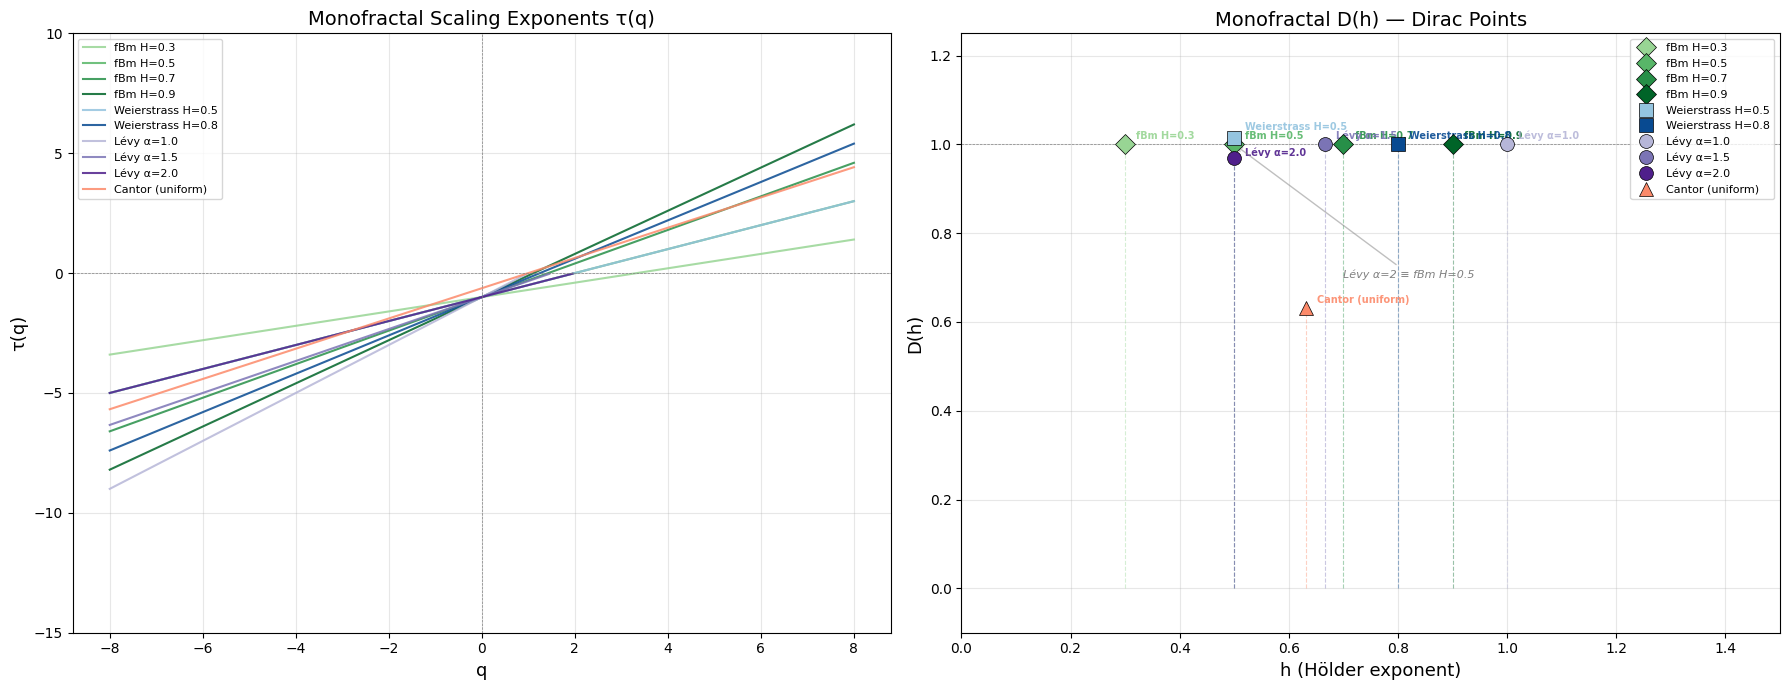


=== Monofractal Verification ===
  fBm H=0.3                  h*=0.3000  τ(0)=-1.0000  τ(1)=-0.7000
  fBm H=0.5                  h*=0.5000  τ(0)=-1.0000  τ(1)=-0.5000
  fBm H=0.7                  h*=0.7000  τ(0)=-1.0000  τ(1)=-0.3000
  fBm H=0.9                  h*=0.9000  τ(0)=-1.0000  τ(1)=-0.1000
  Weierstrass H=0.5          h*=0.5000  τ(0)=-1.0000  τ(1)=-0.5000
  Weierstrass H=0.8          h*=0.8000  τ(0)=-1.0000  τ(1)=-0.2000
  Lévy α=1.0                 h*=1.0000  τ(0)=-1.0000  τ(1)=-0.0500
  Lévy α=1.5                 h*=0.6667  τ(0)=-1.0000  τ(1)=-0.3333
  Lévy α=2.0                 h*=0.5000  τ(0)=-1.0000  τ(1)=-0.5000
  Cantor (uniform)           h*=0.6309  τ(0)=-0.6309  τ(1)=0.0000


In [1]:

# ============================================================
# Analytical Spectra Catalog — Part 1: Monofractal Systems
# Ground truth D(h) spectra for WTMM validation & ML training
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

q = np.linspace(-8, 8, 500)

mono_catalog = []  # (label, system_type, q_arr, tau_q, h_star, marker)

# ===================== A. Fractional Brownian motion =====================
# tau(q) = Hq - 1,  D(h) = point at (H, 1)
for H in [0.3, 0.5, 0.7, 0.9]:
    tau_fbm = H * q - 1
    mono_catalog.append((f"fBm H={H}", "fBm", q, tau_fbm, H, "D"))

# ===================== B. Weierstrass function =====================
# tau(q) = Hq - 1,  D(h) = point at (H, 1) — same scaling as fBm
for H in [0.5, 0.8]:
    tau_w = H * q - 1
    mono_catalog.append((f"Weierstrass H={H}", "Weierstrass", q, tau_w, H, "s"))

# ===================== C. Lévy stable processes =====================
# tau(q) = q/α - 1 for q < α (moments diverge for q ≥ α)
# D(h) = point at (1/α, 1)
# Note: Lévy α=2 ≡ fBm H=0.5 (Gaussian case)
for alpha_s in [1.0, 1.5, 2.0]:
    q_lev = np.linspace(-8, alpha_s - 0.05, 400)
    tau_levy = q_lev / alpha_s - 1
    h_star = 1.0 / alpha_s
    mono_catalog.append((f"Lévy α={alpha_s}", "Lévy", q_lev, tau_levy, h_star, "o"))
# ===================== D. Uniform Cantor set =====================
# Middle-third Cantor set with uniform measure: r=[1/3,1/3], p=[1/2,1/2]
# tau(q) = (q-1) * log(2)/log(3),  h* = log(2)/log(3) ≈ 0.631
# D(h) = point at (log2/log3, log2/log3) — fractal dimension = log2/log3
h_cantor = np.log(2) / np.log(3)
tau_cantor = h_cantor * q - h_cantor  # tau(q) = h*q - D_f, with D_f = h* = log2/log3
mono_catalog.append(("Cantor (uniform)", "Cantor", q, tau_cantor, h_cantor, "^"))

# ===================== PLOTTING =====================
system_colors = {
    "fBm":         plt.cm.Greens,
    "Weierstrass":  plt.cm.Blues,
    "Lévy":        plt.cm.Purples,
    "Cantor":      plt.cm.Reds,
}
system_counts = {}
for _, stype, *_ in mono_catalog:
    system_counts[stype] = system_counts.get(stype, 0) + 1
system_idx = {s: 0 for s in system_counts}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Vertical offset to prevent point overlap in D(h) panel
offset_map = {}
offset_step = 0.015

for label, stype, qq, tau, h_star, marker in mono_catalog:
    cmap = system_colors[stype]
    n = system_counts[stype]
    idx = system_idx[stype]
    color = cmap(0.4 + 0.5 * idx / max(n - 1, 1))
    system_idx[stype] = idx + 1

    # Left panel: tau(q)
    ax1.plot(qq, tau, color=color, alpha=0.85, linewidth=1.5, label=label)

    # Right panel: D(h) as distinct points with drop-lines
    # Offset vertically to prevent overlap at same h_star
    key = round(h_star, 4)
    if key not in offset_map:
        offset_map[key] = 0
    dy = offset_map[key] * offset_step
    offset_map[key] += 1
    # Alternate offset direction: even up, odd down
    if offset_map[key] > 1:
        sign = 1 if (offset_map[key] % 2 == 0) else -1
        dy = sign * ((offset_map[key] - 1) // 2 + 1) * offset_step

    D_f = -np.interp(0.0, qq, tau)  # tau(0) = -D_f
    D_plot = D_f + dy
    ax2.plot([h_star, h_star], [0, D_plot], '--', color=color, alpha=0.4, linewidth=0.8)
    ax2.plot(h_star, D_plot, marker, color=color, markersize=10, markeredgecolor='k',
             markeredgewidth=0.5, label=label, zorder=5)
    ax2.annotate(label, (h_star, D_plot), textcoords="offset points",
                 xytext=(8, 4 + dy * 100), fontsize=7, color=color, alpha=0.9,
                 fontweight='bold')

# Left panel formatting
ax1.set_xlabel('q', fontsize=13)
ax1.set_ylabel('τ(q)', fontsize=13)
ax1.set_title('Monofractal Scaling Exponents τ(q)', fontsize=14)
ax1.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax1.axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax1.set_ylim(-15, 10)
ax1.legend(fontsize=8, ncol=1, loc='upper left')
ax1.grid(True, alpha=0.3)

# Right panel formatting
ax2.set_xlabel('h (Hölder exponent)', fontsize=13)
ax2.set_ylabel('D(h)', fontsize=13)
ax2.set_title('Monofractal D(h) — Dirac Points', fontsize=14)
ax2.set_ylim(-0.1, 1.25)
ax2.set_xlim(0, 1.5)
ax2.axhline(1, color='gray', linewidth=0.5, linestyle='--')
ax2.legend(fontsize=8, ncol=1, loc='upper right')
ax2.grid(True, alpha=0.3)

# Note about Lévy α=2 ≡ fBm H=0.5
ax2.annotate('Lévy α=2 ≡ fBm H=0.5', xy=(0.5, 1.0), xytext=(0.7, 0.7),
             fontsize=8, color='gray', fontstyle='italic',
             arrowprops=dict(arrowstyle='->', color='gray', alpha=0.5))

plt.tight_layout()
plt.savefig('analytical_spectra_monofractal.png', dpi=150, bbox_inches='tight')
plt.show()

# Verification
print("\n=== Monofractal Verification ===")
for label, stype, qq, tau, h_star, marker in mono_catalog:
    tau_0 = np.interp(0, qq, tau)
    tau_1 = np.interp(1, qq, tau)
    print(f"  {label:25s}  h*={h_star:.4f}  τ(0)={tau_0:.4f}  τ(1)={tau_1:.4f}")


/var/folders/k8/wqqjlxf115z79hdp7q2t162c0000gn/T/ipykernel_64315/3025599399.py:7: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.stats import levy_stable


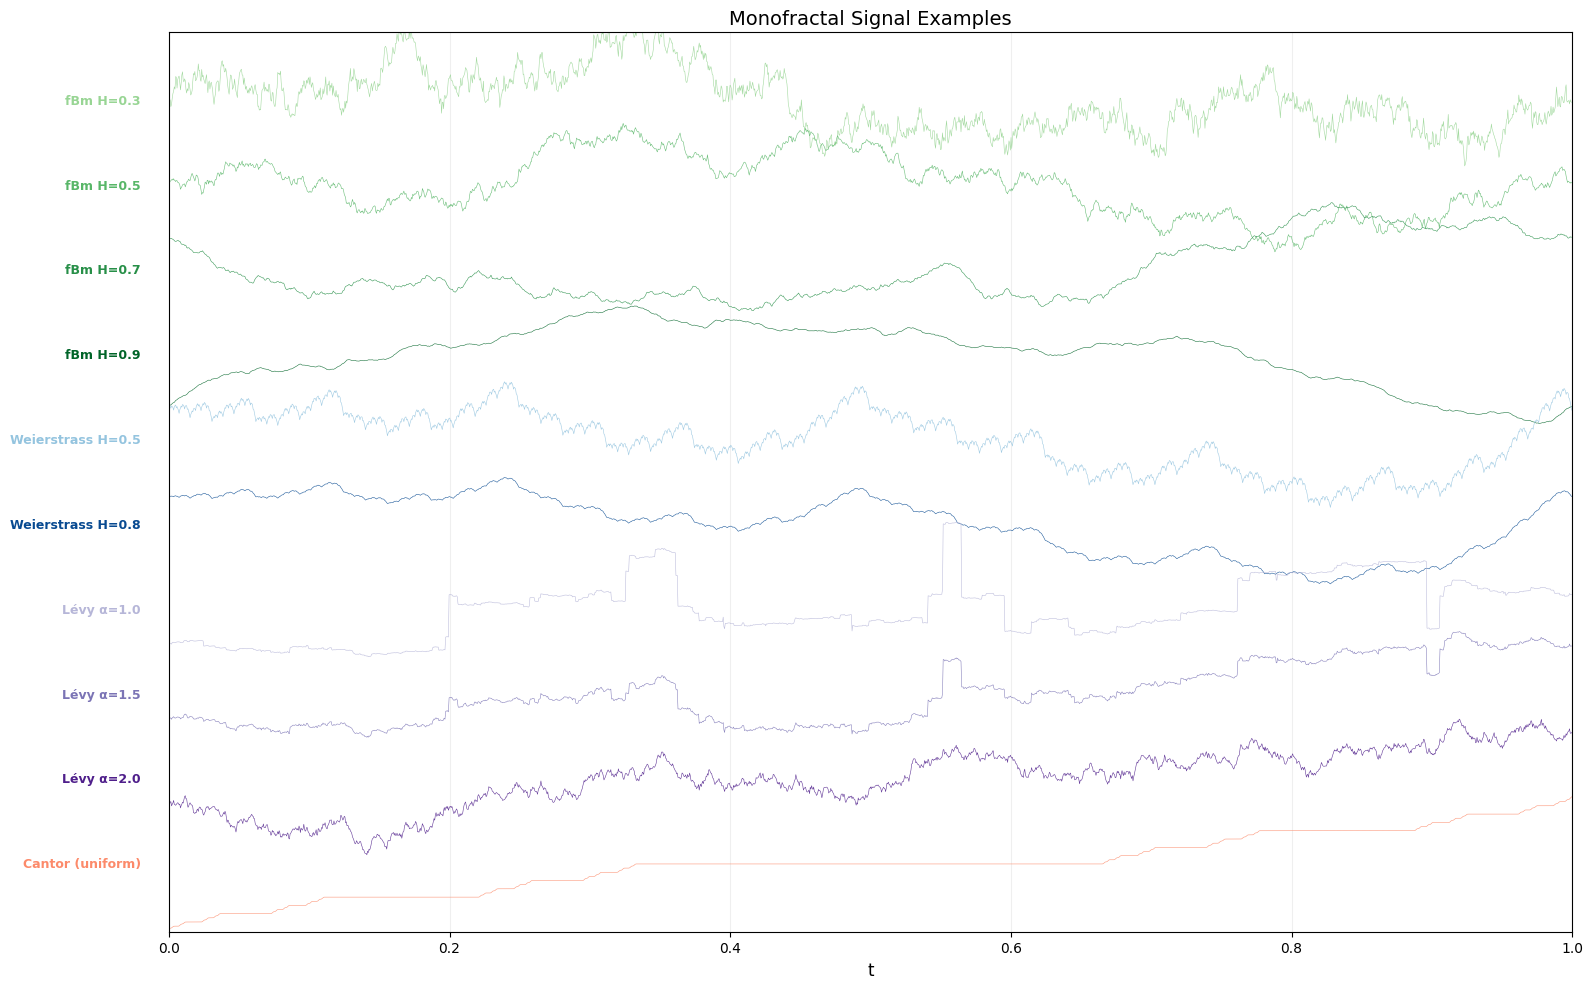

In [2]:

# ============================================================
# Monofractal Signal Examples — colors match spectra above
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import levy_stable

N_mono = 2048
t_mono = np.linspace(0, 1, N_mono, endpoint=False)

# --- Signal generators ---
def fbm_spectral(N, H, seed=42):
    """Fractional Brownian motion via spectral synthesis."""
    rng = np.random.default_rng(seed)
    f = np.arange(1, N // 2 + 1, dtype=float)
    amp = f ** (-(H + 0.5)) * np.exp(1j * rng.uniform(0, 2 * np.pi, N // 2))
    return np.fft.irfft(np.concatenate([[0], amp]), n=N)

def weierstrass_fn(N, H, b=2.0, n_terms=30):
    t = np.linspace(0, 1, N, endpoint=False)
    return sum(b ** (-n * H) * np.sin(b**n * 2 * np.pi * t + n * 0.7) for n in range(n_terms))

def levy_walk(N, alpha, seed=42):
    inc = levy_stable.rvs(alpha, 0, size=N, random_state=np.random.default_rng(seed))
    return np.cumsum(inc)

# --- Build signal catalog (same order/families as spectra cell) ---
mono_signals = []  # (label, system_type, signal)

for i, H in enumerate([0.3, 0.5, 0.7, 0.9]):
    mono_signals.append((f"fBm H={H}", "fBm", fbm_spectral(N_mono, H, seed=42 + i)))

for H in [0.5, 0.8]:
    mono_signals.append((f"Weierstrass H={H}", "Weierstrass", weierstrass_fn(N_mono, H)))

for alpha_s in [1.0, 1.5, 2.0]:
    mono_signals.append((f"Lévy α={alpha_s}", "Lévy", levy_walk(N_mono, alpha_s, seed=42)))

# --- Cantor set (uniform measure on middle-third Cantor set) ---
def cantor_measure(N, n_iter=6):
    """Uniform measure on middle-third Cantor set, integrated to devil's staircase."""
    weights = np.array([1.0])
    for _ in range(n_iter):
        weights = np.concatenate([weights / 2, np.zeros_like(weights), weights / 2])
    # Resample to length N
    x_orig = np.linspace(0, 1, len(weights), endpoint=False)
    x_new = np.linspace(0, 1, N, endpoint=False)
    measure = np.interp(x_new, x_orig, weights)
    return np.cumsum(measure) / np.sum(measure)  # devil's staircase

mono_signals.append(("Cantor (uniform)", "Cantor", cantor_measure(N_mono)))

# --- Color logic (reproduces spectra cell exactly) ---
system_colors_mono = {"fBm": plt.cm.Greens, "Weierstrass": plt.cm.Blues, "Lévy": plt.cm.Purples, "Cantor": plt.cm.Reds}
system_counts_mono = {}
for _, stype, _ in mono_signals:
    system_counts_mono[stype] = system_counts_mono.get(stype, 0) + 1
system_idx_mono = {s: 0 for s in system_counts_mono}

# --- Waterfall plot ---
fig, ax = plt.subplots(figsize=(16, 10))
n_sig = len(mono_signals)

for i, (label, stype, sig) in enumerate(mono_signals):
    cmap = system_colors_mono[stype]
    n = system_counts_mono[stype]
    idx = system_idx_mono[stype]
    color = cmap(0.4 + 0.5 * idx / max(n - 1, 1))
    system_idx_mono[stype] = idx + 1

    sig_n = (sig - np.mean(sig)) / max(np.std(sig), 1e-30) * 0.35
    offset = n_sig - 1 - i
    ax.plot(t_mono, sig_n + offset, color=color, linewidth=0.4, alpha=0.9)
    ax.text(-0.02, offset, label, fontsize=9, ha='right', va='center',
            color=color, fontweight='bold')

ax.set_xlim(0, 1)
ax.set_ylim(-0.8, n_sig - 0.2)
ax.set_xlabel('t', fontsize=12)
ax.set_yticks([])
ax.set_title('Monofractal Signal Examples', fontsize=14)
ax.grid(True, axis='x', alpha=0.2)
plt.tight_layout()
plt.savefig('monofractal_signals.png', dpi=150, bbox_inches='tight')
plt.show()


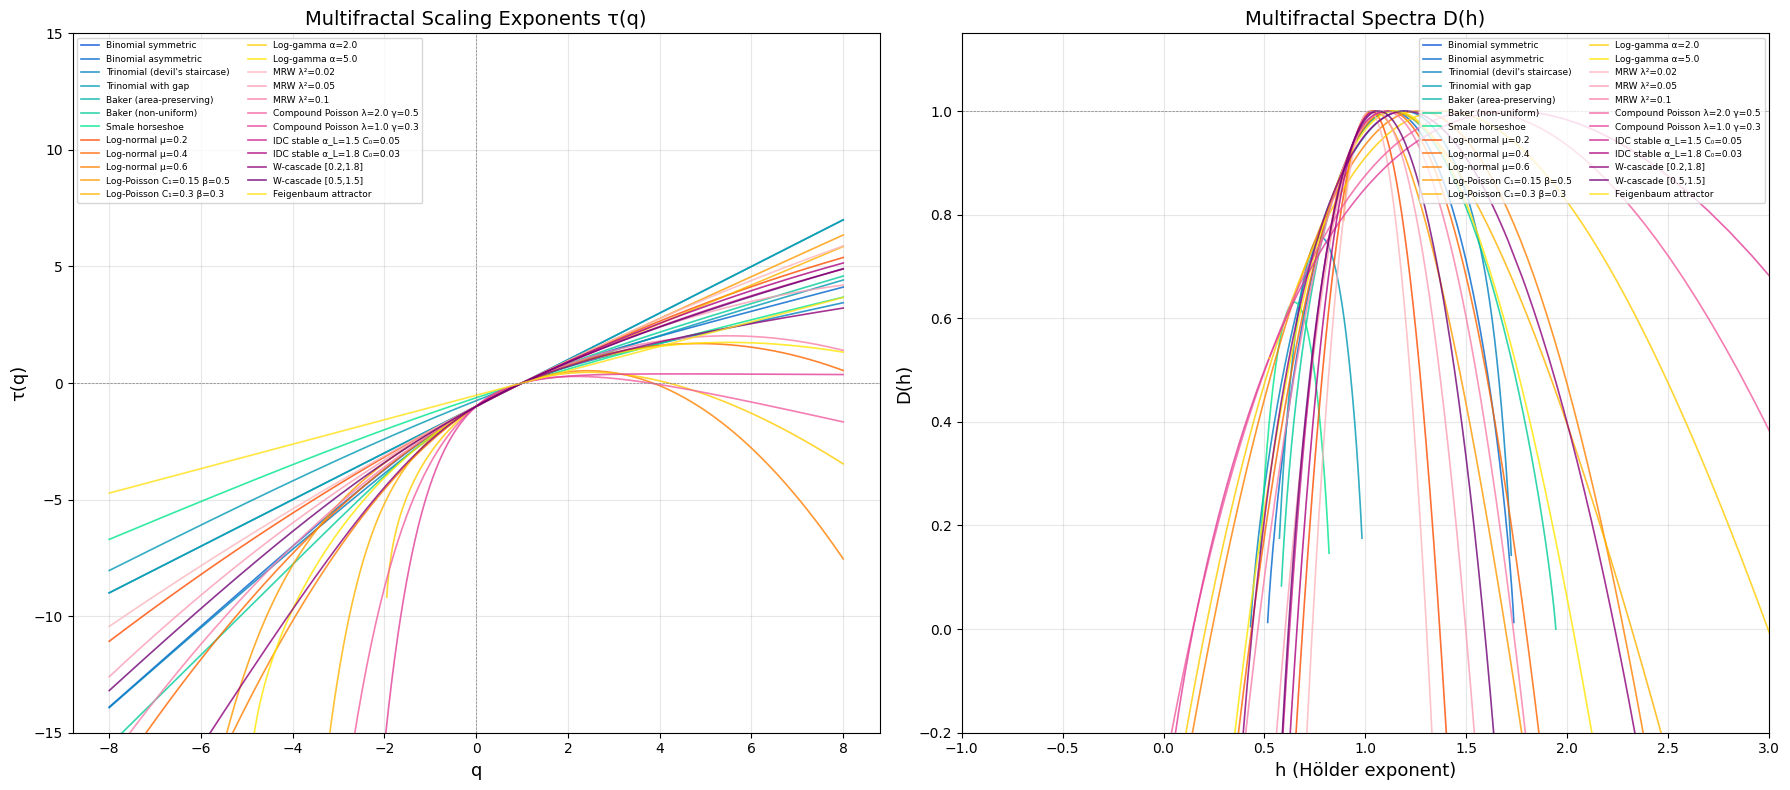


=== Multifractal Verification ===
  Binomial symmetric                        τ(0)=-1.0000  τ(1)=-0.0000  D_max=1.0000  h*=1.0000
  Binomial asymmetric                       τ(0)=-1.0000  τ(1)=-0.0000  D_max=1.0000  h*=1.1299
  Trinomial (devil's staircase)             τ(0)=-1.0000  τ(1)=-0.0000  D_max=1.0000  h*=1.1941
  Trinomial with gap                        τ(0)=-0.7565  τ(1)=-0.0000  D_max=0.7565  h*=0.7795
  Baker (area-preserving)                   τ(0)=-1.0000  τ(1)=-0.0000  D_max=1.0000  h*=1.0000
  Baker (non-uniform)                       τ(0)=-1.0000  τ(1)=-0.0000  D_max=1.0000  h*=1.1296
  Smale horseshoe                           τ(0)=-0.6309  τ(1)=-0.0000  D_max=0.6309  h*=0.6501
  Log-normal μ=0.2                          τ(0)=-1.0000  τ(1)=-0.0000  D_max=1.0000  h*=1.0298
  Log-normal μ=0.4                          τ(0)=-1.0000  τ(1)=-0.0000  D_max=1.0000  h*=1.1191
  Log-normal μ=0.6                          τ(0)=-1.0001  τ(1)=-0.0001  D_max=0.9999  h*=1.2680
  Log

In [3]:

# ============================================================
# Analytical Spectra Catalog — Part 2: Multifractal Systems
# Cantor measures, cascades, random wavelet cascades, Feigenbaum
# ============================================================

import numpy as np
from scipy.optimize import brentq
from scipy.special import gammaln
import matplotlib.pyplot as plt

q = np.linspace(-8, 8, 500)

multi_catalog = []  # (label, family, q_arr, tau_q, h_q, D_q)

# --- Helpers ---
def legendre(tau, q):
    h = np.gradient(tau, q)
    D = q * h - tau
    return h, D

def cantor_tau(r, p, q_arr):
    """Solve sum(p_i^q * r_i^(-tau)) = 1 for each q."""
    r, p = np.asarray(r, float), np.asarray(p, float)
    tau_out = np.empty_like(q_arr)
    for i, qq in enumerate(q_arr):
        def eq(tau, qq=qq):
            return np.sum(p ** qq * r ** (-tau)) - 1.0
        tau_out[i] = brentq(eq, -50, 50)
    return tau_out

def cascade_tau(q, kind, **params):
    """Unified cascade tau(q) with consistent sign convention.
    All satisfy: tau(0) = -1, tau(1) = 0, concave."""
    if kind == "lognormal":
        C = params["mu"] ** 2 / (2 * np.log(2))
        return (q - 1) * (1 - C * q)
    elif kind == "logpoisson":
        C1, beta = params["C1"], params["beta"]
        return -1 + q + C1 / np.log(beta) * (beta**q - 1 - q * (beta - 1))
    elif kind == "loggamma":
        a = params["alpha"]
        return (q - 1) - (1 / np.log(2)) * (
            gammaln(a + q) - q * gammaln(a + 1) + (q - 1) * gammaln(a)
        )
    elif kind == "compound_poisson":
        lam, gamma = params["lam"], params["gamma"]
        return (q - 1) - lam / np.log(2) * (gamma**q - 1 - q * (gamma - 1))
    elif kind == "idc_stable":
        alpha_l, C0 = params["alpha_l"], params["C0"]
        return (q - 1) - C0 / (np.log(2) * (alpha_l - 1)) * (q**alpha_l - q)

# ===================== A. Multinomial Cantor measures =====================
cantor_specs = [
    ("Binomial symmetric",            [0.5, 0.5],       [0.5, 0.5]),
    ("Binomial asymmetric",           [0.5, 0.5],       [0.7, 0.3]),
    ("Trinomial (devil's staircase)", [0.3, 0.2, 0.5],  [0.2, 0.5, 0.3]),
    ("Trinomial with gap",            [0.4, 0.2, 0.4],  [0.6, 0.0, 0.4]),
]
for label, r, p in cantor_specs:
    mask = np.array(p) > 0
    r_f, p_f = np.array(r)[mask], np.array(p)[mask]
    tau = cantor_tau(r_f, p_f, q)
    h, D = legendre(tau, q)
    multi_catalog.append((label, "cantor", q, tau, h, D))

# ===================== B. Baker's map / Smale horseshoe =====================
baker_specs = [
    ("Baker (area-preserving)", [0.3, 0.7], [0.3, 0.7]),
    ("Baker (non-uniform)",     [0.3, 0.7], [0.5, 0.5]),
    ("Smale horseshoe",         [1/3, 1/3], [0.6, 0.4]),
]
for label, r, p in baker_specs:
    tau = cantor_tau(r, p, q)
    h, D = legendre(tau, q)
    multi_catalog.append((label, "cantor", q, tau, h, D))

# ===================== C. Existing cascades (unified helper) =====================

# Log-normal: μ = 0.2, 0.4, 0.6
for mu in [0.2, 0.4, 0.6]:
    tau_ln = cascade_tau(q, "lognormal", mu=mu)
    h, D = legendre(tau_ln, q)
    multi_catalog.append((f"Log-normal μ={mu}", "cascade", q, tau_ln, h, D))

# Log-Poisson
for C1, beta in [(0.15, 0.5), (0.3, 0.3)]:
    tau_lp = cascade_tau(q, "logpoisson", C1=C1, beta=beta)
    h, D = legendre(tau_lp, q)
    multi_catalog.append((f"Log-Poisson C₁={C1} β={beta}", "cascade", q, tau_lp, h, D))

# Log-gamma (q > -α restriction)
for alpha in [2.0, 5.0]:
    q_lg = np.linspace(-alpha + 0.05, 8, 500)
    tau_lg = cascade_tau(q_lg, "loggamma", alpha=alpha)
    h, D = legendre(tau_lg, q_lg)
    multi_catalog.append((f"Log-gamma α={alpha}", "cascade", q_lg, tau_lg, h, D))

# ===================== D. Random wavelet cascades (NEW) =====================

# --- D1. Multifractal Random Walk (MRW) ---
# Same tau(q) as log-normal but parameterized by λ² (Bacry, Delour, Muzy 2001)
for lam2 in [0.02, 0.05, 0.1]:
    mu_equiv = np.sqrt(2 * lam2 * np.log(2))
    tau_mrw = cascade_tau(q, "lognormal", mu=mu_equiv)
    h, D = legendre(tau_mrw, q)
    multi_catalog.append((f"MRW λ²={lam2}", "wavelet_cascade", q, tau_mrw, h, D))

# --- D2. Compound Poisson cascade (Barral-Mandelbrot) ---
for lam, gamma in [(2.0, 0.5), (1.0, 0.3)]:
    tau_cp = cascade_tau(q, "compound_poisson", lam=lam, gamma=gamma)
    h, D = legendre(tau_cp, q)
    multi_catalog.append((f"Compound Poisson λ={lam} γ={gamma}", "wavelet_cascade",
                          q, tau_cp, h, D))

# --- D3. IDC with stable Lévy measure (Chainais, Riedi, Abry) ---
for alpha_l, C0 in [(1.5, 0.05), (1.8, 0.03)]:
    # q must be > 0 for q^alpha_l when alpha_l is non-integer
    q_idc = np.linspace(0.01, 8, 400)
    tau_idc = cascade_tau(q_idc, "idc_stable", alpha_l=alpha_l, C0=C0)
    h, D = legendre(tau_idc, q_idc)
    multi_catalog.append((f"IDC stable α_L={alpha_l} C₀={C0}", "wavelet_cascade",
                          q_idc, tau_idc, h, D))

# --- D4. W-cascade (Arneodo, Bacry, Muzy) ---
# Uniform multipliers on [a,b], normalized so E[W]=1/2 (conservative dyadic cascade)
# tau(q) = -(1 + log2(E[W'^q])) where W' = W/(a+b) maps [a,b] → [a/(a+b), b/(a+b)]
for a, b in [(0.2, 1.8), (0.5, 1.5)]:
    q_wc = np.linspace(-8, 8, 500)
    # Avoid q = -1 (pole in q+1 denominator)
    q_wc = q_wc[np.abs(q_wc + 1) > 0.05]
    a_n, b_n = a / (a + b), b / (a + b)
    EWq = (b_n**(q_wc + 1) - a_n**(q_wc + 1)) / ((q_wc + 1) * (b_n - a_n))
    tau_wc = -(1 + np.log2(EWq))
    h, D = legendre(tau_wc, q_wc)
    multi_catalog.append((f"W-cascade [{a},{b}]", "wavelet_cascade", q_wc, tau_wc, h, D))

# ===================== E. Feigenbaum attractor =====================
alpha_F = 2.502907875095892
r_feig = [1 / alpha_F**2, 1 / alpha_F]
d_feig = 0.538
p_feig = [r_feig[0]**d_feig, r_feig[1]**d_feig]
p_feig = [pi / sum(p_feig) for pi in p_feig]
tau_feig = cantor_tau(r_feig, p_feig, q)
h, D = legendre(tau_feig, q)
multi_catalog.append(("Feigenbaum attractor", "feigenbaum", q, tau_feig, h, D))

# ===================== PLOTTING =====================
family_colors = {
    "cantor":           plt.cm.winter,        # blues/teals
    "cascade":          plt.cm.autumn,         # reds/oranges
    "wavelet_cascade":  plt.cm.RdPu,           # magentas/pinks
    "feigenbaum":       plt.cm.Wistia,         # standalone
}
family_counts = {}
for _, fam, *_ in multi_catalog:
    family_counts[fam] = family_counts.get(fam, 0) + 1
family_idx = {fam: 0 for fam in family_counts}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

for label, fam, qq, tau, h, D in multi_catalog:
    cmap = family_colors[fam]
    n = family_counts[fam]
    idx = family_idx[fam]
    color = cmap(0.3 + 0.6 * idx / max(n - 1, 1))
    family_idx[fam] = idx + 1

    # Left panel: tau(q)
    ax1.plot(qq, tau, color=color, alpha=0.8, linewidth=1.2, label=label)

    # Right panel: D(h) — multifractal curves
    mask = D > -0.5
    ax2.plot(h[mask], D[mask], color=color, alpha=0.8, linewidth=1.2, label=label)

ax1.set_xlabel('q', fontsize=13)
ax1.set_ylabel('τ(q)', fontsize=13)
ax1.set_title('Multifractal Scaling Exponents τ(q)', fontsize=14)
ax1.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax1.axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax1.set_ylim(-15, 15)
ax1.legend(fontsize=6.5, ncol=2, loc='upper left')
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('h (Hölder exponent)', fontsize=13)
ax2.set_ylabel('D(h)', fontsize=13)
ax2.set_title('Multifractal Spectra D(h)', fontsize=14)
ax2.set_ylim(-0.2, 1.15)
ax2.set_xlim(-1, 3)
ax2.axhline(1, color='gray', linewidth=0.5, linestyle='--')
ax2.legend(fontsize=6.5, ncol=2, loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('analytical_spectra_multifractal.png', dpi=150, bbox_inches='tight')
plt.show()

# ===================== VERIFICATION =====================
print("\n=== Multifractal Verification ===")
for label, fam, qq, tau, h, D in multi_catalog:
    # Check tau(0) ≈ -1 and tau(1) ≈ 0
    tau_0 = np.interp(0, qq, tau)
    tau_1 = np.interp(1, qq, tau)
    mask = D > 0
    if mask.any():
        Dmax = D[mask].max()
        h_at_max = h[np.argmax(np.where(mask, D, -np.inf))]
        print(f"  {label:40s}  τ(0)={tau_0:+.4f}  τ(1)={tau_1:+.4f}  D_max={Dmax:.4f}  h*={h_at_max:.4f}")
    else:
        print(f"  {label:40s}  τ(0)={tau_0:+.4f}  τ(1)={tau_1:+.4f}  [no positive D region]")

# Cross-checks
print("\n=== Cross-checks ===")
# MRW λ²→0 should be near-monofractal
lam2_small = 0.001
mu_eq = np.sqrt(2 * lam2_small * np.log(2))
tau_test = cascade_tau(q, "lognormal", mu=mu_eq)
h_test, D_test = legendre(tau_test, q)
h_sel = h_test[D_test > 0.5]; h_width = (h_sel.max() - h_sel.min()) if len(h_sel) > 0 else 0
print(f"  MRW λ²=0.001: D(h) width at D>0.5 = {h_width:.6f}  (should be ~0)")

# IDC α_L=2 should match log-normal
tau_idc2 = cascade_tau(q[q > 0.01], "idc_stable", alpha_l=2.0, C0=0.05)
mu_match = np.sqrt(2 * 0.05 * np.log(2))
tau_ln2 = cascade_tau(q[q > 0.01], "lognormal", mu=mu_match)
print(f"  IDC α_L=2 vs log-normal: max|Δτ| = {np.max(np.abs(tau_idc2 - tau_ln2)):.2e}  (should be ~0)")


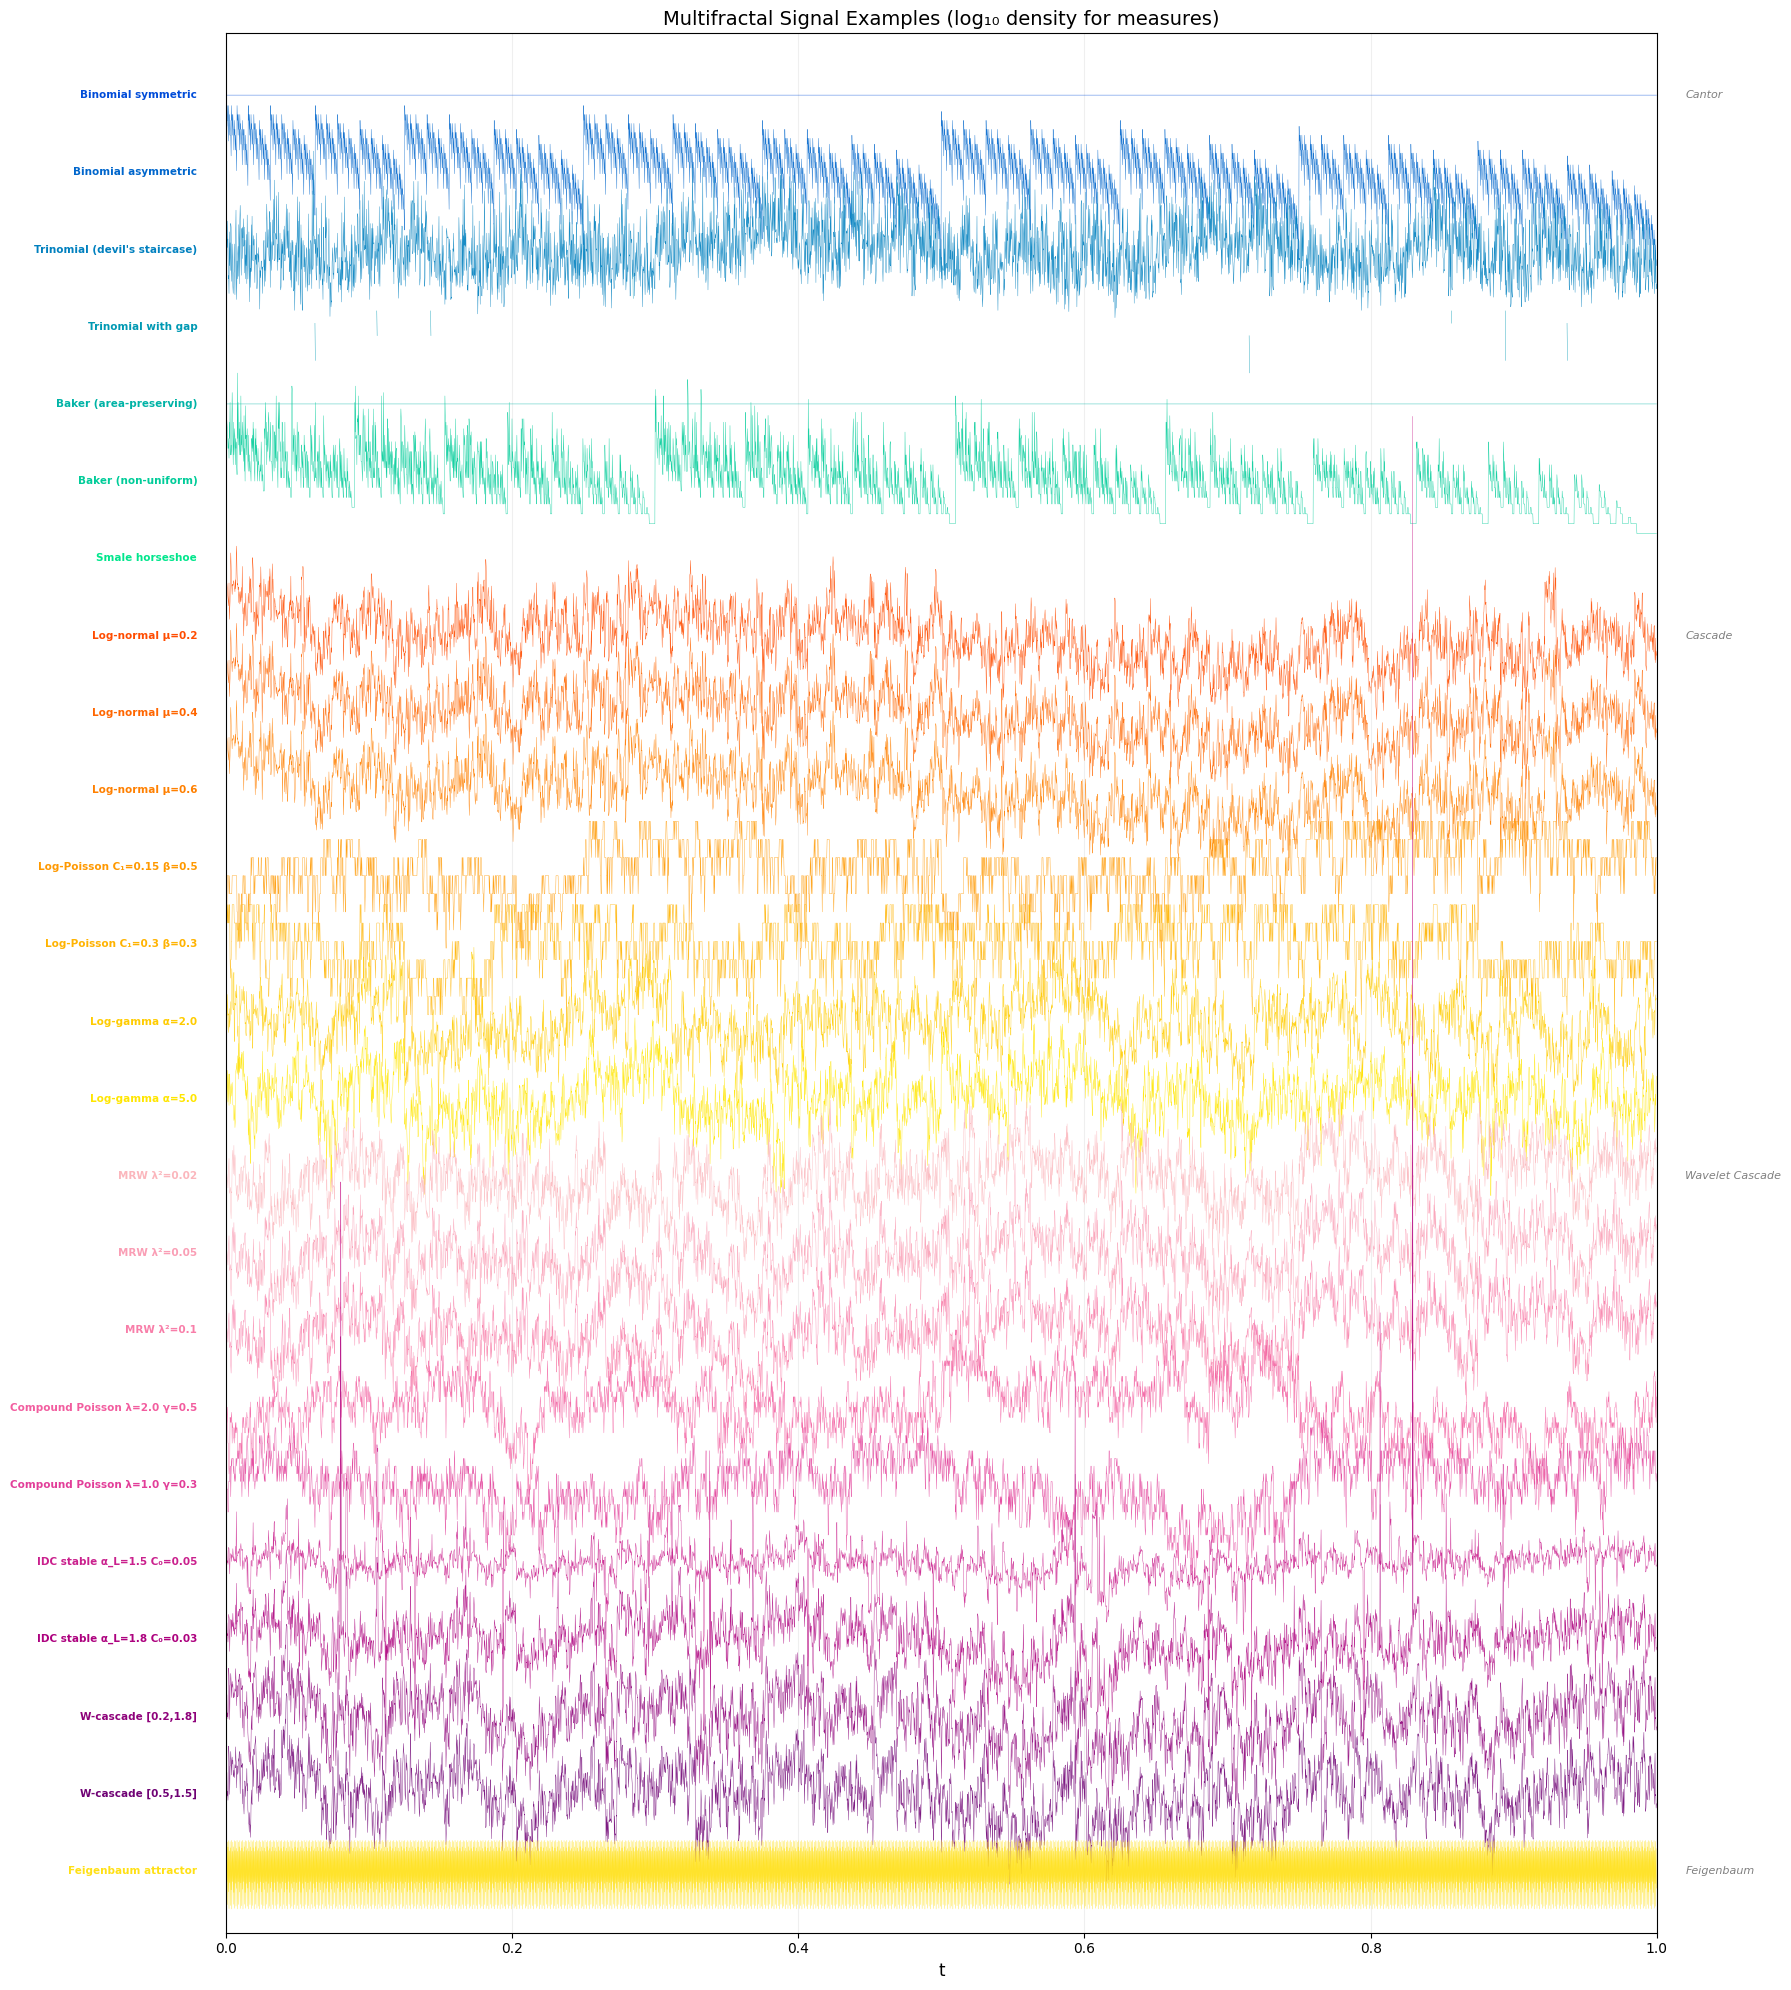

In [4]:

# ============================================================
# Multifractal Signal Examples — colors match spectra above
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import levy_stable as lstable

N_LEVELS_SIG = 12
N_multi = 2**N_LEVELS_SIG  # 4096
t_multi = np.linspace(0, 1, N_multi, endpoint=False)

# --- Signal generators ---

def multinomial_measure(r, p, n_levels=N_LEVELS_SIG, N_pts=None):
    """Deterministic multinomial cascade density on a regular grid."""
    if N_pts is None:
        N_pts = 2**n_levels
    r, p = np.array(r, float), np.array(p, float)
    cum_r = np.concatenate([[0], np.cumsum(r)])
    density = np.ones(N_pts)
    local_x = np.linspace(0, 1, N_pts, endpoint=False) + 0.5 / N_pts

    for level in range(n_levels):
        matched = np.zeros(N_pts, dtype=bool)
        for k in range(len(r)):
            mask = (local_x >= cum_r[k]) & (local_x < cum_r[k + 1]) & (density > 0)
            if p[k] > 0 and r[k] > 0:
                density[mask] *= p[k] / r[k]
                local_x[mask] = (local_x[mask] - cum_r[k]) / r[k]
                matched |= mask
            else:
                density[mask] = 0
                matched |= mask
        density[(density > 0) & ~matched] = 0
    return density

def random_cascade_batch(weight_batch_fn, n_levels=N_LEVELS_SIG, seed=42):
    """Random cascade with batch weight generation for speed."""
    rng = np.random.default_rng(seed)
    N_pts = 2**n_levels
    total_weights = 2 * (N_pts - 1)
    all_weights = weight_batch_fn(rng, total_weights)

    measure = np.ones(N_pts)
    wi = 0
    for level in range(n_levels):
        block_size = N_pts >> level
        half = block_size >> 1
        for b in range(1 << level):
            start = b * block_size
            w1 = max(all_weights[wi], 1e-30)
            w2 = max(all_weights[wi + 1], 1e-30)
            wi += 2
            measure[start:start + half] *= w1
            measure[start + half:start + block_size] *= w2
    return measure

def feigenbaum_orbit(N_pts=None, n_transient=10000):
    if N_pts is None:
        N_pts = 2**N_LEVELS_SIG
    r_inf = 3.5699456718709449
    x = 0.5
    for _ in range(n_transient):
        x = r_inf * x * (1 - x)
    sig = np.empty(N_pts)
    for i in range(N_pts):
        x = r_inf * x * (1 - x)
        sig[i] = x
    return sig

# --- Batch weight samplers (E[W]=1 for canonical cascades) ---
def lognormal_batch(mu):
    return lambda rng, n: np.exp(mu * rng.normal(size=n) - mu**2 / 2)

def logpoisson_batch(C1, beta):
    lam = C1 / (-np.log(beta))
    return lambda rng, n: beta**rng.poisson(lam, size=n) * np.exp(lam * (1 - beta))

def loggamma_batch(alpha):
    return lambda rng, n: rng.gamma(alpha, size=n) / alpha

def compound_poisson_batch(lam, gamma):
    return lambda rng, n: gamma**rng.poisson(lam, size=n) * np.exp(lam * (1 - gamma))

def uniform_batch(a, b):
    a_n, b_n = 2 * a / (a + b), 2 * b / (a + b)
    return lambda rng, n: rng.uniform(a_n, b_n, size=n)

def stable_batch(alpha_l, C0):
    sigma = np.sqrt(C0)
    return lambda rng, n: np.exp(sigma * lstable.rvs(alpha_l, 0, size=n, random_state=rng))

# --- Build all signals (same order/families as spectra cell) ---
multi_signals = []  # (label, family, signal)

# A. Cantor measures
for label, r, p in [
    ("Binomial symmetric",            [0.5, 0.5],       [0.5, 0.5]),
    ("Binomial asymmetric",           [0.5, 0.5],       [0.7, 0.3]),
    ("Trinomial (devil's staircase)", [0.3, 0.2, 0.5],  [0.2, 0.5, 0.3]),
    ("Trinomial with gap",            [0.4, 0.2, 0.4],  [0.6, 0.0, 0.4]),
]:
    multi_signals.append((label, "cantor", multinomial_measure(r, p)))

# B. Baker's map / Smale horseshoe
for label, r, p in [
    ("Baker (area-preserving)", [0.3, 0.7], [0.3, 0.7]),
    ("Baker (non-uniform)",     [0.3, 0.7], [0.5, 0.5]),
    ("Smale horseshoe",         [1/3, 1/3], [0.6, 0.4]),
]:
    multi_signals.append((label, "cantor", multinomial_measure(r, p)))

# C. Existing cascades
for mu in [0.2, 0.4, 0.6]:
    multi_signals.append((f"Log-normal μ={mu}", "cascade",
                          random_cascade_batch(lognormal_batch(mu), seed=42)))
for C1, beta in [(0.15, 0.5), (0.3, 0.3)]:
    multi_signals.append((f"Log-Poisson C₁={C1} β={beta}", "cascade",
                          random_cascade_batch(logpoisson_batch(C1, beta), seed=42)))
for alpha in [2.0, 5.0]:
    multi_signals.append((f"Log-gamma α={alpha}", "cascade",
                          random_cascade_batch(loggamma_batch(alpha), seed=42)))

# D. Random wavelet cascades
for lam2 in [0.02, 0.05, 0.1]:
    mu_eq = np.sqrt(2 * lam2 * np.log(2))
    multi_signals.append((f"MRW λ²={lam2}", "wavelet_cascade",
                          random_cascade_batch(lognormal_batch(mu_eq), seed=100)))
for lam, gamma in [(2.0, 0.5), (1.0, 0.3)]:
    multi_signals.append((f"Compound Poisson λ={lam} γ={gamma}", "wavelet_cascade",
                          random_cascade_batch(compound_poisson_batch(lam, gamma), seed=42)))
for alpha_l, C0 in [(1.5, 0.05), (1.8, 0.03)]:
    multi_signals.append((f"IDC stable α_L={alpha_l} C₀={C0}", "wavelet_cascade",
                          random_cascade_batch(stable_batch(alpha_l, C0), seed=42)))
for a, b in [(0.2, 1.8), (0.5, 1.5)]:
    multi_signals.append((f"W-cascade [{a},{b}]", "wavelet_cascade",
                          random_cascade_batch(uniform_batch(a, b), seed=42)))

# E. Feigenbaum attractor
multi_signals.append(("Feigenbaum attractor", "feigenbaum", feigenbaum_orbit()))

# --- Color logic (reproduces spectra cell exactly) ---
family_colors_sig = {
    "cantor":          plt.cm.winter,
    "cascade":         plt.cm.autumn,
    "wavelet_cascade": plt.cm.RdPu,
    "feigenbaum":      plt.cm.Wistia,
}
family_counts_sig = {}
for _, fam, _ in multi_signals:
    family_counts_sig[fam] = family_counts_sig.get(fam, 0) + 1
family_idx_sig = {fam: 0 for fam in family_counts_sig}

# --- Waterfall plot ---
fig, ax = plt.subplots(figsize=(18, 20))
n_sig = len(multi_signals)

for i, (label, fam, sig) in enumerate(multi_signals):
    cmap = family_colors_sig[fam]
    n = family_counts_sig[fam]
    idx = family_idx_sig[fam]
    color = cmap(0.3 + 0.6 * idx / max(n - 1, 1))
    family_idx_sig[fam] = idx + 1

    offset = n_sig - 1 - i

    if fam == "feigenbaum":
        sig_n = (sig - np.mean(sig)) / max(np.std(sig), 1e-30) * 0.35
    else:
        # Plot log-density for measures (positive-valued)
        sig_pos = np.maximum(sig, 1e-30)
        sig_log = np.log10(sig_pos)
        sig_log = np.where(sig > 0, sig_log, np.nan)
        sig_n = (sig_log - np.nanmean(sig_log)) / max(np.nanstd(sig_log), 1e-30) * 0.35

    ax.plot(t_multi[:len(sig_n)], sig_n + offset, color=color, linewidth=0.3, alpha=0.9)
    ax.text(-0.02, offset, label, fontsize=7.5, ha='right', va='center',
            color=color, fontweight='bold')

ax.set_xlim(0, 1)
ax.set_ylim(-0.8, n_sig - 0.2)
ax.set_xlabel('t', fontsize=12)
ax.set_yticks([])
ax.set_title('Multifractal Signal Examples (log₁₀ density for measures)', fontsize=14)
ax.grid(True, axis='x', alpha=0.2)

# Family labels on the right
families_shown = set()
for i, (label, fam, _) in enumerate(multi_signals):
    if fam not in families_shown:
        offset = n_sig - 1 - i
        ax.text(1.02, offset, fam.replace('_', ' ').title(), fontsize=8,
                ha='left', va='center', color='gray', fontstyle='italic')
        families_shown.add(fam)

plt.tight_layout()
plt.savefig('multifractal_signals.png', dpi=150, bbox_inches='tight')
plt.show()


In [5]:
# Cell 12: CWT engine — now imported from wtmm package
from wtmm.cwt import cwtd, cwtd_batched, cwtd_mlx
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
from wtmm.colormaps import lastwave_colormap, lastwave_grey_colormap, lastwave_b2r_colormap, scalogram_lastwave
import torch
import numpy as np
import matplotlib.pyplot as plt
import time
from numba import njit, prange
from numba.typed import List as NumbaList

torch.set_default_dtype(torch.float64)
print(f'PyTorch {torch.__version__}, device: CPU, dtype: float64')


print('CWT engine loaded (from wtmm.cwt). Use cwtd() for faithful per-scale, cwtd_batched() for optimized.')
print(f'CWT device: CPU, dtype: float64')


PyTorch 2.10.0, device: CPU, dtype: float64
CWT engine loaded (from wtmm.cwt). Use cwtd() for faithful per-scale, cwtd_batched() for optimized.
CWT device: CPU, dtype: float64


In [52]:
# ============================================================
# Signal Selector — pick any signal from the catalogs above
# ============================================================
# Change SIGNAL_NAME to any label from mono_catalog or multi_catalog.
# All downstream cells (CWT, extrema, chains, partition, spectra)
# will automatically use the selected signal.

SIGNAL_NAME = "Log-Poisson C₁=0.15 β=0.5"  # <-- change this

# --- Lookup signal and theory ---
analysis_signal = None
analysis_label = SIGNAL_NAME
analysis_color = 'k'
is_measure = False
has_theory = False
theory_q = theory_tau = theory_h = theory_D = None

# Search multi catalog first
_found = False
for _i, (_label, _fam, _sig) in enumerate(multi_signals):
    if _label == SIGNAL_NAME:
        # Determine color (reproduce family color logic)
        _cmap = family_colors_sig[_fam]
        _n = family_counts_sig[_fam]
        _idx_before = sum(1 for _l2, _f2, _ in multi_signals[:_i] if _f2 == _fam)
        analysis_color = _cmap(0.3 + 0.6 * _idx_before / max(_n - 1, 1))

        # Measures get cumsum; Feigenbaum orbit and self-affine signals don't
        if _fam == 'feigenbaum':
            is_measure = False
            analysis_signal = _sig
        else:
            is_measure = True
            analysis_signal = np.cumsum(_sig)
        SIZE = len(_sig)

        # Look up theory from multi_catalog
        for _tl, _tf, _tq, _ttau, _th, _tD in multi_catalog:
            if _tl == SIGNAL_NAME:
                has_theory = True
                theory_q = _tq
                theory_tau = _ttau
                theory_h = _th
                theory_D = _tD
                break
        _found = True
        break

# Search mono catalog
if not _found:
    for _i, (_label, _stype, _sig) in enumerate(mono_signals):
        if _label == SIGNAL_NAME:
            _cmap = system_colors_mono[_stype]
            _n = system_counts_mono[_stype]
            _idx_before = sum(1 for _l2, _s2, _ in mono_signals[:_i] if _s2 == _stype)
            analysis_color = _cmap(0.4 + 0.5 * _idx_before / max(_n - 1, 1))

            is_measure = False
            analysis_signal = _sig
            SIZE = len(_sig)

            # Look up theory from mono_catalog
            for _tl, _ts, _tq, _ttau, _h_star, _marker in mono_catalog:
                if _tl == SIGNAL_NAME:
                    has_theory = True
                    theory_q = _tq
                    theory_tau = _ttau
                    # Monofractal D(h) is a Dirac delta at (h_star, 1)
                    theory_h = np.array([_h_star])
                    theory_D = np.array([-np.interp(0.0, _tq, _ttau)])  # D_f = -tau(0)
                    break
            _found = True
            break

if analysis_signal is None:
    raise ValueError(f"Signal '{SIGNAL_NAME}' not found in mono_signals or multi_signals.\n"
                     f"Available mono: {[l for l,_,_ in mono_signals]}\n"
                     f"Available multi: {[l for l,_,_ in multi_signals]}")

# Summary
print(f'Selected: "{analysis_label}"')
print(f'  Signal length: {SIZE}')
print(f'  Is measure (cumsum applied): {is_measure}')
print(f'  Has theoretical spectrum: {has_theory}')
if has_theory and theory_h is not None:
    if len(theory_h) == 1:
        print(f'  Monofractal: h* = {theory_h[0]:.4f}')
    else:
        mask = theory_D > 0
        if mask.any():
            print(f'  h range: [{theory_h[mask].min():.4f}, {theory_h[mask].max():.4f}]')


Selected: "Log-Poisson C₁=0.15 β=0.5"
  Signal length: 4096
  Is measure (cumsum applied): True
  Has theoretical spectrum: True
  h range: [0.8924, 1.6774]


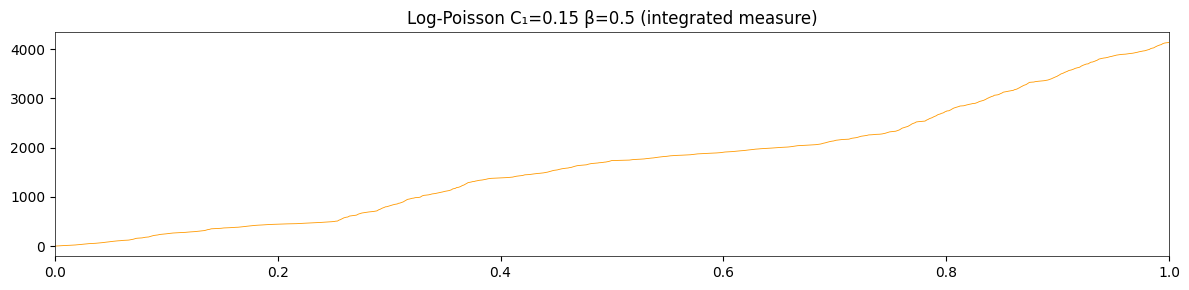

Signal size: 4096
Signal range: [0.4579, 4132.9131]
CWT computed in 0.374s  (a_min=1.0, n_oct=5, n_voice=10)
Coefficients shape: (50, 4096), Scales: 50 (1.00 to 29.86)
Valid range at finest scale: (18, 4077), coarsest: (537, 3558)


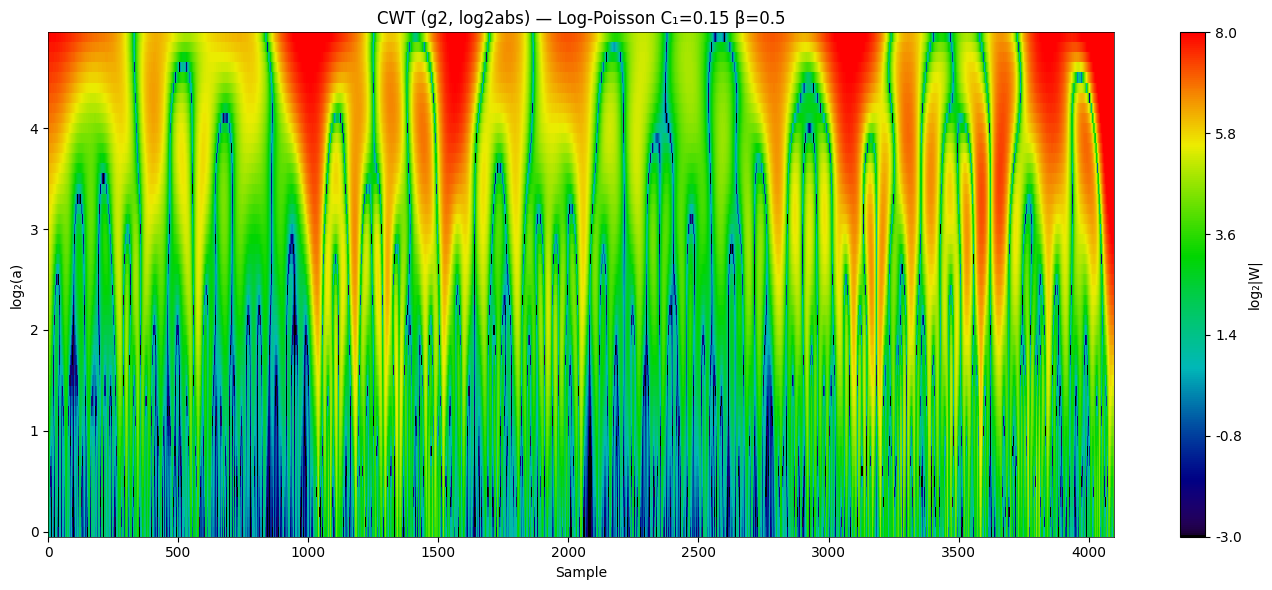

In [68]:
# Cell 13: CWT on selected signal

fig, ax = plt.subplots(figsize=(12, 3))
for spine in ax.spines.values(): spine.set_linewidth(0.5)
t_axis = np.arange(SIZE) / SIZE
ax.plot(t_axis, analysis_signal, color=analysis_color, linewidth=0.6)
ax.set_title(f'{analysis_label}{" (integrated measure)" if is_measure else ""}')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

print(f'Signal size: {SIZE}')
print(f'Signal range: [{analysis_signal.min():.4f}, {analysis_signal.max():.4f}]')

# CWT parameters — change these to experiment
A_MIN = 1.0
N_OCT = 5
N_VOICE = 10
WAVELET = 'g2'
EXPO = -1.0

# Display mode: 'lglobal' (per-scale normalized |W|), 'log2abs' (log2|W|), 'global', 'signedglobal'
SCALOGRAM_MODE = 'log2abs'

# CWT + visualization
t0 = time.time()
coeffs, scales, valid_ranges = cwtd_mlx(analysis_signal, a_min=A_MIN, n_oct=N_OCT, n_voice=N_VOICE,
                                     wavelet_name=WAVELET, expo=EXPO)
t1 = time.time()
print(f'CWT computed in {t1-t0:.3f}s  (a_min={A_MIN}, n_oct={N_OCT}, n_voice={N_VOICE})')
print(f'Coefficients shape: {coeffs.shape}, Scales: {len(scales)} ({scales[0]:.2f} to {scales[-1]:.2f})')
print(f'Valid range at finest scale: {valid_ranges[0]}, coarsest: {valid_ranges[-1]}')

# Plot scalogram
fig, ax = plt.subplots(figsize=(14, 6))
for spine in ax.spines.values(): spine.set_linewidth(0.5)
im = scalogram_lastwave(coeffs, scales=scales, ax=ax,
                        norm_mode=SCALOGRAM_MODE)

if SCALOGRAM_MODE == 'log2abs' and hasattr(im, '_log2_vlim'):
    vmin_l, vmax_l = im._log2_vlim
    cbar = plt.colorbar(im, ax=ax, label='log\u2082|W|')
    tick_vals = np.linspace(0, 1, 6)
    cbar.set_ticks(tick_vals)
    cbar.set_ticklabels([f'{vmin_l + t*(vmax_l-vmin_l):.1f}' for t in tick_vals])
else:
    label_map = {'lglobal': '|W| (per-scale normalized)', 'global': '|W|',
                 'signedglobal': 'W (signed)'}
    plt.colorbar(im, ax=ax, label=label_map.get(SCALOGRAM_MODE, ''))

ax.set_title(f'CWT ({WAVELET}, {SCALOGRAM_MODE}) \u2014 {analysis_label}')
plt.tight_layout()
plt.show()


Numba warmup: 0.000s
Total extrema: 7417
Extrema computed in 0.002s
  Scale 0 (a=1.00): 508 extrema
  Scale 12 (a=2.30): 224 extrema
  Scale 25 (a=5.66): 84 extrema
  Scale 37 (a=13.00): 41 extrema
  Scale 49 (a=29.86): 17 extrema
Chaining: 0.000s
Delete: 0.005s, deleted 0 chains
ChainMax: 0.001s
Total chaining: 0.007s
Remaining extrema: 7417
Pre-deletion chains: 478
Surviving chains: 478
Deleted chains: 0


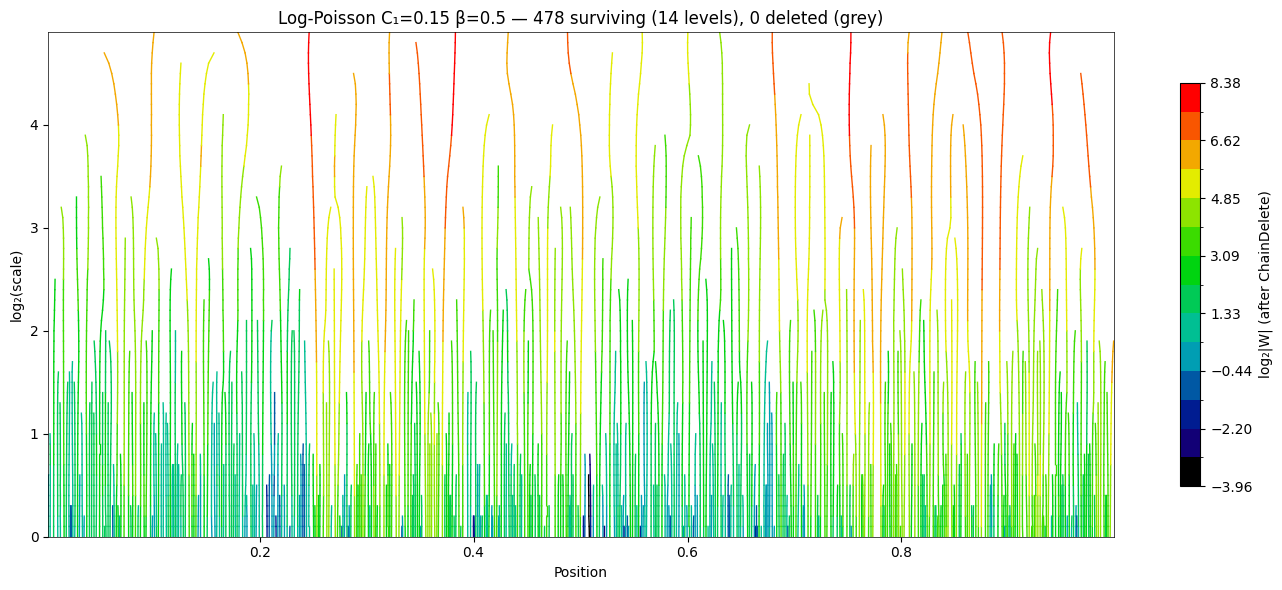

In [69]:
# Cell 15: Extrema detection — now imported from wtmm package
from wtmm.extrema import compute_extlis_numba, compute_extrep

# Compute extrema representation
dx_signal = 1.0 / SIZE
t0 = time.time()
# Warm up Numba
_ = compute_extlis_numba(coeffs[0], dx_signal, 0.0, 1e-6,
                          valid_ranges[0][0], valid_ranges[0][1])
t_warmup = time.time()
print(f'Numba warmup: {t_warmup - t0:.3f}s')

n_scales = coeffs.shape[0]

extrep_abs, extrep_ord, extrep_idx = compute_extrep(
    coeffs, scales,
    valid_ranges=valid_ranges, dx=dx_signal, x0=0.0, epsilon=1e-6)
t1 = time.time()
print(f'Extrema computed in {t1-t_warmup:.3f}s')
for sidx in [0, n_scales//4, n_scales//2, 3*n_scales//4, n_scales-1]:
    print(f'  Scale {sidx} (a={scales[sidx]:.2f}): {len(extrep_abs[sidx])} extrema')

# Cell 16: Chaining — now imported from wtmm package
from wtmm.chains import chain_all, chain_delete_all, chain_max_wrapper, trace_chains, save_chain_state

# Run full chaining pipeline
t0 = time.time()
coarser_links, finer_links = chain_all(extrep_abs, extrep_ord)
t_chain = time.time()
print(f'Chaining: {t_chain - t0:.3f}s')

# Save pre-deletion state for visualization
pre_del_abs, pre_del_ord, pre_del_cl = save_chain_state(extrep_abs, extrep_ord, coarser_links)
pre_del_chains = trace_chains(pre_del_abs, pre_del_ord, pre_del_cl, scales, n_scales)

nb_del = chain_delete_all(extrep_abs, extrep_ord, extrep_idx,
                           coarser_links, finer_links)
t_delete = time.time()
print(f'Delete: {t_delete - t_chain:.3f}s, deleted {nb_del} chains')

# ChainMax with expo=1
chain_max_wrapper(extrep_ord, coarser_links, n_voice=N_VOICE, a_min=A_MIN, expo=1.0)
t1 = time.time()
print(f'ChainMax: {t1 - t_delete:.3f}s')
print(f'Total chaining: {t1 - t0:.3f}s')

remaining = sum(len(a) for a in extrep_abs)
print(f'Remaining extrema: {remaining}')

# Cell 17: Extrema representation and maxima lines visualization

# Surviving chains (after deletion)
post_del_chains = trace_chains(extrep_abs, extrep_ord, coarser_links, scales, n_scales)

# Find which pre-deletion chains were deleted (not present in post-deletion)
# Build set of surviving chain start positions for fast lookup
surviving_starts = set()
for pos, sv, sign, vals in post_del_chains:
    surviving_starts.add((pos[0], sign))

deleted_chains = []
for pos, sv, sign, vals in pre_del_chains:
    if (pos[0], sign) not in surviving_starts:
        deleted_chains.append((pos, sv, sign, vals))

print(f'Pre-deletion chains: {len(pre_del_chains)}')
print(f'Surviving chains: {len(post_del_chains)}')
print(f'Deleted chains: {len(deleted_chains)}')

# Plot maxima lines: surviving colored by log2|ordinate|, deleted greyed out
import matplotlib as mpl

N_COLORS = 14
fig, ax = plt.subplots(figsize=(14, 6))
for spine in ax.spines.values(): spine.set_linewidth(0.5)

# Draw deleted chains first (background, grey)
for pos, sv, sign, vals in deleted_chains:
    ax.plot(pos, sv, '-', color='lightgrey', alpha=0.4, linewidth=0.5)

# Collect all log2|ordinate| values for colormap normalization
all_log2_vals = np.concatenate([np.log2(np.abs(np.array(vals)) + 1e-300) for _, _, _, vals in post_del_chains])
vmin, vmax = np.percentile(all_log2_vals, [0, 100])
boundaries = np.linspace(vmin, vmax, N_COLORS + 1)
norm = mpl.colors.BoundaryNorm(boundaries, N_COLORS)
cmap = lastwave_colormap(N_COLORS)

# Draw surviving chains colored by log2|ordinate| at each segment
for pos, sv, sign, vals in post_del_chains:
    log2_v = np.log2(np.abs(np.array(vals)) + 1e-300)
    for j in range(len(pos) - 1):
        ax.plot(pos[j:j+2], sv[j:j+2], '-', color=cmap(norm(log2_v[j])), lw=1)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, ax=ax, label='log\u2082|W| (after ChainDelete)', shrink=0.8)

ax.set_xlabel('Position')
ax.set_ylabel('log\u2082(scale)')
ax.set_title(f'{analysis_label} \u2014 {len(post_del_chains)} surviving ({N_COLORS} levels), {len(deleted_chains)} deleted (grey)')
ax.margins(0)
plt.tight_layout()
plt.show()


COI filtering: removed 58 chains (867 extrema across all scales)
  COI boundary (coarsest scale): position [0.1223, 0.8774]
  COI boundary (indices): [501, 3594] of 4096
  Remaining extrema: 2525
  Surviving chains after COI filter: 164


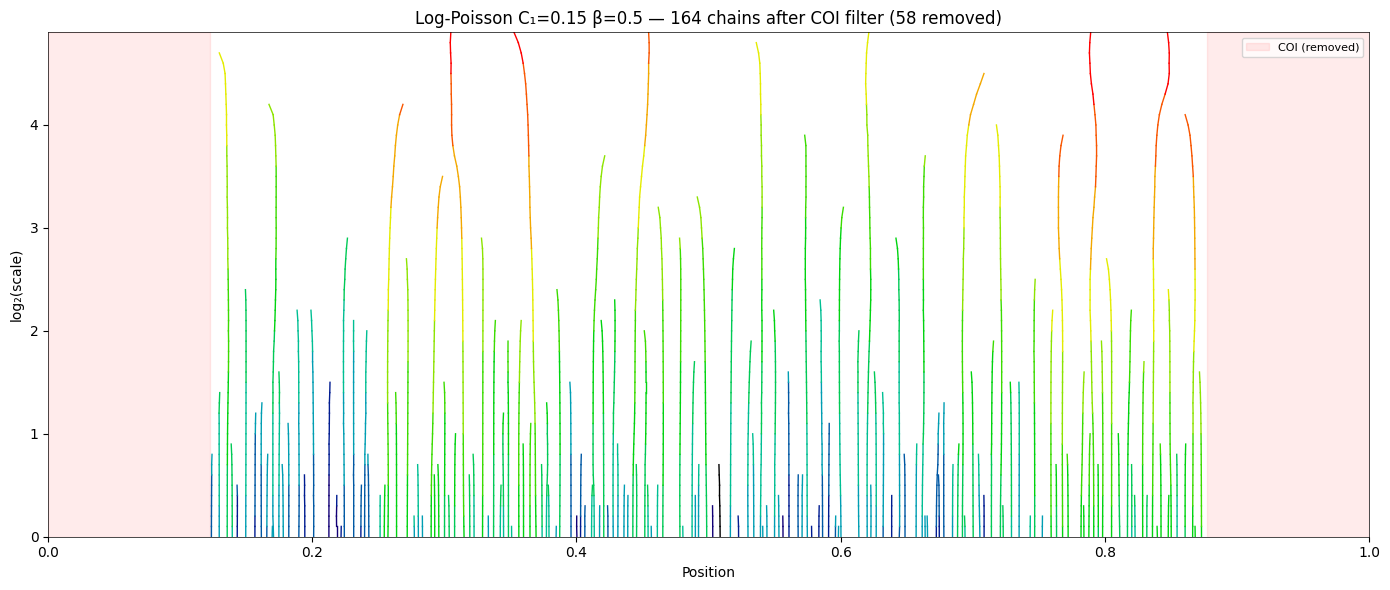

In [58]:
# Cell 17b: Cone-of-influence chain filtering
# Remove chains whose finest-scale position falls within the COI
# of the coarsest scale (boundary region where edge effects dominate).

REMOVE_COI_CHAINS = True  # <-- toggle this

if REMOVE_COI_CHAINS:
    # COI boundary from the coarsest scale's valid range
    coarsest_scale_idx = len(scales) - 1
    coi_left_idx, coi_right_idx = valid_ranges[coarsest_scale_idx]
    coi_left_pos = coi_left_idx * dx_signal   # convert index to position
    coi_right_pos = coi_right_idx * dx_signal

    # Find which finest-scale extrema are in the COI
    # (position < coi_left_pos or position > coi_right_pos)
    n_finest = len(extrep_abs[0])
    coi_mask = np.zeros(n_finest, dtype=bool)  # True = in COI, remove
    for fi in range(n_finest):
        pos = extrep_abs[0][fi]
        if pos < coi_left_pos or pos > coi_right_pos:
            coi_mask[fi] = True

    # Walk each COI chain from finest to coarsest, collecting (scale, index) to remove
    remove_set = []  # list of sets, one per scale
    for s in range(len(extrep_abs)):
        remove_set.append(set())

    for fi in range(n_finest):
        if not coi_mask[fi]:
            continue
        cs, ci = 0, fi
        while cs < len(extrep_abs) and ci != -1:
            remove_set[cs].add(ci)
            ci = coarser_links[cs][ci]
            cs += 1

    # Rebuild extrep arrays, removing marked extrema
    # Build index mapping (old -> new) per scale for link fixup
    n_removed_total = 0
    old_to_new = []  # per scale
    for s in range(len(extrep_abs)):
        n_old = len(extrep_abs[s])
        to_remove = remove_set[s]
        n_removed_total += len(to_remove)

        if len(to_remove) == 0:
            old_to_new.append({i: i for i in range(n_old)})
            continue

        keep_mask = np.array([i not in to_remove for i in range(n_old)])
        mapping = {}
        new_idx = 0
        for old_idx in range(n_old):
            if keep_mask[old_idx]:
                mapping[old_idx] = new_idx
                new_idx += 1
            else:
                mapping[old_idx] = -1
        old_to_new.append(mapping)

        extrep_abs[s] = extrep_abs[s][keep_mask]
        extrep_ord[s] = extrep_ord[s][keep_mask]
        extrep_idx[s] = extrep_idx[s][keep_mask]

    # Fix up coarser_links and finer_links with new indices
    for s in range(len(coarser_links)):
        n_cur = len(extrep_abs[s])
        new_cl = np.full(n_cur, -1, dtype=int)
        new_fl = np.full(n_cur, -1, dtype=int)

        old_cl = coarser_links[s]
        old_fl = finer_links[s]
        mapping_cur = old_to_new[s]
        mapping_coarser = old_to_new[s + 1] if s + 1 < len(old_to_new) else {}
        mapping_finer = old_to_new[s - 1] if s > 0 else {}

        for old_idx, new_idx in mapping_cur.items():
            if new_idx == -1:
                continue
            # Coarser link
            if old_idx < len(old_cl):
                old_target = old_cl[old_idx]
                if old_target != -1 and old_target in mapping_coarser:
                    new_cl[new_idx] = mapping_coarser[old_target]
                else:
                    new_cl[new_idx] = -1
            # Finer link
            if old_idx < len(old_fl):
                old_target = old_fl[old_idx]
                if old_target != -1 and old_target in mapping_finer:
                    new_fl[new_idx] = mapping_finer[old_target]
                else:
                    new_fl[new_idx] = -1

        coarser_links[s] = new_cl
        finer_links[s] = new_fl

    n_coi_chains = int(coi_mask.sum())
    n_remaining = sum(len(a) for a in extrep_abs)
    print(f'COI filtering: removed {n_coi_chains} chains ({n_removed_total} extrema across all scales)')
    print(f'  COI boundary (coarsest scale): position [{coi_left_pos:.4f}, {coi_right_pos:.4f}]')
    print(f'  COI boundary (indices): [{coi_left_idx}, {coi_right_idx}] of {SIZE}')
    print(f'  Remaining extrema: {n_remaining}')

    # Re-trace surviving chains for visualization
    post_coi_chains = trace_chains(extrep_abs, extrep_ord, coarser_links, scales, n_scales)
    print(f'  Surviving chains after COI filter: {len(post_coi_chains)}')

    # Visualization: show COI boundaries on maxima lines
    import matplotlib as mpl
    N_COLORS = 14
    fig, ax = plt.subplots(figsize=(14, 6))
    for spine in ax.spines.values(): spine.set_linewidth(0.5)

    # COI shading
    ax.axvspan(0, coi_left_pos, color='red', alpha=0.08, label='COI (removed)')
    ax.axvspan(coi_right_pos, 1.0, color='red', alpha=0.08)

    # Surviving chains colored by log2|ordinate|
    if len(post_coi_chains) > 0:
        all_log2_vals = np.concatenate([np.log2(np.abs(np.array(vals)) + 1e-300)
                                        for _, _, _, vals in post_coi_chains])
        vmin, vmax = np.percentile(all_log2_vals, [0, 100])
        boundaries = np.linspace(vmin, vmax, N_COLORS + 1)
        norm_c = mpl.colors.BoundaryNorm(boundaries, N_COLORS)
        cmap_c = lastwave_colormap(N_COLORS)
        for pos, sv, sign, vals in post_coi_chains:
            log2_v = np.log2(np.abs(np.array(vals)) + 1e-300)
            for j in range(len(pos) - 1):
                ax.plot(pos[j:j+2], sv[j:j+2], '-', color=cmap_c(norm_c(log2_v[j])), lw=1)

    ax.set_xlabel('Position')
    ax.set_ylabel('log₂(scale)')
    ax.set_title(f'{analysis_label} — {len(post_coi_chains)} chains after COI filter '
                 f'({n_coi_chains} removed)')
    ax.legend(fontsize=8, loc='upper right')
    ax.margins(0)
    plt.tight_layout()
    plt.show()
else:
    print('COI filtering: disabled (REMOVE_COI_CHAINS = False)')


Best internal R²:
  Range: log2(a) = [2.20, 4.10]  (1.9 octaves)
  Mean R² = 0.975535

Best tau(q) theory fit:
  Range: log2(a) = [0.00, 1.00]  (1.0 octaves)
  tau(q) RMSE = 6.613050, R² = 0.909437

Best D(h) spectrum fit:
  Range: log2(a) = [1.10, 2.10]  (1.0 octaves)
  D(h) score = 32.824805 (lower=better)
  R² = 0.887799, tau RMSE = 6.693107

Current setting: LOG2_A_MIN=0.0, LOG2_A_MAX=4.9


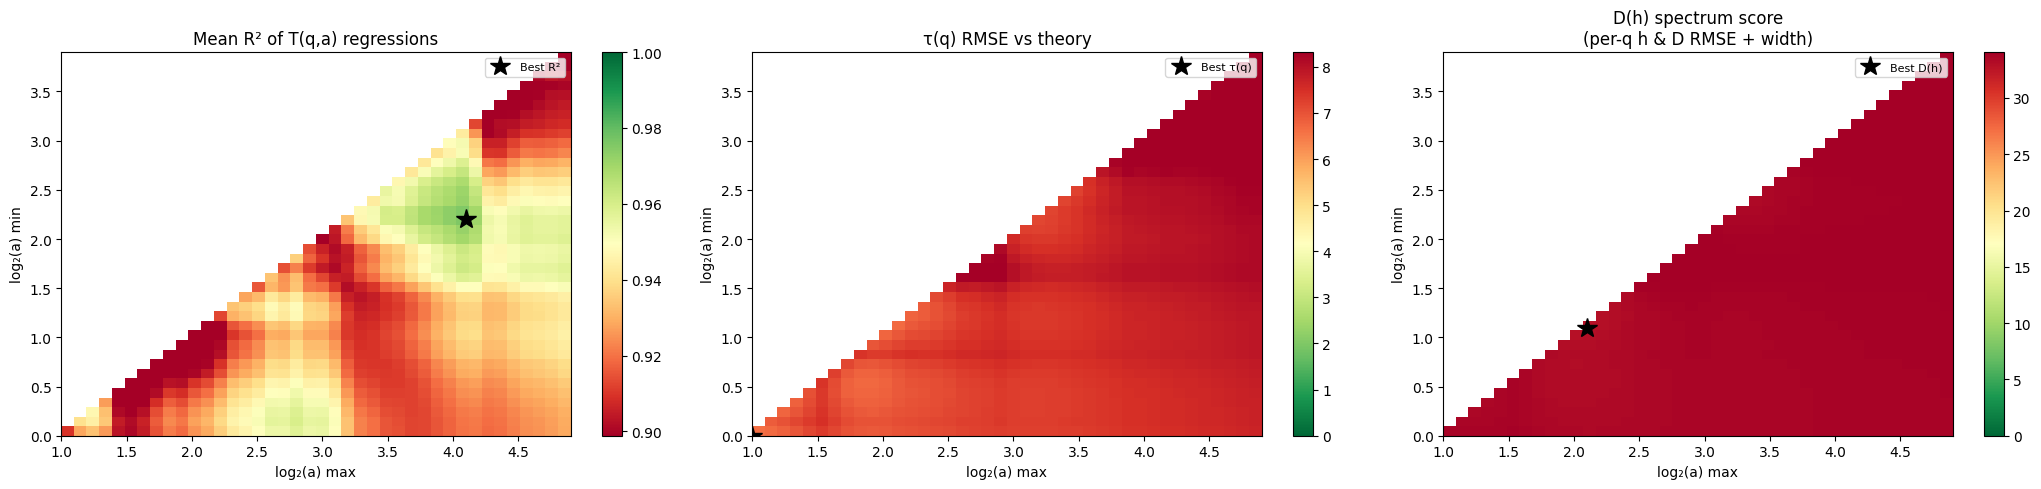

In [70]:
# Cell 20: Optimal regression range search
# Grid search over (log2_a_min, log2_a_max) to find the range that:
#   1. Best internal R² — how linear are T(q,a) vs log2(a) within the range
#   2. Best theory fit — how close are the resulting tau(q) to analytical values
#   3. Best D(h) spectrum — per-q D(h) match and spectrum width agreement

LOG2_A_MIN = 0.0
LOG2_A_MAX = 4.9

from wtmm.partition import pf_get_T, pf_get_H, pf_get_D
from wtmm.spectra import compute_spectra

log2_a = pf['log2_a']
n_voice = pf['n_voice']
log2_a0 = np.log2(pf['a_min'])
dx = 1.0 / n_voice
max_idx = pf['index_max']

# Build grid: all (min, max) pairs with at least 1 octave separation
min_octave_span = 1.0
grid_step = dx  # step in log2(a) units

lo_vals = np.arange(log2_a0, log2_a0 + dx * max_idx - min_octave_span + dx/2, grid_step)
hi_vals = np.arange(log2_a0 + min_octave_span, log2_a0 + dx * max_idx + dx/2, grid_step)

q_array = pf['q_list']
n_q = len(q_array)

# Precompute T(q,a), H(q,a), D(q,a) for all q
T_all = np.zeros((n_q, max_idx + 1))
H_all = np.zeros((n_q, max_idx + 1))
D_all = np.zeros((n_q, max_idx + 1))
for qi in range(n_q):
    T_all[qi] = pf_get_T(pf, qi, 'extensive')[:max_idx + 1]
    H_all[qi] = pf_get_H(pf, qi, 'extensive')[:max_idx + 1]
    D_all[qi] = pf_get_D(pf, qi, q_array[qi], 'extensive')[:max_idx + 1]

# Theory values at the partition function q values (if available)
is_multifractal_theory = has_theory and theory_h is not None and len(theory_h) > 1
if has_theory:
    tau_theory_at_q = np.interp(q_array, theory_q, theory_tau)
if is_multifractal_theory:
    h_theory_at_q = np.interp(q_array, theory_q, theory_h)
    D_theory_at_q = np.interp(q_array, theory_q, theory_D)
    # Theory spectrum width: range of h where D > 0
    _tmask = theory_D > 0
    theory_width = theory_h[_tmask].max() - theory_h[_tmask].min() if _tmask.any() else 0.0

results = []  # (lo, hi, mean_r2, tau_rmse, dh_score)

for lo in lo_vals:
    idx_lo = int(round((lo - log2_a0) / dx))
    idx_lo = max(idx_lo, 0)
    for hi in hi_vals:
        if hi - lo < min_octave_span - 1e-9:
            continue
        idx_hi = int(round((hi - log2_a0) / dx))
        idx_hi = min(idx_hi, max_idx)
        if idx_hi - idx_lo < 2:
            continue

        vidx = np.arange(idx_lo, idx_hi + 1)
        x = log2_a0 + dx * vidx

        # Compute R² and slopes for T, H, D
        r2_list = []
        tau_fit = np.full(n_q, np.nan)
        h_fit = np.full(n_q, np.nan)
        d_fit = np.full(n_q, np.nan)
        for qi in range(n_q):
            y_T = T_all[qi, vidx]
            y_H = H_all[qi, vidx]
            y_D = D_all[qi, vidx]
            if not np.all(np.isfinite(y_T)):
                continue
            slope_T, intercept_T = np.polyfit(x, y_T, 1)
            tau_fit[qi] = slope_T
            y_pred = slope_T * x + intercept_T
            ss_res = np.sum((y_T - y_pred)**2)
            ss_tot = np.sum((y_T - np.mean(y_T))**2)
            r2 = 1.0 - ss_res / ss_tot if ss_tot > 1e-30 else 1.0
            r2_list.append(r2)
            if np.all(np.isfinite(y_H)):
                h_fit[qi] = np.polyfit(x, y_H, 1)[0]
            if np.all(np.isfinite(y_D)):
                d_fit[qi] = np.polyfit(x, y_D, 1)[0]

        if len(r2_list) == 0:
            continue
        mean_r2 = np.mean(r2_list)

        # Theory tau RMSE
        if has_theory:
            vm = np.isfinite(tau_fit)
            tau_rmse = np.sqrt(np.mean((tau_fit[vm] - tau_theory_at_q[vm])**2)) if vm.any() else np.inf
        else:
            tau_rmse = np.nan

        # D(h) spectrum score: per-q comparison of (h(q), D(q)) pairs
        if is_multifractal_theory:
            vm = np.isfinite(h_fit) & np.isfinite(d_fit)
            if vm.sum() >= 3:
                # Per-q h(q) RMSE
                h_rmse = np.sqrt(np.mean((h_fit[vm] - h_theory_at_q[vm])**2))
                # Per-q D(q) RMSE
                d_rmse = np.sqrt(np.mean((d_fit[vm] - D_theory_at_q[vm])**2))
                # Spectrum width comparison
                wtmm_width = h_fit[vm].max() - h_fit[vm].min()
                width_error = abs(wtmm_width - theory_width) / max(theory_width, 1e-10)
                # Combined score: geometric mean of normalized errors
                dh_score = np.sqrt(h_rmse**2 + d_rmse**2 + (width_error * 0.5)**2)
            else:
                dh_score = np.inf
        else:
            dh_score = np.nan

        results.append((lo, hi, mean_r2, tau_rmse, dh_score))

results = np.array(results)

# --- Find best ranges ---
# 1. Best R²
best_r2_idx = np.argmax(results[:, 2])
best_r2 = results[best_r2_idx]
print(f'Best internal R²:')
print(f'  Range: log2(a) = [{best_r2[0]:.2f}, {best_r2[1]:.2f}]  '
      f'({best_r2[1]-best_r2[0]:.1f} octaves)')
print(f'  Mean R² = {best_r2[2]:.6f}')

if has_theory:
    # 2. Best theory tau fit
    best_thy_idx = np.argmin(results[:, 3])
    best_thy = results[best_thy_idx]
    print(f'\nBest tau(q) theory fit:')
    print(f'  Range: log2(a) = [{best_thy[0]:.2f}, {best_thy[1]:.2f}]  '
          f'({best_thy[1]-best_thy[0]:.1f} octaves)')
    print(f'  tau(q) RMSE = {best_thy[3]:.6f}, R² = {best_thy[2]:.6f}')

    # 3. Combined: best theory fit among ranges with R² > 0.99
    good_r2_mask = results[:, 2] > 0.99
    if good_r2_mask.any():
        good_results = results[good_r2_mask]
        best_combo_idx = np.argmin(good_results[:, 3])
        best_combo = good_results[best_combo_idx]
        print(f'\nBest combined (R²>0.99, then min tau RMSE):')
        print(f'  Range: log2(a) = [{best_combo[0]:.2f}, {best_combo[1]:.2f}]  '
              f'({best_combo[1]-best_combo[0]:.1f} octaves)')
        print(f'  tau(q) RMSE = {best_combo[3]:.6f}, R² = {best_combo[2]:.6f}')

if is_multifractal_theory:
    # 4. Best D(h) spectrum match
    best_dh_idx = np.argmin(results[:, 4])
    best_dh = results[best_dh_idx]
    print(f'\nBest D(h) spectrum fit:')
    print(f'  Range: log2(a) = [{best_dh[0]:.2f}, {best_dh[1]:.2f}]  '
          f'({best_dh[1]-best_dh[0]:.1f} octaves)')
    print(f'  D(h) score = {best_dh[4]:.6f} (lower=better)')
    print(f'  R² = {best_dh[2]:.6f}, tau RMSE = {best_dh[3]:.6f}')

    # Best D(h) among good R² ranges
    if good_r2_mask.any():
        best_dh_combo_idx = np.argmin(good_results[:, 4])
        best_dh_combo = good_results[best_dh_combo_idx]
        print(f'\nBest D(h) (R²>0.99):')
        print(f'  Range: log2(a) = [{best_dh_combo[0]:.2f}, {best_dh_combo[1]:.2f}]  '
              f'({best_dh_combo[1]-best_dh_combo[0]:.1f} octaves)')
        print(f'  D(h) score = {best_dh_combo[4]:.6f}, R² = {best_dh_combo[2]:.6f}')

print(f'\nCurrent setting: LOG2_A_MIN={LOG2_A_MIN}, LOG2_A_MAX={LOG2_A_MAX}')

# --- Visualization ---
n_panels = 1 + (1 if has_theory else 0) + (1 if is_multifractal_theory else 0)
fig, axes = plt.subplots(1, n_panels, figsize=(7 * n_panels, 5))
if n_panels == 1:
    axes = [axes]

# Reshape for heatmaps
lo_unique = np.sort(np.unique(results[:, 0]))
hi_unique = np.sort(np.unique(results[:, 1]))
lo_to_i = {v: i for i, v in enumerate(lo_unique)}
hi_to_j = {v: j for j, v in enumerate(hi_unique)}

r2_grid = np.full((len(lo_unique), len(hi_unique)), np.nan)
rmse_grid = np.full((len(lo_unique), len(hi_unique)), np.nan)
dh_grid = np.full((len(lo_unique), len(hi_unique)), np.nan)
for row in results:
    lo, hi, r2, rmse, dh = row
    i, j = lo_to_i[lo], hi_to_j[hi]
    r2_grid[i, j] = r2
    rmse_grid[i, j] = rmse
    dh_grid[i, j] = dh

extent = [hi_unique[0], hi_unique[-1], lo_unique[0], lo_unique[-1]]
panel = 0

# Panel 1: R² heatmap
ax = axes[panel]
im = ax.imshow(r2_grid, aspect='auto', origin='lower', extent=extent,
               cmap='RdYlGn', vmin=np.nanpercentile(r2_grid, 5), vmax=1.0)
ax.plot(best_r2[1], best_r2[0], 'k*', markersize=15, label='Best R²')
ax.set_xlabel('log₂(a) max'); ax.set_ylabel('log₂(a) min')
ax.set_title('Mean R² of T(q,a) regressions')
ax.legend(fontsize=8)
plt.colorbar(im, ax=ax)
panel += 1

# Panel 2: tau(q) RMSE
if has_theory:
    ax = axes[panel]
    vmax_rmse = np.nanpercentile(rmse_grid, 90)
    im2 = ax.imshow(rmse_grid, aspect='auto', origin='lower', extent=extent,
                    cmap='RdYlGn_r', vmin=0, vmax=vmax_rmse)
    ax.plot(best_thy[1], best_thy[0], 'k*', markersize=15, label='Best τ(q)')
    if good_r2_mask.any():
        ax.plot(best_combo[1], best_combo[0], 'b^', markersize=12, label='Best combo')
    ax.set_xlabel('log₂(a) max'); ax.set_ylabel('log₂(a) min')
    ax.set_title('τ(q) RMSE vs theory')
    ax.legend(fontsize=8)
    plt.colorbar(im2, ax=ax)
    panel += 1

# Panel 3: D(h) spectrum score
if is_multifractal_theory:
    ax = axes[panel]
    vmax_dh = np.nanpercentile(dh_grid, 90)
    im3 = ax.imshow(dh_grid, aspect='auto', origin='lower', extent=extent,
                    cmap='RdYlGn_r', vmin=0, vmax=vmax_dh)
    ax.plot(best_dh[1], best_dh[0], 'k*', markersize=15, label='Best D(h)')
    if good_r2_mask.any():
        ax.plot(best_dh_combo[1], best_dh_combo[0], 'b^', markersize=12, label='Best D(h) R²>0.99')
    ax.set_xlabel('log₂(a) max'); ax.set_ylabel('log₂(a) min')
    ax.set_title('D(h) spectrum score\n(per-q h & D RMSE + width)')
    ax.legend(fontsize=8)
    plt.colorbar(im3, ax=ax)

plt.tight_layout()
plt.show()

Partition function computed in 0.004s, up to scale index 49
Extrema per scale (sample): [508 478 454 427 392]...[24 22 21 18 17]


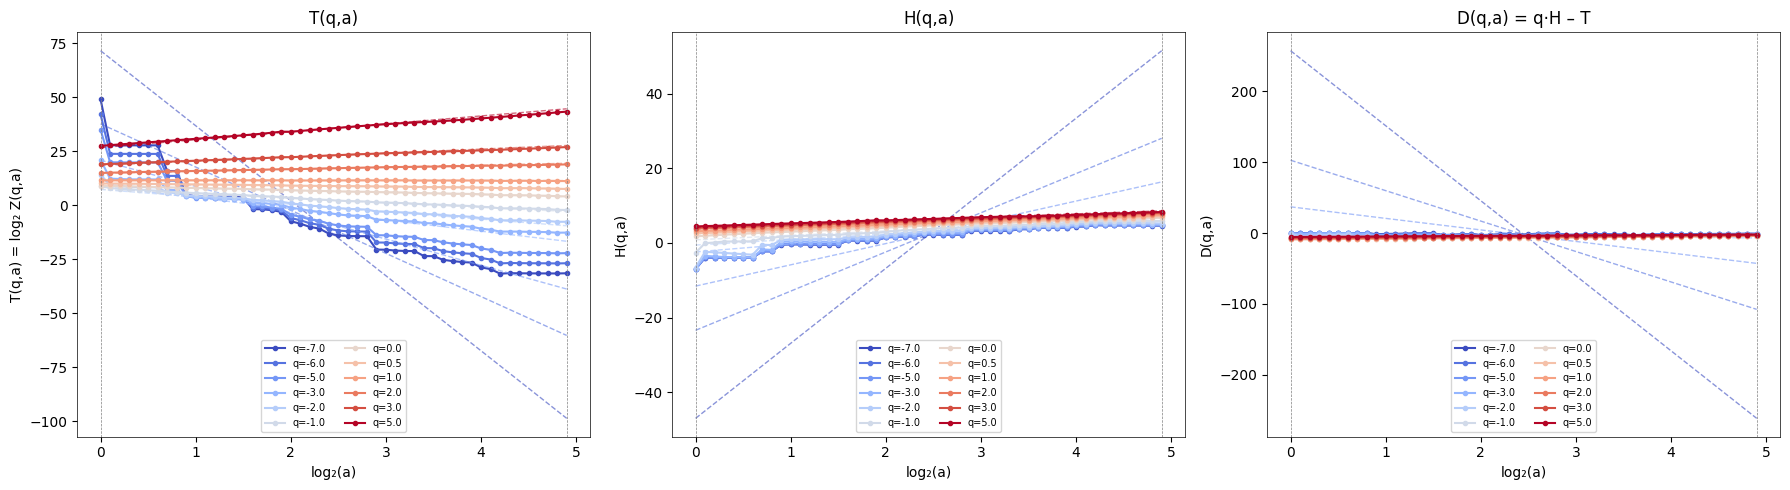

Gray dashed lines show regression range [log2(a)=0 to 4.9]


In [71]:
# Cell 18: Partition function — now imported from wtmm package
from wtmm.partition import compute_partition_function, pf_get_T, pf_get_H, pf_get_D
from wtmm.spectra import plot_partition_functions

LOG2_A_MIN = 0
LOG2_A_MAX = 4.9
NORMALIZE_PF = False  # Toggle: shift curves to zero at midpoint for theory comparison

# Compute partition function
q_list = [-7, -6, -5, -3, -2, -1, 0, 0.5, 1, 2, 3, 5]

t0 = time.time()
pf = compute_partition_function(extrep_ord, n_oct=N_OCT, n_voice=N_VOICE, a_min=A_MIN, q_list=q_list)
t1 = time.time()
print(f'Partition function computed in {t1-t0:.3f}s, up to scale index {pf["index_max"]}')
print(f'Extrema per scale (sample): {pf["n_ext"][:5]}...{pf["n_ext"][-5:]}')

# Plot T(q,a), H(q,a), D(q,a) with optional theory overlay
fig, axes = plot_partition_functions(
    pf, LOG2_A_MIN, LOG2_A_MAX,
    theory_q=theory_q, theory_tau=theory_tau,
    theory_h=theory_h, theory_D=theory_D,
    normalize=NORMALIZE_PF,
)
plt.show()
print(f'Gray dashed lines show regression range [log2(a)={LOG2_A_MIN} to {LOG2_A_MAX}]')
if NORMALIZE_PF:
    print(f'Curves normalized to zero at log2(a) = {0.5*(LOG2_A_MIN+LOG2_A_MAX):.2f}')
    print(f'Dashed lines = theoretical slopes (no intercept fitting needed)')


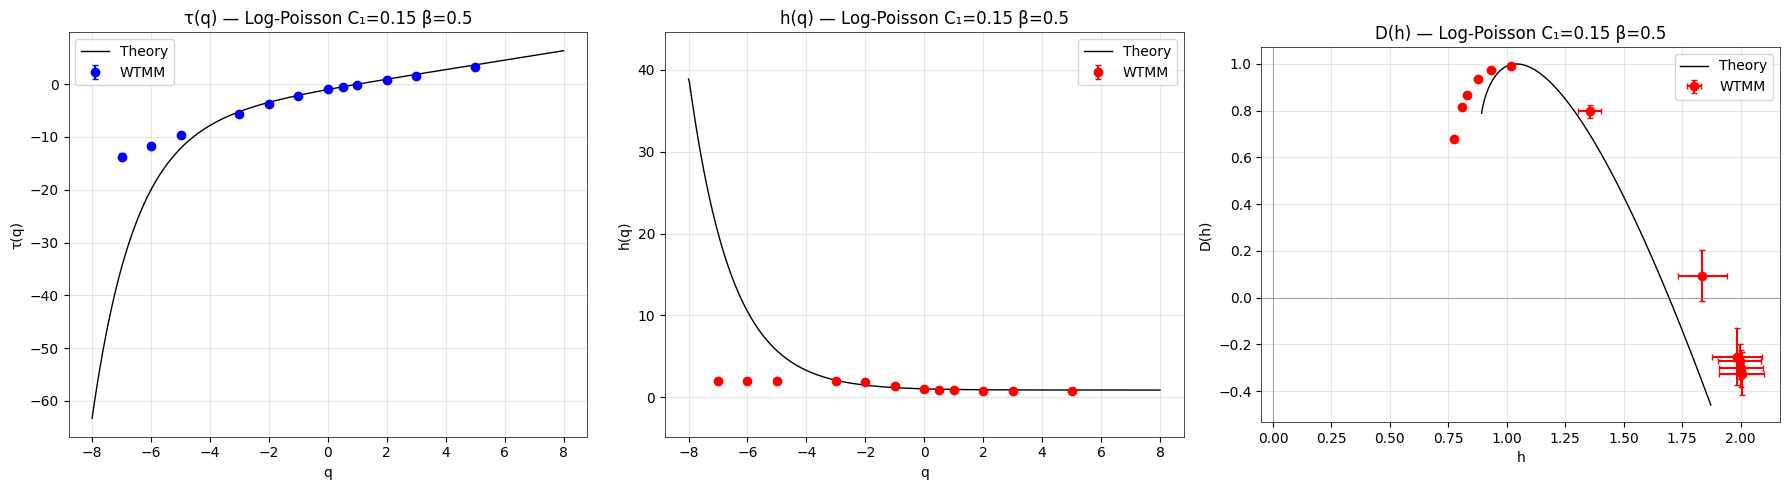


Log-Poisson C₁=0.15 β=0.5: theory vs WTMM comparison
h range: [0.896, 20.094]

    q	 tau_WTMM	 tau_theory	    diff		   h_WTMM	 h_theory
 -7.0	 -13.7088	 -34.7270	 +21.0182	   1.9972	  20.0941
 -6.0	 -11.7092	 -19.9851	 +8.2759	   2.0020	  10.4931
 -5.0	  -9.7051	 -12.1679	 +2.4628	   2.0059	   5.6925
 -3.0	  -5.7003	  -5.1902	 -0.5100	   1.9840	   2.0919
 -2.0	  -3.7690	  -3.4328	 -0.3362	   1.8371	   1.4919
 -1.0	  -2.1521	  -2.1082	 -0.0439	   1.3550	   1.1918
  0.0	  -0.9929	  -1.0000	 +0.0071	   1.0171	   1.0418
  0.5	  -0.5073	  -0.4907	 -0.0166	   0.9309	   0.9979
  1.0	  -0.0565	  -0.0000	 -0.0565	   0.8771	   0.9668
  2.0	   0.7926	   0.9459	 -0.1533	   0.8300	   0.9293
  3.0	   1.6117	   1.8647	 -0.2530	   0.8096	   0.9105
  5.0	   3.1960	   3.6686	 -0.4726	   0.7751	   0.8965


In [72]:
# Cell 19: tau(q), h(q), D(h) spectrum — now imported from wtmm package
from wtmm.spectra import compute_spectra, plot_spectra, print_spectra_comparison

# Compute spectra
spectra = compute_spectra(pf, log2_a_min=LOG2_A_MIN, log2_a_max=LOG2_A_MAX)

# --- Toggle error bars ---
SHOW_ERRORS = True

# --- Plot ---
fig, axes = plot_spectra(
    spectra, label=analysis_label,
    theory_q=theory_q, theory_tau=theory_tau,
    theory_h=theory_h, theory_D=theory_D,
    show_errors=SHOW_ERRORS,
)
plt.show()

# --- Print comparison ---
print_spectra_comparison(
    spectra, label=analysis_label,
    theory_q=theory_q, theory_tau=theory_tau,
    theory_h=theory_h, theory_D=theory_D,
)


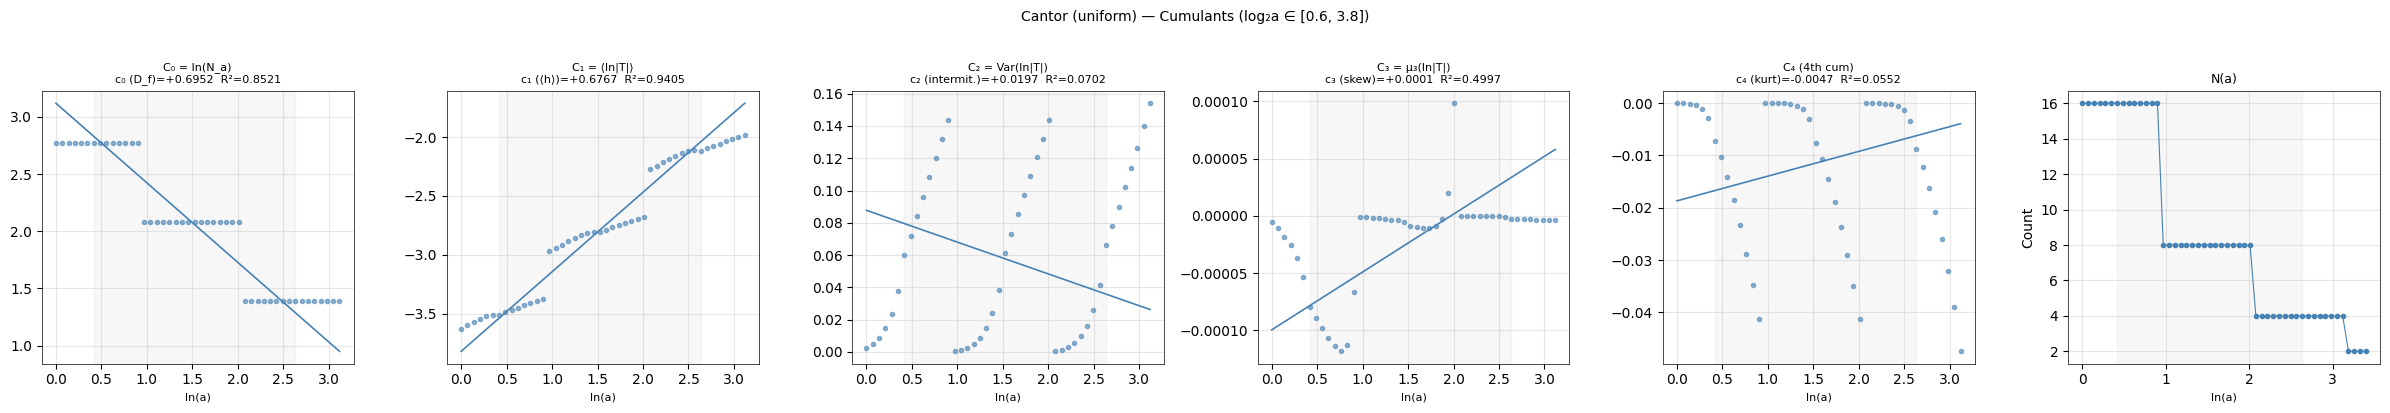

=== Cumulant coefficients ===
                c₀ (D_f) = +0.6952 ± 0.0520   R² = 0.852101
                c₁ (⟨h⟩) = +0.6767 ± 0.0306   R² = 0.940527
          c₂ (intermit.) = +0.0197 ± 0.0129   R² = 0.070183
               c₃ (skew) = +0.0001 ± 0.0000   R² = 0.499650
               c₄ (kurt) = -0.0047 ± 0.0035   R² = 0.055229


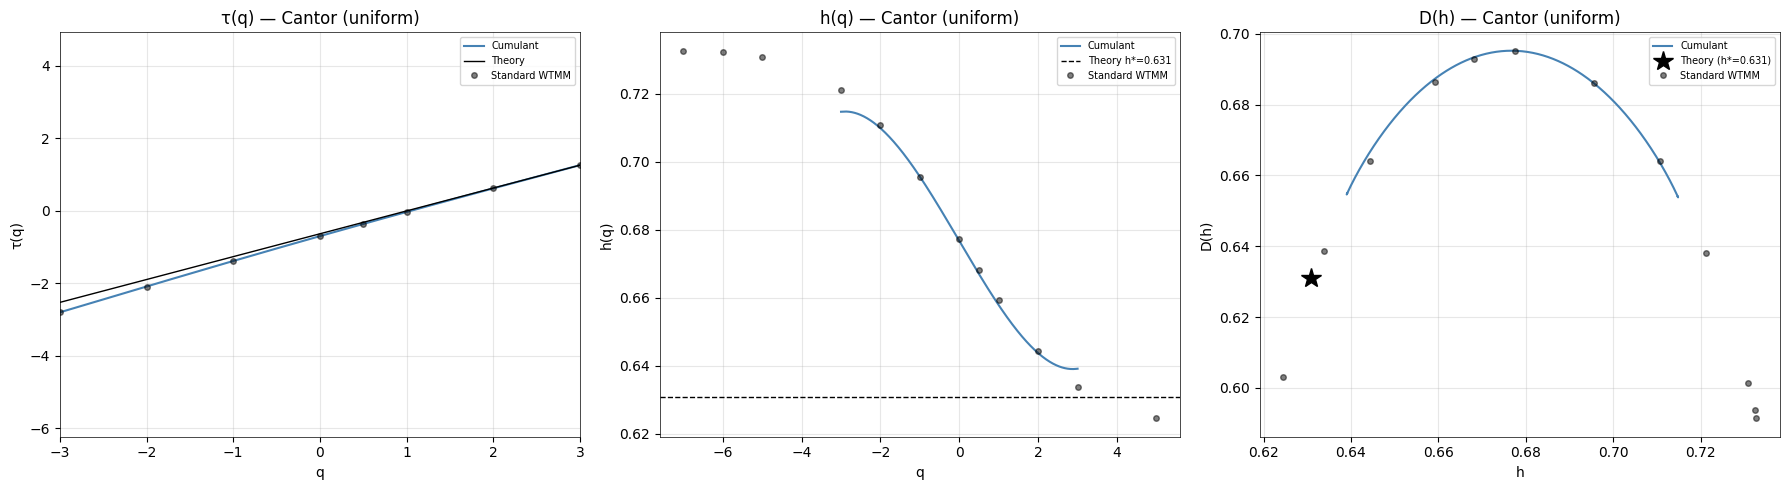


c₃ = +0.0001 ≈ 0 → approximately log-normal cascade


In [14]:
# Cumulant analysis — non-truncated only
# τ(q) = -c₀ + c₁q - c₂q²/2! + c₃q³/3! + ...
# cₙ = slope of Cₙ(a) vs ln(a)

Q_RANGE_CUMULANT = (-3, 3)  # valid q range for reconstruction

n_scales = len(extrep_ord)
n_voice_cum = pf['n_voice']
ln_a = np.log(scales[:n_scales])

# --- Compute cumulants C_n(a) at each scale ---
cumulant_names = ['C₀ = ln(N_a)', 'C₁ = ⟨ln|T|⟩', 'C₂ = Var(ln|T|)',
                  'C₃ = μ₃(ln|T|)', 'C₄ (4th cum)']
names_short = ['c₀ (D_f)', 'c₁ (⟨h⟩)', 'c₂ (intermit.)', 'c₃ (skew)', 'c₄ (kurt)']
n_cumulants = len(cumulant_names)
sign_conv = [-1, 1, -1, 1, -1]

C = np.full((n_cumulants, n_scales), np.nan)
N_a = np.zeros(n_scales)

for s in range(n_scales):
    ords = extrep_ord[s]
    N_a[s] = len(ords)
    if len(ords) < 3:
        continue
    ln_T = np.log(np.abs(ords) + 1e-300)
    m1 = np.mean(ln_T)
    d = ln_T - m1
    C[0, s] = np.log(len(ords))
    C[1, s] = m1
    C[2, s] = np.mean(d**2)
    C[3, s] = np.mean(d**3)
    C[4, s] = np.mean(d**4) - 3 * np.mean(d**2)**2

# --- Fit slopes over regression range ---
log2_a0 = np.log2(scales[0])
dx_scale = 1.0 / n_voice_cum
idx_lo = max(int(round((LOG2_A_MIN - log2_a0) / dx_scale)), 0)
idx_hi = min(int(round((LOG2_A_MAX - log2_a0) / dx_scale)), n_scales - 1)
fit_idx = np.arange(idx_lo, idx_hi + 1)
x_fit = ln_a[fit_idx]

c_coeffs = np.zeros(n_cumulants)
c_err = np.zeros(n_cumulants)
c_r2 = np.zeros(n_cumulants)

fig, axes = plt.subplots(1, n_cumulants + 1, figsize=(4 * (n_cumulants + 1), 4))
for ax_ in axes:
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

for n in range(n_cumulants):
    ax = axes[n]
    valid = np.isfinite(C[n])
    ax.plot(ln_a[valid], C[n, valid], 'o', color='steelblue', markersize=3, alpha=0.6)
    ax.axvspan(ln_a[idx_lo], ln_a[idx_hi], color='gray', alpha=0.06)

    y_fit = C[n, fit_idx]
    fmask = np.isfinite(y_fit)
    if fmask.sum() >= 3:
        slope, intercept = np.polyfit(x_fit[fmask], y_fit[fmask], 1)
        c_coeffs[n] = sign_conv[n] * slope
        y_pred = slope * x_fit[fmask] + intercept
        ss_res = np.sum((y_fit[fmask] - y_pred)**2)
        ss_tot = np.sum((y_fit[fmask] - y_fit[fmask].mean())**2)
        c_r2[n] = 1.0 - ss_res / ss_tot if ss_tot > 1e-30 else 1.0
        n_pts = fmask.sum()
        c_err[n] = np.sqrt(ss_res / max(n_pts - 2, 1) /
                           np.sum((x_fit[fmask] - x_fit[fmask].mean())**2)) if n_pts > 2 else 0
        x_line = np.array([ln_a[valid].min(), ln_a[valid].max()])
        ax.plot(x_line, slope * x_line + intercept, '-', color='steelblue', lw=1.2)

    ax.set_title(f'{cumulant_names[n]}\n{names_short[n]}={c_coeffs[n]:+.4f}  R²={c_r2[n]:.4f}', fontsize=8)
    ax.set_xlabel('ln(a)', fontsize=8)
    ax.grid(True, alpha=0.3)

# N(a) panel
ax = axes[n_cumulants]
ax.plot(ln_a, N_a, 'o-', color='steelblue', markersize=3, lw=0.8)
ax.axvspan(ln_a[idx_lo], ln_a[idx_hi], color='gray', alpha=0.06)
ax.set_title('N(a)', fontsize=9)
ax.set_xlabel('ln(a)', fontsize=8)
ax.set_ylabel('Count')
ax.grid(True, alpha=0.3)

plt.suptitle(f'{analysis_label} — Cumulants (log₂a ∈ [{LOG2_A_MIN}, {LOG2_A_MAX}])', fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

# --- Print coefficients ---
print(f'=== Cumulant coefficients ===')
for n in range(n_cumulants):
    print(f'  {names_short[n]:>22s} = {c_coeffs[n]:+.4f} ± {c_err[n]:.4f}   R² = {c_r2[n]:.6f}')

# --- Reconstruct τ(q), h(q), D(h) ---
q_recon = np.linspace(Q_RANGE_CUMULANT[0], Q_RANGE_CUMULANT[1], 500)

tau_cum = -c_coeffs[0] + c_coeffs[1]*q_recon - c_coeffs[2]*q_recon**2/2 + c_coeffs[3]*q_recon**3/6 - c_coeffs[4]*q_recon**4/24
h_cum = np.gradient(tau_cum, q_recon)
D_cum = q_recon * h_cum - tau_cum

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax_ in axes:
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

# τ(q)
ax = axes[0]
ax.plot(q_recon, tau_cum, '-', color='steelblue', lw=1.5, label='Cumulant')
if has_theory:
    ax.plot(theory_q, theory_tau, 'k-', lw=1, label='Theory')
ax.plot(spectra['q_list'], spectra['tau_q'], 'ko', markersize=4, alpha=0.5, label='Standard WTMM')
ax.set_xlabel('q'); ax.set_ylabel('τ(q)')
ax.set_title(f'τ(q) — {analysis_label}')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
ax.set_xlim(Q_RANGE_CUMULANT[0], Q_RANGE_CUMULANT[1])

# h(q)
ax = axes[1]
ax.plot(q_recon, h_cum, '-', color='steelblue', lw=1.5, label='Cumulant')
if has_theory and theory_h is not None and len(theory_h) > 1:
    ax.plot(theory_q, theory_h, 'k-', lw=1, label='Theory')
elif has_theory and theory_h is not None and len(theory_h) == 1:
    ax.axhline(theory_h[0], color='k', ls='--', lw=1, label=f'Theory h*={theory_h[0]:.3f}')
ax.plot(spectra['q_list'], spectra['h_q'], 'ko', markersize=4, alpha=0.5, label='Standard WTMM')
ax.set_xlabel('q'); ax.set_ylabel('h(q)')
ax.set_title(f'h(q) — {analysis_label}')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# D(h)
ax = axes[2]
m = D_cum > -0.5
ax.plot(h_cum[m], D_cum[m], '-', color='steelblue', lw=1.5, label='Cumulant')
if has_theory and theory_h is not None and len(theory_h) > 1:
    tm = theory_D > -0.5
    ax.plot(theory_h[tm], theory_D[tm], 'k-', lw=1, label='Theory')
elif has_theory and theory_h is not None and len(theory_h) == 1:
    ax.plot(theory_h[0], theory_D[0], 'k*', markersize=15, label=f'Theory (h*={theory_h[0]:.3f})')
ax.plot(spectra['h_q'], spectra['D_q'], 'ko', markersize=4, alpha=0.5, linestyle='none', label='Standard WTMM')
ax.set_xlabel('h'); ax.set_ylabel('D(h)')
ax.set_title(f'D(h) — {analysis_label}')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Log-normality check: if c₃ ≈ 0, the cascade is approximately log-normal
if abs(c_coeffs[3]) < 0.01:
    print(f'\nc₃ = {c_coeffs[3]:+.4f} ≈ 0 → approximately log-normal cascade')
else:
    print(f'\nc₃ = {c_coeffs[3]:+.4f} → departure from log-normality')


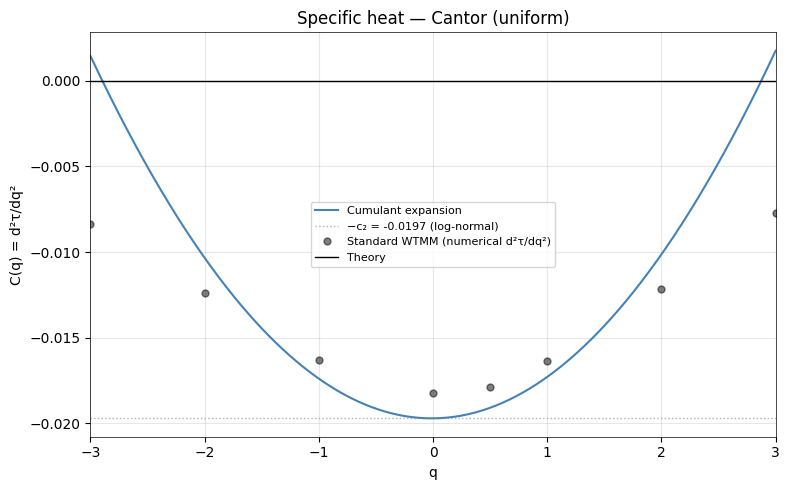

c₂ = 0.0197  →  −c₂ = -0.0197
c₃ = 0.0001  (slope of C(q) at q=0; =0 for log-normal)


In [15]:
# Specific heat C(q) = d²τ/dq²
# From cumulant expansion: C(q) = -c₂ + c₃q - c₄q²/2 + ...
# Monofractal: C(q) = 0 | Log-normal: C(q) = -c₂ (constant) | Phase transition: discontinuity

q_recon_ch = np.linspace(Q_RANGE_CUMULANT[0], Q_RANGE_CUMULANT[1], 500)

# Analytical from cumulant coefficients
C_heat_cum = -c_coeffs[2] + c_coeffs[3] * q_recon_ch - c_coeffs[4] * q_recon_ch**2 / 2

# Numerical from standard WTMM τ(q)
q_wtmm = spectra['q_list']
tau_wtmm = spectra['tau_q']
finite = np.isfinite(tau_wtmm)
if finite.sum() >= 3:
    C_heat_wtmm = np.gradient(np.gradient(tau_wtmm[finite], q_wtmm[finite]), q_wtmm[finite])
else:
    C_heat_wtmm = None

fig, ax = plt.subplots(figsize=(8, 5))
for spine in ax.spines.values(): spine.set_linewidth(0.5)

ax.plot(q_recon_ch, C_heat_cum, '-', color='steelblue', lw=1.5, label='Cumulant expansion')
ax.axhline(-c_coeffs[2], color='gray', ls=':', lw=1, alpha=0.6, label=f'−c₂ = {-c_coeffs[2]:.4f} (log-normal)')
ax.axhline(0, color='k', ls='-', lw=0.5, alpha=0.3)

if C_heat_wtmm is not None:
    ax.plot(q_wtmm[finite], C_heat_wtmm, 'ko', markersize=5, alpha=0.5, label='Standard WTMM (numerical d²τ/dq²)')

if has_theory:
    tau_th_fine = np.interp(q_recon_ch, theory_q, theory_tau)
    C_heat_theory = np.gradient(np.gradient(tau_th_fine, q_recon_ch), q_recon_ch)
    ax.plot(q_recon_ch, C_heat_theory, 'k-', lw=1, label='Theory')

ax.set_xlabel('q')
ax.set_ylabel('C(q) = d²τ/dq²')
ax.set_title(f'Specific heat — {analysis_label}')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xlim(Q_RANGE_CUMULANT[0], Q_RANGE_CUMULANT[1])
plt.tight_layout()
plt.show()

print(f'c₂ = {c_coeffs[2]:.4f}  →  −c₂ = {-c_coeffs[2]:.4f}')
print(f'c₃ = {c_coeffs[3]:.4f}  (slope of C(q) at q=0; =0 for log-normal)')


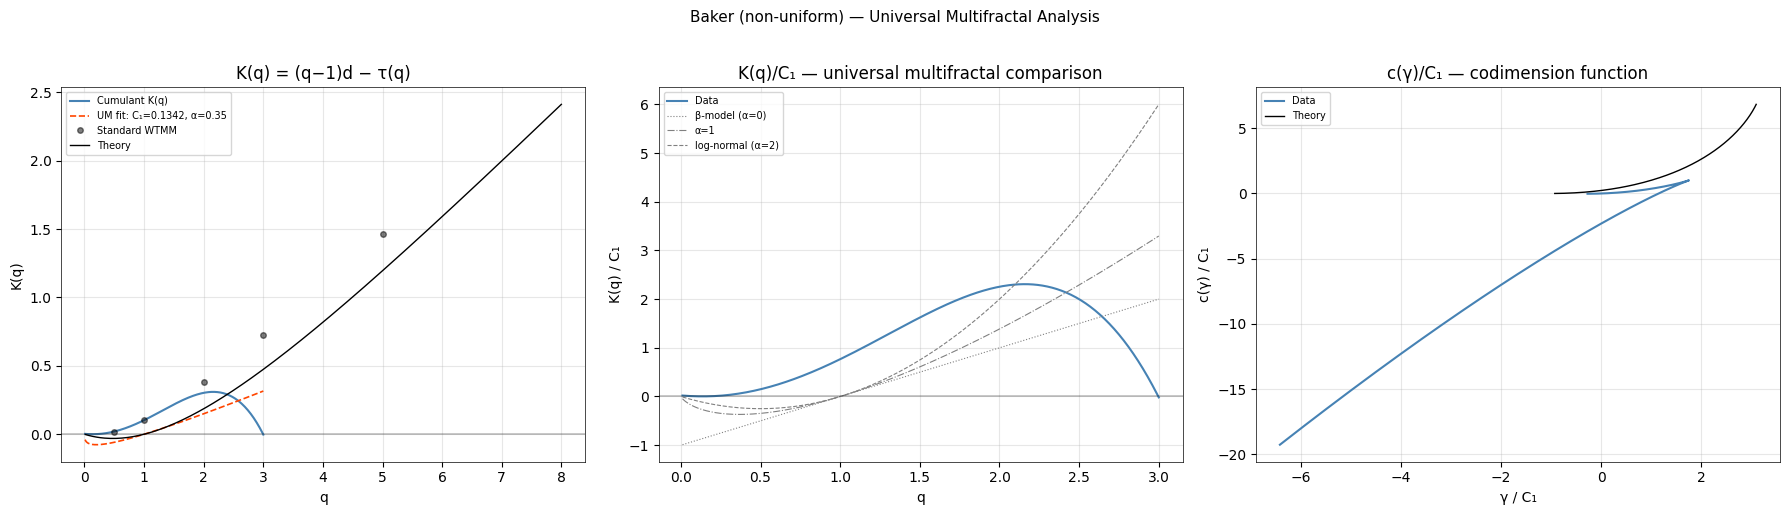

=== Universal Multifractal Parameters ===
  C₁ = 0.1342 ± 0.0125  (intermittency, cf. c₂ = 0.2992)
  α  = 0.347 ± 0.215  (Lévy index, 0=β-model, 2=log-normal)
  → Lévy multifractal with α = 0.35


In [ ]:
# Universal Multifractal parameters (C₁, α) from WTMM
# K(q) = (q-1)·d - τ(q),  fit K(q) = C₁/(α-1)·(q^α - q) for α∈(0,2]
# c(γ) = Legendre transform of K(q) = codimension function = d - D(h)

from scipy.optimize import curve_fit

d = 1  # embedding dimension

# --- Compute K(q) from cumulant τ(q) ---
q_K = np.linspace(0.01, Q_RANGE_CUMULANT[1], 300)  # q > 0 for K(q)
tau_cum_K = -c_coeffs[0] + c_coeffs[1]*q_K - c_coeffs[2]*q_K**2/2 + c_coeffs[3]*q_K**3/6 - c_coeffs[4]*q_K**4/24
K_q = (q_K - 1) * d - tau_cum_K

# Also from standard WTMM
q_wtmm = np.array(spectra['q_list'], dtype=float)
tau_wtmm = np.array(spectra['tau_q'], dtype=float)
fmask = np.isfinite(tau_wtmm) & (q_wtmm > 0)
K_wtmm = (q_wtmm[fmask] - 1) * d - tau_wtmm[fmask]

# Theory K(q)
if has_theory:
    q_th_pos = theory_q[theory_q > 0]
    tau_th_pos = np.interp(q_th_pos, theory_q, theory_tau)
    K_theory = (q_th_pos - 1) * d - tau_th_pos

# --- Fit universal multifractal model ---
def K_universal(q, C1, alpha):
    """K(q) = C1/(alpha-1) * (q^alpha - q) for alpha != 1"""
    if abs(alpha - 1.0) < 1e-6:
        return C1 * q * np.log(q)
    return C1 / (alpha - 1) * (q**alpha - q)

# Fit on cumulant K(q) for q > 0.1
fit_mask = q_K > 0.1
try:
    popt, pcov = curve_fit(K_universal, q_K[fit_mask], K_q[fit_mask],
                           p0=[0.1, 1.5], bounds=([1e-6, 0.01], [5.0, 2.0]))
    C1_fit, alpha_fit = popt
    C1_err, alpha_err = np.sqrt(np.diag(pcov))
    K_fit = K_universal(q_K, C1_fit, alpha_fit)
    fit_ok = True
except Exception as e:
    print(f'Fit failed: {e}')
    fit_ok = False

# --- Legendre transform of K(q) → c(γ) ---
# γ = dK/dq,  c(γ) = q·γ - K(q)
dKdq = np.gradient(K_q, q_K)
gamma = dKdq
c_gamma = q_K * gamma - K_q

# Theory c(γ)
if has_theory:
    dK_th = np.gradient(K_theory, q_th_pos)
    gamma_th = dK_th
    c_gamma_th = q_th_pos * gamma_th - K_theory

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax_ in axes:
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

# Panel 1: K(q) vs q
ax = axes[0]
ax.plot(q_K, K_q, '-', color='steelblue', lw=1.5, label='Cumulant K(q)')
if fit_ok:
    ax.plot(q_K, K_fit, '--', color='orangered', lw=1.2,
            label=f'UM fit: C₁={C1_fit:.4f}, α={alpha_fit:.2f}')
ax.plot(q_wtmm[fmask], K_wtmm, 'ko', markersize=4, alpha=0.5, label='Standard WTMM')
if has_theory:
    ax.plot(q_th_pos, K_theory, 'k-', lw=1, label='Theory')
ax.axhline(0, color='k', lw=0.3)
ax.set_xlabel('q'); ax.set_ylabel('K(q)')
ax.set_title('K(q) = (q−1)d − τ(q)')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# Panel 2: K(q)/C₁ vs q (normalized, like Lovejoy Fig 13)
ax = axes[1]
if fit_ok and C1_fit > 1e-8:
    ax.plot(q_K, K_q / C1_fit, '-', color='steelblue', lw=1.5, label='Data')
    # Reference curves for α = 0, 1, 2
    for a_ref, ls, lbl in [(0.0, ':', 'β-model (α=0)'),
                            (1.0, '-.', 'α=1'),
                            (2.0, '--', 'log-normal (α=2)')]:
        K_ref = K_universal(q_K, C1_fit, a_ref) / C1_fit
        ax.plot(q_K, K_ref, ls, color='gray', lw=0.8, label=lbl)
    ax.set_ylabel('K(q) / C₁')
else:
    ax.plot(q_K, K_q, '-', color='steelblue', lw=1.5)
    ax.set_ylabel('K(q)')
ax.axhline(0, color='k', lw=0.3)
ax.set_xlabel('q')
ax.set_title('K(q)/C₁ — universal multifractal comparison')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# Panel 3: c(γ)/C₁ vs γ/C₁ (codimension, like Lovejoy Fig 14)
ax = axes[2]
if fit_ok and C1_fit > 1e-8:
    ax.plot(gamma / C1_fit, c_gamma / C1_fit, '-', color='steelblue', lw=1.5, label='Data')
    if has_theory:
        ax.plot(gamma_th / C1_fit, c_gamma_th / C1_fit, 'k-', lw=1, label='Theory')
    ax.set_xlabel('γ / C₁'); ax.set_ylabel('c(γ) / C₁')
else:
    ax.plot(gamma, c_gamma, '-', color='steelblue', lw=1.5, label='Data')
    if has_theory:
        ax.plot(gamma_th, c_gamma_th, 'k-', lw=1, label='Theory')
    ax.set_xlabel('γ'); ax.set_ylabel('c(γ)')
ax.set_title('c(γ)/C₁ — codimension function')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.suptitle(f'{analysis_label} — Universal Multifractal Analysis', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

# --- Summary ---
if fit_ok:
    print(f'=== Universal Multifractal Parameters ===')
    print(f'  C₁ = {C1_fit:.4f} ± {C1_err:.4f}  (intermittency, cf. c₂ = {c_coeffs[2]:.4f})')
    print(f'  α  = {alpha_fit:.3f} ± {alpha_err:.3f}  (Lévy index, 0=β-model, 2=log-normal)')
    if alpha_fit > 1.8:
        print(f'  → Near log-normal (α ≈ 2)')
    elif alpha_fit < 0.2:
        print(f'  → Near β-model (α ≈ 0)')
    else:
        print(f'  → Lévy multifractal with α = {alpha_fit:.2f}')


In [ ]:
pip install lasio

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import sys
sys.path.insert(0, '/Users/amasaryk/projects/WOLFCAMP')

from load_las import load_all_wells, DATA_ROOT

wells = load_all_wells()

# wells is now: {well_name: {'raw': df, 'processed': df}}
# List what's available
for name, types in wells.items():
    print(f"  {name}: {list(types.keys())}")
    

Loading Sugg A 171 7Su <- SUGG-A_171_7SU_GTI_12_Oct_2023(1).las
  -> processed, 1942 rows, 11 curves
Loading Sugg A 158 1SM <- Sugg a 158_1SM_SS.las
  -> raw, 29589 rows, 14 curves
Loading Sugg A 158 1SU <- Laredo_Sugg_A_158_1SU_SS.las
  -> raw, 30429 rows, 14 curves
Loading Sugg A 171 3SU <- Laredo_Sugg_A171_#3SU_SS.las
  -> raw, 41457 rows, 14 curves
Loading Sugg A 171 4SM <- SuggA171#4SM_SS.las
  -> raw, 41997 rows, 14 curves
Loading Sugg A 171 4SU <- Laredo_Sugg_A171_#4SU_SS.las
  -> raw, 41413 rows, 14 curves
Loading Sugg A 171 5SM <- Sugg A 171 5SM_SS.las
  -> raw, 42481 rows, 14 curves
Loading Sugg A 171 5SU <- Laredo_Sugg_A171_#5SU_SS.las
  -> raw, 41289 rows, 14 curves
Loading Sugg A 171 7RM <- Laredo_Sugg_A_171_7RM_SS.las
  -> raw, 42357 rows, 14 curves
Loading Sugg A 171 8SM <- Sugg A 171 8SM_SS.las
  -> raw, 42353 rows, 14 curves
Loading Sugg A 171 8SU <- Laredo_Sugg_A_171_8SU_SS.las
  -> raw, 41893 rows, 14 curves

Loaded 11 wells
  Sugg A 171 7Su: ['processed']
  Sugg A 1

In [ ]:
import pandas as pd

# Summary of all wells and their data types
rows = []
for name, types in wells.items():
    for las_type, df in types.items():
        rows.append({
            'well': name,
            'type': las_type,
            'rows': len(df),
            'depth_min': df.index.min(),
            'depth_max': df.index.max(),
            'curves': len(df.columns),
        })
summary = pd.DataFrame(rows).set_index(['well', 'type'])
summary

,,rows,depth_min,depth_max,curves
well,type,,,,
Sugg A 171 7Su,processed,1942,7439.0,8409.5,11
Sugg A 158 1SM,raw,29589,7600.0,14997.0,14
Sugg A 158 1SU,raw,30429,6922.0,14529.0,14
Sugg A 171 3SU,raw,41457,7540.0,17904.0,14
Sugg A 171 4SM,raw,41997,7870.0,18369.0,14
Sugg A 171 4SU,raw,41413,7580.0,17933.0,14
Sugg A 171 5SM,raw,42481,7710.0,18330.0,14
Sugg A 171 5SU,raw,41289,7500.0,17822.0,14
Sugg A 171 7RM,raw,42357,7735.0,18324.0,14


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Pick a well with raw data
well_name = 'Sugg A 158 1SM'
df_raw = wells[well_name]['raw']
df_raw.describe()

,total_gamma,casing_collar,iridium_bh,iridium_fm,iridium_dist,antimony_bh,antimony_fm,antimony_dist,scandium_bh,scandium_fm,scandium_dist,iridium_total,antimony_total,scandium_total
count,29589.000000,29589.000000,29589.000000,29589.000000,1339.000000,29589.000000,29589.000000,1501.000000,29589.000000,29589.000000,19359.000000,29589.000000,29589.000000,29589.000000
mean,212.786802,150.755909,0.221208,25.089301,9.051479,0.229219,23.504816,13.807995,7.088837,148.510447,7.539654,25.310509,23.734034,155.599283
std,346.350472,7.943897,1.897259,181.225439,3.545178,1.231253,109.332091,5.039252,11.924999,267.288133,3.701463,181.805239,109.516507,271.938729
min,17.750500,-14.373100,0.000000,0.000000,1.406700,0.000000,0.000000,1.473400,0.000000,0.000000,0.746000,0.000000,0.000000,0.000000
25%,85.820600,148.000600,0.000000,0.000000,7.187600,0.000000,0.000000,9.616600,0.000000,34.384600,4.611850,0.000000,0.000000,37.073300
50%,136.170000,149.146800,0.000000,0.000000,8.709400,0.000000,0.000000,13.869300,3.618300,91.709600,6.480700,0.000000,0.000000,97.643200
75%,214.922600,150.284600,0.000000,0.000000,10.934800,0.000000,0.000000,17.994700,9.901800,168.568200,9.233100,0.000000,0.000000,179.174800
max,9658.374400,262.891100,57.782500,5871.233900,20.790900,27.615300,2850.790400,22.864500,291.994700,5797.829700,22.760700,5893.077600,2850.790400,5797.829700


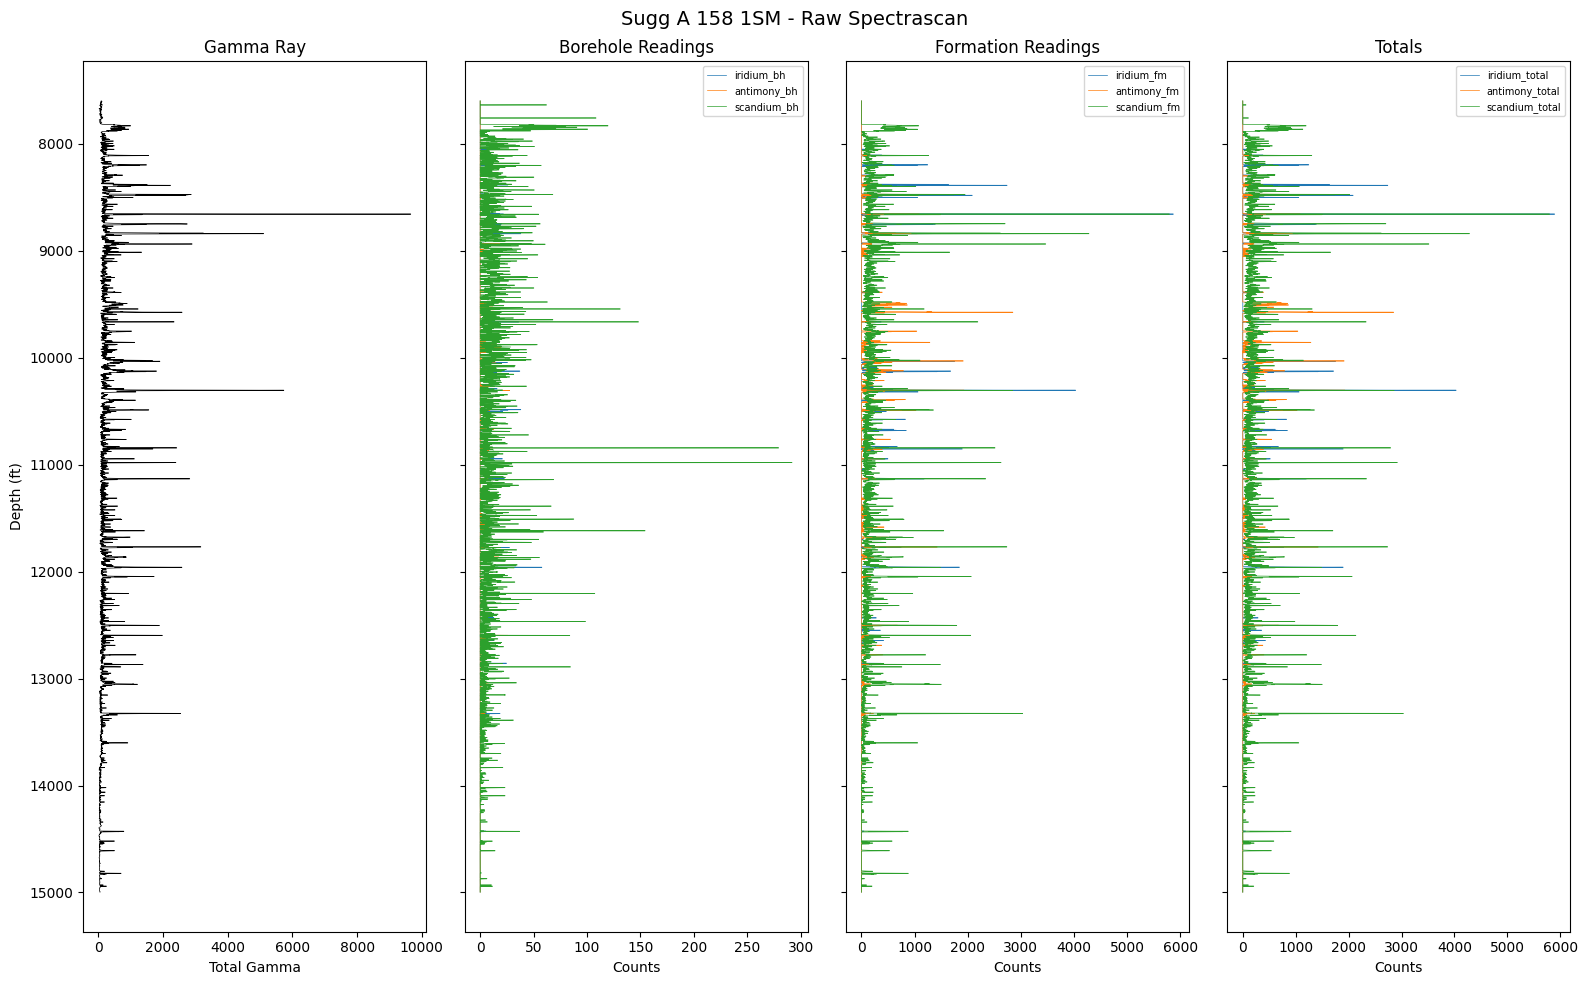

In [ ]:
# Plot raw Spectrascan curves for selected well
fig, axes = plt.subplots(1, 4, figsize=(16, 10), sharey=True)

axes[0].plot(df_raw['total_gamma'], df_raw.index, 'k', lw=0.5)
axes[0].set_xlabel('Total Gamma')
axes[0].set_ylabel('Depth (ft)')
axes[0].invert_yaxis()
axes[0].set_title('Gamma Ray')

for col in ['iridium_bh', 'antimony_bh', 'scandium_bh']:
    axes[1].plot(df_raw[col], df_raw.index, lw=0.5, label=col)
axes[1].set_xlabel('Counts')
axes[1].set_title('Borehole Readings')
axes[1].legend(fontsize=7)

for col in ['iridium_fm', 'antimony_fm', 'scandium_fm']:
    axes[2].plot(df_raw[col], df_raw.index, lw=0.5, label=col)
axes[2].set_xlabel('Counts')
axes[2].set_title('Formation Readings')
axes[2].legend(fontsize=7)

for col in ['iridium_total', 'antimony_total', 'scandium_total']:
    axes[3].plot(df_raw[col], df_raw.index, lw=0.5, label=col)
axes[3].set_xlabel('Counts')
axes[3].set_title('Totals')
axes[3].legend(fontsize=7)

fig.suptitle(f'{well_name} - Raw Spectrascan', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Signal Selector — synthetic catalogs OR borehole data
# ============================================================
# Set SIGNAL_NAME to any label from mono/multi catalogs, or to
# "borehole:<column_name>" to use a borehole curve from df_raw.
#
# INTEGRATE_BOREHOLE: if True, treat borehole signal as a measure
#   density and integrate (cumsum), then normalize so mean = 1.
#   This keeps all values positive (just rescales).

SIGNAL_NAME = "borehole:total_gamma"  # <-- change this
INTEGRATE_BOREHOLE = True  # cumsum + normalize for borehole data

# --- Lookup signal and theory ---
analysis_signal = None
analysis_label = SIGNAL_NAME
analysis_color = 'k'
is_measure = False
has_theory = False
theory_q = theory_tau = theory_h = theory_D = None

_found = False

# --- Check for borehole signal ---
if SIGNAL_NAME.startswith("borehole:"):
    col_name = SIGNAL_NAME.split(":", 1)[1].strip()
    if col_name not in df_raw.columns:
        avail = list(df_raw.columns)
        raise ValueError(f"Column '{col_name}' not in df_raw. Available: {avail}")

    raw_sig = df_raw[col_name].dropna().values.astype(float)

    if INTEGRATE_BOREHOLE:
        # Treat as measure density: integrate then normalize so mean = 1
        integrated = np.cumsum(raw_sig)
        analysis_signal = integrated / np.mean(integrated)
        is_measure = True
        analysis_label = f"{well_name}: {col_name} (integrated, normalized)"
    else:
        analysis_signal = raw_sig
        is_measure = False
        analysis_label = f"{well_name}: {col_name}"

    SIZE = len(analysis_signal)
    analysis_color = 'teal'
    has_theory = False
    _found = True

# --- Search multi catalog ---
if not _found:
    for _i, (_label, _fam, _sig) in enumerate(multi_signals):
        if _label == SIGNAL_NAME:
            _cmap = family_colors_sig[_fam]
            _n = family_counts_sig[_fam]
            _idx_before = sum(1 for _l2, _f2, _ in multi_signals[:_i] if _f2 == _fam)
            analysis_color = _cmap(0.3 + 0.6 * _idx_before / max(_n - 1, 1))

            if _fam == 'feigenbaum':
                is_measure = False
                analysis_signal = _sig
            else:
                is_measure = True
                analysis_signal = np.cumsum(_sig)
            SIZE = len(_sig)

            for _tl, _tf, _tq, _ttau, _th, _tD in multi_catalog:
                if _tl == SIGNAL_NAME:
                    has_theory = True
                    theory_q = _tq
                    theory_tau = _ttau
                    theory_h = _th
                    theory_D = _tD
                    break
            _found = True
            break

# --- Search mono catalog ---
if not _found:
    for _i, (_label, _stype, _sig) in enumerate(mono_signals):
        if _label == SIGNAL_NAME:
            _cmap = system_colors_mono[_stype]
            _n = system_counts_mono[_stype]
            _idx_before = sum(1 for _l2, _s2, _ in mono_signals[:_i] if _s2 == _stype)
            analysis_color = _cmap(0.4 + 0.5 * _idx_before / max(_n - 1, 1))

            is_measure = False
            analysis_signal = _sig
            SIZE = len(_sig)

            for _tl, _ts, _tq, _ttau, _h_star, _marker in mono_catalog:
                if _tl == SIGNAL_NAME:
                    has_theory = True
                    theory_q = _tq
                    theory_tau = _ttau
                    theory_h = np.array([_h_star])
                    theory_D = np.array([-np.interp(0.0, _tq, _ttau)])  # D_f = -tau(0)
                    break
            _found = True
            break

if analysis_signal is None:
    raise ValueError(f"Signal '{SIGNAL_NAME}' not found.\n"
                     f"Mono: {[l for l,_,_ in mono_signals]}\n"
                     f"Multi: {[l for l,_,_ in multi_signals]}\n"
                     f"Borehole: use 'borehole:<column>' with columns: {list(df_raw.columns)}")

# Summary
print(f'Selected: "{analysis_label}"')
print(f'  Signal length: {SIZE}')
print(f'  Is measure (cumsum applied): {is_measure}')
print(f'  Has theoretical spectrum: {has_theory}')
print(f'  Signal range: [{analysis_signal.min():.4f}, {analysis_signal.max():.4f}]')
print(f'  Signal mean: {analysis_signal.mean():.4f}')
if has_theory and theory_h is not None:
    if len(theory_h) == 1:
        print(f'  Monofractal: h* = {theory_h[0]:.4f}')
    else:
        mask = theory_D > 0
        if mask.any():
            print(f'  h range: [{theory_h[mask].min():.4f}, {theory_h[mask].max():.4f}]')


Selected: "Sugg A 158 1SM: total_gamma (integrated, normalized)"
  Signal length: 29589
  Is measure (cumsum applied): True
  Has theoretical spectrum: False
  Signal range: [0.0000, 1.6351]
  Signal mean: 1.0000


In [ ]:
# Cell 13: CWT on selected signal

fig, ax = plt.subplots(figsize=(12, 3))
for spine in ax.spines.values(): spine.set_linewidth(0.5)
t_axis = np.arange(SIZE) / SIZE
ax.plot(t_axis, analysis_signal, color=analysis_color, linewidth=0.6)
ax.set_title(f'{analysis_label}{" (integrated measure)" if is_measure else ""}')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

print(f'Signal size: {SIZE}')
print(f'Signal range: [{analysis_signal.min():.4f}, {analysis_signal.max():.4f}]')

# CWT parameters — change these to experiment
A_MIN = 1.0
N_OCT = 5
N_VOICE = 10
WAVELET = 'g2'
EXPO = -1.0

# Display mode: 'lglobal' (per-scale normalized |W|), 'log2abs' (log2|W|), 'global', 'signedglobal'
SCALOGRAM_MODE = 'lglobal'

# CWT + visualization
t0 = time.time()
coeffs, scales, valid_ranges = cwtd_mlx(analysis_signal, a_min=A_MIN, n_oct=N_OCT, n_voice=N_VOICE,
                                     wavelet_name=WAVELET, expo=EXPO)
t1 = time.time()
print(f'CWT computed in {t1-t0:.3f}s  (a_min={A_MIN}, n_oct={N_OCT}, n_voice={N_VOICE})')
print(f'Coefficients shape: {coeffs.shape}, Scales: {len(scales)} ({scales[0]:.2f} to {scales[-1]:.2f})')
print(f'Valid range at finest scale: {valid_ranges[0]}, coarsest: {valid_ranges[-1]}')

# Plot scalogram
fig, ax = plt.subplots(figsize=(14, 6))
for spine in ax.spines.values(): spine.set_linewidth(0.5)
im = scalogram_lastwave(coeffs, scales=scales, ax=ax,
                        norm_mode=SCALOGRAM_MODE)

if SCALOGRAM_MODE == 'log2abs' and hasattr(im, '_log2_vlim'):
    vmin_l, vmax_l = im._log2_vlim
    cbar = plt.colorbar(im, ax=ax, label='log\u2082|W|')
    tick_vals = np.linspace(0, 1, 6)
    cbar.set_ticks(tick_vals)
    cbar.set_ticklabels([f'{vmin_l + t*(vmax_l-vmin_l):.1f}' for t in tick_vals])
else:
    label_map = {'lglobal': '|W| (per-scale normalized)', 'global': '|W|',
                 'signedglobal': 'W (signed)'}
    plt.colorbar(im, ax=ax, label=label_map.get(SCALOGRAM_MODE, ''))

ax.set_title(f'CWT ({WAVELET}, {SCALOGRAM_MODE}) \u2014 {analysis_label}')
plt.tight_layout()
plt.show()


Numba warmup: 0.000s
Total extrema: 71249
Extrema computed in 0.018s
  Scale 0 (a=1.00): 3686 extrema
  Scale 22 (a=4.59): 1185 extrema
  Scale 45 (a=22.63): 239 extrema
  Scale 67 (a=103.97): 54 extrema
  Scale 89 (a=477.71): 9 extrema
Chaining: 0.002s
Delete: 0.078s, deleted 85 chains
ChainMax: 0.004s
Total chaining: 0.084s
Remaining extrema: 71141
Pre-deletion chains: 3561
Surviving chains: 3561
Deleted chains: 0


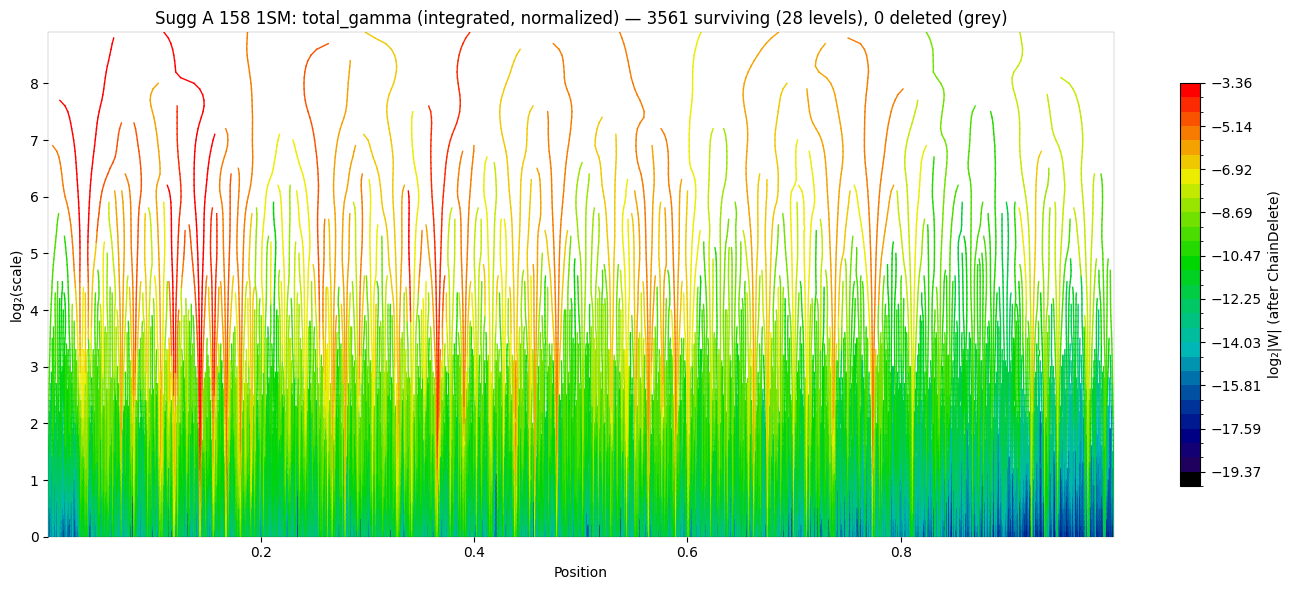

In [ ]:
# Cell 15: Extrema detection — now imported from wtmm package
from wtmm.extrema import compute_extlis_numba, compute_extrep

# Compute extrema representation
dx_signal = 1.0 / SIZE
t0 = time.time()
# Warm up Numba
_ = compute_extlis_numba(coeffs[0], dx_signal, 0.0, 1e-6,
                          valid_ranges[0][0], valid_ranges[0][1])
t_warmup = time.time()
print(f'Numba warmup: {t_warmup - t0:.3f}s')

extrep_abs, extrep_ord, extrep_idx = compute_extrep(
    coeffs, scales, n_oct=N_OCT, n_voice=N_VOICE, a_min=A_MIN,
    valid_ranges=valid_ranges, dx=dx_signal, x0=0.0, epsilon=1e-6)
t1 = time.time()
print(f'Extrema computed in {t1-t_warmup:.3f}s')
n_total_scales = N_OCT * N_VOICE
for sidx in [0, n_total_scales//4, n_total_scales//2, 3*n_total_scales//4, n_total_scales-1]:
    print(f'  Scale {sidx} (a={scales[sidx]:.2f}): {len(extrep_abs[sidx])} extrema')

# Cell 16: Chaining — now imported from wtmm package
from wtmm.chains import chain_all, chain_delete_all, chain_max_wrapper, trace_chains, save_chain_state

# Run full chaining pipeline
t0 = time.time()
coarser_links, finer_links = chain_all(extrep_abs, extrep_ord, n_oct=N_OCT, n_voice=N_VOICE)
t_chain = time.time()
print(f'Chaining: {t_chain - t0:.3f}s')

# Save pre-deletion state for visualization
pre_del_abs, pre_del_ord, pre_del_cl = save_chain_state(extrep_abs, extrep_ord, coarser_links)
pre_del_chains = trace_chains(pre_del_abs, pre_del_ord, pre_del_cl, scales, N_OCT * N_VOICE)

nb_del = chain_delete_all(extrep_abs, extrep_ord, extrep_idx,
                           coarser_links, finer_links, n_oct=N_OCT, n_voice=N_VOICE)
t_delete = time.time()
print(f'Delete: {t_delete - t_chain:.3f}s, deleted {nb_del} chains')

# ChainMax with expo=1
chain_max_wrapper(extrep_ord, coarser_links, n_oct=N_OCT, n_voice=N_VOICE, a_min=A_MIN, expo=EXPO)
t1 = time.time()
print(f'ChainMax: {t1 - t_delete:.3f}s')
print(f'Total chaining: {t1 - t0:.3f}s')

remaining = sum(len(a) for a in extrep_abs)
print(f'Remaining extrema: {remaining}')

# Cell 17: Extrema representation and maxima lines visualization

# Surviving chains (after deletion)
post_del_chains = trace_chains(extrep_abs, extrep_ord, coarser_links, scales, N_OCT * N_VOICE)

# Find which pre-deletion chains were deleted (not present in post-deletion)
# Build set of surviving chain start positions for fast lookup
surviving_starts = set()
for pos, sv, sign, vals in post_del_chains:
    surviving_starts.add((pos[0], sign))

deleted_chains = []
for pos, sv, sign, vals in pre_del_chains:
    if (pos[0], sign) not in surviving_starts:
        deleted_chains.append((pos, sv, sign, vals))

print(f'Pre-deletion chains: {len(pre_del_chains)}')
print(f'Surviving chains: {len(post_del_chains)}')
print(f'Deleted chains: {len(deleted_chains)}')

# Plot maxima lines: surviving colored by log2|ordinate|, deleted greyed out
import matplotlib as mpl

N_COLORS = 28
fig, ax = plt.subplots(figsize=(14, 6))
for spine in ax.spines.values(): spine.set_linewidth(0.1)

# Draw deleted chains first (background, grey)
for pos, sv, sign, vals in deleted_chains:
    ax.plot(pos, sv, '-', color='lightgrey', alpha=0.4, linewidth=0.5)

# Collect all log2|ordinate| values for colormap normalization
all_log2_vals = np.concatenate([np.log2(np.abs(np.array(vals)) + 1e-300) for _, _, _, vals in post_del_chains])
vmin, vmax = np.percentile(all_log2_vals, [0, 100])
boundaries = np.linspace(vmin, vmax, N_COLORS + 1)
norm = mpl.colors.BoundaryNorm(boundaries, N_COLORS)
cmap = lastwave_colormap(N_COLORS)

# Draw surviving chains colored by log2|ordinate| at each segment
for pos, sv, sign, vals in post_del_chains:
    log2_v = np.log2(np.abs(np.array(vals)) + 1e-300)
    for j in range(len(pos) - 1):
        ax.plot(pos[j:j+2], sv[j:j+2], '-', color=cmap(norm(log2_v[j])), lw=1)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, ax=ax, label='log\u2082|W| (after ChainDelete)', shrink=0.8)

ax.set_xlabel('Position')
ax.set_ylabel('log\u2082(scale)')
ax.set_title(f'{analysis_label} \u2014 {len(post_del_chains)} surviving ({N_COLORS} levels), {len(deleted_chains)} deleted (grey)')
ax.margins(0)
plt.tight_layout()
plt.show()


In [ ]:
# Cell 17b: Cone-of-influence chain filtering
# Remove chains whose finest-scale position falls within the COI
# of the coarsest scale (boundary region where edge effects dominate).

REMOVE_COI_CHAINS = False  # <-- toggle this

if REMOVE_COI_CHAINS:
    # COI boundary from the coarsest scale's valid range
    coarsest_scale_idx = len(scales) - 1
    coi_left_idx, coi_right_idx = valid_ranges[coarsest_scale_idx]
    coi_left_pos = coi_left_idx * dx_signal   # convert index to position
    coi_right_pos = coi_right_idx * dx_signal

    # Find which finest-scale extrema are in the COI
    # (position < coi_left_pos or position > coi_right_pos)
    n_finest = len(extrep_abs[0])
    coi_mask = np.zeros(n_finest, dtype=bool)  # True = in COI, remove
    for fi in range(n_finest):
        pos = extrep_abs[0][fi]
        if pos < coi_left_pos or pos > coi_right_pos:
            coi_mask[fi] = True

    # Walk each COI chain from finest to coarsest, collecting (scale, index) to remove
    remove_set = []  # list of sets, one per scale
    for s in range(len(extrep_abs)):
        remove_set.append(set())

    for fi in range(n_finest):
        if not coi_mask[fi]:
            continue
        cs, ci = 0, fi
        while cs < len(extrep_abs) and ci != -1:
            remove_set[cs].add(ci)
            ci = coarser_links[cs][ci]
            cs += 1

    # Rebuild extrep arrays, removing marked extrema
    # Build index mapping (old -> new) per scale for link fixup
    n_removed_total = 0
    old_to_new = []  # per scale
    for s in range(len(extrep_abs)):
        n_old = len(extrep_abs[s])
        to_remove = remove_set[s]
        n_removed_total += len(to_remove)

        if len(to_remove) == 0:
            old_to_new.append({i: i for i in range(n_old)})
            continue

        keep_mask = np.array([i not in to_remove for i in range(n_old)])
        mapping = {}
        new_idx = 0
        for old_idx in range(n_old):
            if keep_mask[old_idx]:
                mapping[old_idx] = new_idx
                new_idx += 1
            else:
                mapping[old_idx] = -1
        old_to_new.append(mapping)

        extrep_abs[s] = extrep_abs[s][keep_mask]
        extrep_ord[s] = extrep_ord[s][keep_mask]
        extrep_idx[s] = extrep_idx[s][keep_mask]

    # Fix up coarser_links and finer_links with new indices
    for s in range(len(coarser_links)):
        n_cur = len(extrep_abs[s])
        new_cl = np.full(n_cur, -1, dtype=int)
        new_fl = np.full(n_cur, -1, dtype=int)

        old_cl = coarser_links[s]
        old_fl = finer_links[s]
        mapping_cur = old_to_new[s]
        mapping_coarser = old_to_new[s + 1] if s + 1 < len(old_to_new) else {}
        mapping_finer = old_to_new[s - 1] if s > 0 else {}

        for old_idx, new_idx in mapping_cur.items():
            if new_idx == -1:
                continue
            # Coarser link
            if old_idx < len(old_cl):
                old_target = old_cl[old_idx]
                if old_target != -1 and old_target in mapping_coarser:
                    new_cl[new_idx] = mapping_coarser[old_target]
                else:
                    new_cl[new_idx] = -1
            # Finer link
            if old_idx < len(old_fl):
                old_target = old_fl[old_idx]
                if old_target != -1 and old_target in mapping_finer:
                    new_fl[new_idx] = mapping_finer[old_target]
                else:
                    new_fl[new_idx] = -1

        coarser_links[s] = new_cl
        finer_links[s] = new_fl

    n_coi_chains = int(coi_mask.sum())
    n_remaining = sum(len(a) for a in extrep_abs)
    print(f'COI filtering: removed {n_coi_chains} chains ({n_removed_total} extrema across all scales)')
    print(f'  COI boundary (coarsest scale): position [{coi_left_pos:.4f}, {coi_right_pos:.4f}]')
    print(f'  COI boundary (indices): [{coi_left_idx}, {coi_right_idx}] of {SIZE}')
    print(f'  Remaining extrema: {n_remaining}')

    # Re-trace surviving chains for visualization
    post_coi_chains = trace_chains(extrep_abs, extrep_ord, coarser_links, scales, N_OCT * N_VOICE)
    print(f'  Surviving chains after COI filter: {len(post_coi_chains)}')

    # Visualization: show COI boundaries on maxima lines
    import matplotlib as mpl
    N_COLORS = 14
    fig, ax = plt.subplots(figsize=(14, 6))
    for spine in ax.spines.values(): spine.set_linewidth(0.5)

    # COI shading
    ax.axvspan(0, coi_left_pos, color='red', alpha=0.08, label='COI (removed)')
    ax.axvspan(coi_right_pos, 1.0, color='red', alpha=0.08)

    # Surviving chains colored by log2|ordinate|
    if len(post_coi_chains) > 0:
        all_log2_vals = np.concatenate([np.log2(np.abs(np.array(vals)) + 1e-300)
                                        for _, _, _, vals in post_coi_chains])
        vmin, vmax = np.percentile(all_log2_vals, [0, 100])
        boundaries = np.linspace(vmin, vmax, N_COLORS + 1)
        norm_c = mpl.colors.BoundaryNorm(boundaries, N_COLORS)
        cmap_c = lastwave_colormap(N_COLORS)
        for pos, sv, sign, vals in post_coi_chains:
            log2_v = np.log2(np.abs(np.array(vals)) + 1e-300)
            for j in range(len(pos) - 1):
                ax.plot(pos[j:j+2], sv[j:j+2], '-', color=cmap_c(norm_c(log2_v[j])), lw=1)

    ax.set_xlabel('Position')
    ax.set_ylabel('log₂(scale)')
    ax.set_title(f'{analysis_label} — {len(post_coi_chains)} chains after COI filter '
                 f'({n_coi_chains} removed)')
    ax.legend(fontsize=8, loc='upper right')
    ax.margins(0)
    plt.tight_layout()
    plt.show()
else:
    print('COI filtering: disabled (REMOVE_COI_CHAINS = False)')


COI filtering: disabled (REMOVE_COI_CHAINS = False)


Best internal R²:
  Range: log2(a) = [5.30, 7.10]  (1.8 octaves)
  Mean R² = 0.995240

Current setting: LOG2_A_MIN=0.0, LOG2_A_MAX=9


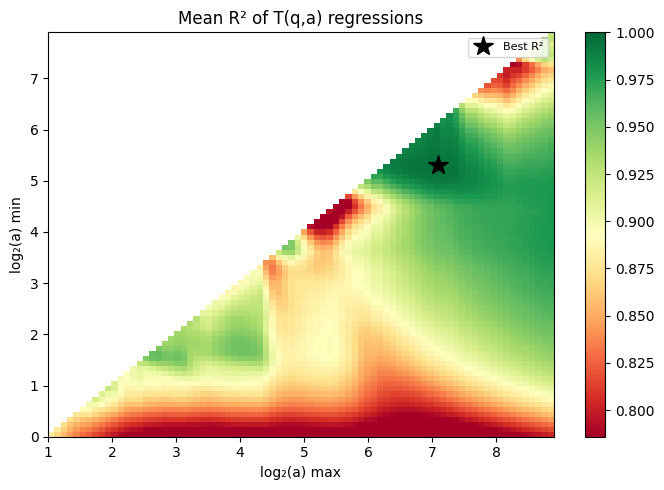

In [ ]:
# Cell 20: Optimal regression range search
# Grid search over (log2_a_min, log2_a_max) to find the range that:
#   1. Best internal R² — how linear are T(q,a) vs log2(a) within the range
#   2. Best theory fit — how close are the resulting tau(q) to analytical values
#   3. Best D(h) spectrum — per-q D(h) match and spectrum width agreement

LOG2_A_MIN = 0.0
LOG2_A_MAX = 9

from wtmm.partition import pf_get_T, pf_get_H, pf_get_D
from wtmm.spectra import compute_spectra

log2_a = pf['log2_a']
n_voice = pf['n_voice']
log2_a0 = np.log2(pf['a_min'])
dx = 1.0 / n_voice
max_idx = pf['index_max']

# Build grid: all (min, max) pairs with at least 1 octave separation
min_octave_span = 1.0
grid_step = dx  # step in log2(a) units

lo_vals = np.arange(log2_a0, log2_a0 + dx * max_idx - min_octave_span + dx/2, grid_step)
hi_vals = np.arange(log2_a0 + min_octave_span, log2_a0 + dx * max_idx + dx/2, grid_step)

q_array = pf['q_list']
n_q = len(q_array)

# Precompute T(q,a), H(q,a), D(q,a) for all q
T_all = np.zeros((n_q, max_idx + 1))
H_all = np.zeros((n_q, max_idx + 1))
D_all = np.zeros((n_q, max_idx + 1))
for qi in range(n_q):
    T_all[qi] = pf_get_T(pf, qi, 'extensive')[:max_idx + 1]
    H_all[qi] = pf_get_H(pf, qi, 'extensive')[:max_idx + 1]
    D_all[qi] = pf_get_D(pf, qi, q_array[qi], 'extensive')[:max_idx + 1]

# Theory values at the partition function q values (if available)
is_multifractal_theory = has_theory and theory_h is not None and len(theory_h) > 1
if has_theory:
    tau_theory_at_q = np.interp(q_array, theory_q, theory_tau)
if is_multifractal_theory:
    h_theory_at_q = np.interp(q_array, theory_q, theory_h)
    D_theory_at_q = np.interp(q_array, theory_q, theory_D)
    # Theory spectrum width: range of h where D > 0
    _tmask = theory_D > 0
    theory_width = theory_h[_tmask].max() - theory_h[_tmask].min() if _tmask.any() else 0.0

results = []  # (lo, hi, mean_r2, tau_rmse, dh_score)

for lo in lo_vals:
    idx_lo = int(round((lo - log2_a0) / dx))
    idx_lo = max(idx_lo, 0)
    for hi in hi_vals:
        if hi - lo < min_octave_span - 1e-9:
            continue
        idx_hi = int(round((hi - log2_a0) / dx))
        idx_hi = min(idx_hi, max_idx)
        if idx_hi - idx_lo < 2:
            continue

        vidx = np.arange(idx_lo, idx_hi + 1)
        x = log2_a0 + dx * vidx

        # Compute R² and slopes for T, H, D
        r2_list = []
        tau_fit = np.full(n_q, np.nan)
        h_fit = np.full(n_q, np.nan)
        d_fit = np.full(n_q, np.nan)
        for qi in range(n_q):
            y_T = T_all[qi, vidx]
            y_H = H_all[qi, vidx]
            y_D = D_all[qi, vidx]
            if not np.all(np.isfinite(y_T)):
                continue
            slope_T, intercept_T = np.polyfit(x, y_T, 1)
            tau_fit[qi] = slope_T
            y_pred = slope_T * x + intercept_T
            ss_res = np.sum((y_T - y_pred)**2)
            ss_tot = np.sum((y_T - np.mean(y_T))**2)
            r2 = 1.0 - ss_res / ss_tot if ss_tot > 1e-30 else 1.0
            r2_list.append(r2)
            if np.all(np.isfinite(y_H)):
                h_fit[qi] = np.polyfit(x, y_H, 1)[0]
            if np.all(np.isfinite(y_D)):
                d_fit[qi] = np.polyfit(x, y_D, 1)[0]

        if len(r2_list) == 0:
            continue
        mean_r2 = np.mean(r2_list)

        # Theory tau RMSE
        if has_theory:
            vm = np.isfinite(tau_fit)
            tau_rmse = np.sqrt(np.mean((tau_fit[vm] - tau_theory_at_q[vm])**2)) if vm.any() else np.inf
        else:
            tau_rmse = np.nan

        # D(h) spectrum score: per-q comparison of (h(q), D(q)) pairs
        if is_multifractal_theory:
            vm = np.isfinite(h_fit) & np.isfinite(d_fit)
            if vm.sum() >= 3:
                # Per-q h(q) RMSE
                h_rmse = np.sqrt(np.mean((h_fit[vm] - h_theory_at_q[vm])**2))
                # Per-q D(q) RMSE
                d_rmse = np.sqrt(np.mean((d_fit[vm] - D_theory_at_q[vm])**2))
                # Spectrum width comparison
                wtmm_width = h_fit[vm].max() - h_fit[vm].min()
                width_error = abs(wtmm_width - theory_width) / max(theory_width, 1e-10)
                # Combined score: geometric mean of normalized errors
                dh_score = np.sqrt(h_rmse**2 + d_rmse**2 + (width_error * 0.5)**2)
            else:
                dh_score = np.inf
        else:
            dh_score = np.nan

        results.append((lo, hi, mean_r2, tau_rmse, dh_score))

results = np.array(results)

# --- Find best ranges ---
# 1. Best R²
best_r2_idx = np.argmax(results[:, 2])
best_r2 = results[best_r2_idx]
print(f'Best internal R²:')
print(f'  Range: log2(a) = [{best_r2[0]:.2f}, {best_r2[1]:.2f}]  '
      f'({best_r2[1]-best_r2[0]:.1f} octaves)')
print(f'  Mean R² = {best_r2[2]:.6f}')

if has_theory:
    # 2. Best theory tau fit
    best_thy_idx = np.argmin(results[:, 3])
    best_thy = results[best_thy_idx]
    print(f'\nBest tau(q) theory fit:')
    print(f'  Range: log2(a) = [{best_thy[0]:.2f}, {best_thy[1]:.2f}]  '
          f'({best_thy[1]-best_thy[0]:.1f} octaves)')
    print(f'  tau(q) RMSE = {best_thy[3]:.6f}, R² = {best_thy[2]:.6f}')

    # 3. Combined: best theory fit among ranges with R² > 0.99
    good_r2_mask = results[:, 2] > 0.99
    if good_r2_mask.any():
        good_results = results[good_r2_mask]
        best_combo_idx = np.argmin(good_results[:, 3])
        best_combo = good_results[best_combo_idx]
        print(f'\nBest combined (R²>0.99, then min tau RMSE):')
        print(f'  Range: log2(a) = [{best_combo[0]:.2f}, {best_combo[1]:.2f}]  '
              f'({best_combo[1]-best_combo[0]:.1f} octaves)')
        print(f'  tau(q) RMSE = {best_combo[3]:.6f}, R² = {best_combo[2]:.6f}')

if is_multifractal_theory:
    # 4. Best D(h) spectrum match
    best_dh_idx = np.argmin(results[:, 4])
    best_dh = results[best_dh_idx]
    print(f'\nBest D(h) spectrum fit:')
    print(f'  Range: log2(a) = [{best_dh[0]:.2f}, {best_dh[1]:.2f}]  '
          f'({best_dh[1]-best_dh[0]:.1f} octaves)')
    print(f'  D(h) score = {best_dh[4]:.6f} (lower=better)')
    print(f'  R² = {best_dh[2]:.6f}, tau RMSE = {best_dh[3]:.6f}')

    # Best D(h) among good R² ranges
    if good_r2_mask.any():
        best_dh_combo_idx = np.argmin(good_results[:, 4])
        best_dh_combo = good_results[best_dh_combo_idx]
        print(f'\nBest D(h) (R²>0.99):')
        print(f'  Range: log2(a) = [{best_dh_combo[0]:.2f}, {best_dh_combo[1]:.2f}]  '
              f'({best_dh_combo[1]-best_dh_combo[0]:.1f} octaves)')
        print(f'  D(h) score = {best_dh_combo[4]:.6f}, R² = {best_dh_combo[2]:.6f}')

print(f'\nCurrent setting: LOG2_A_MIN={LOG2_A_MIN}, LOG2_A_MAX={LOG2_A_MAX}')

# --- Visualization ---
n_panels = 1 + (1 if has_theory else 0) + (1 if is_multifractal_theory else 0)
fig, axes = plt.subplots(1, n_panels, figsize=(7 * n_panels, 5))
if n_panels == 1:
    axes = [axes]

# Reshape for heatmaps
lo_unique = np.sort(np.unique(results[:, 0]))
hi_unique = np.sort(np.unique(results[:, 1]))
lo_to_i = {v: i for i, v in enumerate(lo_unique)}
hi_to_j = {v: j for j, v in enumerate(hi_unique)}

r2_grid = np.full((len(lo_unique), len(hi_unique)), np.nan)
rmse_grid = np.full((len(lo_unique), len(hi_unique)), np.nan)
dh_grid = np.full((len(lo_unique), len(hi_unique)), np.nan)
for row in results:
    lo, hi, r2, rmse, dh = row
    i, j = lo_to_i[lo], hi_to_j[hi]
    r2_grid[i, j] = r2
    rmse_grid[i, j] = rmse
    dh_grid[i, j] = dh

extent = [hi_unique[0], hi_unique[-1], lo_unique[0], lo_unique[-1]]
panel = 0

# Panel 1: R² heatmap
ax = axes[panel]
im = ax.imshow(r2_grid, aspect='auto', origin='lower', extent=extent,
               cmap='RdYlGn', vmin=np.nanpercentile(r2_grid, 5), vmax=1.0)
ax.plot(best_r2[1], best_r2[0], 'k*', markersize=15, label='Best R²')
ax.set_xlabel('log₂(a) max'); ax.set_ylabel('log₂(a) min')
ax.set_title('Mean R² of T(q,a) regressions')
ax.legend(fontsize=8)
plt.colorbar(im, ax=ax)
panel += 1

# Panel 2: tau(q) RMSE
if has_theory:
    ax = axes[panel]
    vmax_rmse = np.nanpercentile(rmse_grid, 90)
    im2 = ax.imshow(rmse_grid, aspect='auto', origin='lower', extent=extent,
                    cmap='RdYlGn_r', vmin=0, vmax=vmax_rmse)
    ax.plot(best_thy[1], best_thy[0], 'k*', markersize=15, label='Best τ(q)')
    if good_r2_mask.any():
        ax.plot(best_combo[1], best_combo[0], 'b^', markersize=12, label='Best combo')
    ax.set_xlabel('log₂(a) max'); ax.set_ylabel('log₂(a) min')
    ax.set_title('τ(q) RMSE vs theory')
    ax.legend(fontsize=8)
    plt.colorbar(im2, ax=ax)
    panel += 1

# Panel 3: D(h) spectrum score
if is_multifractal_theory:
    ax = axes[panel]
    vmax_dh = np.nanpercentile(dh_grid, 90)
    im3 = ax.imshow(dh_grid, aspect='auto', origin='lower', extent=extent,
                    cmap='RdYlGn_r', vmin=0, vmax=vmax_dh)
    ax.plot(best_dh[1], best_dh[0], 'k*', markersize=15, label='Best D(h)')
    if good_r2_mask.any():
        ax.plot(best_dh_combo[1], best_dh_combo[0], 'b^', markersize=12, label='Best D(h) R²>0.99')
    ax.set_xlabel('log₂(a) max'); ax.set_ylabel('log₂(a) min')
    ax.set_title('D(h) spectrum score\n(per-q h & D RMSE + width)')
    ax.legend(fontsize=8)
    plt.colorbar(im3, ax=ax)

plt.tight_layout()
plt.show()

In [ ]:
# Cell 18: Partition function — now imported from wtmm package
from wtmm.partition import compute_partition_function, pf_get_T, pf_get_H, pf_get_D
from wtmm.spectra import plot_partition_functions

LOG2_A_MIN = .6
LOG2_A_MAX = 3.8
NORMALIZE_PF = False  # Toggle: shift curves to zero at midpoint for theory comparison

# Compute partition function
q_list = [-7, -6, -5, -3, -2, -1, 0, 0.5, 1, 2, 3, 5]

t0 = time.time()
pf = compute_partition_function(extrep_ord, n_oct=N_OCT, n_voice=N_VOICE, a_min=A_MIN, q_list=q_list)
t1 = time.time()
print(f'Partition function computed in {t1-t0:.3f}s, up to scale index {pf["index_max"]}')
print(f'Extrema per scale (sample): {pf["n_ext"][:5]}...{pf["n_ext"][-5:]}')

# Plot T(q,a), H(q,a), D(q,a) with optional theory overlay
fig, axes = plot_partition_functions(
    pf, LOG2_A_MIN, LOG2_A_MAX,
    theory_q=theory_q, theory_tau=theory_tau,
    theory_h=theory_h, theory_D=theory_D,
    normalize=NORMALIZE_PF,
)
plt.show()
print(f'Gray dashed lines show regression range [log2(a)={LOG2_A_MIN} to {LOG2_A_MAX}]')
if NORMALIZE_PF:
    print(f'Curves normalized to zero at log2(a) = {0.5*(LOG2_A_MIN+LOG2_A_MAX):.2f}')
    print(f'Dashed lines = theoretical slopes (no intercept fitting needed)')


In [ ]:
# Cell 19: tau(q), h(q), D(h) spectrum — now imported from wtmm package
from wtmm.spectra import compute_spectra, plot_spectra, print_spectra_comparison

# Compute spectra
spectra = compute_spectra(pf, log2_a_min=LOG2_A_MIN, log2_a_max=LOG2_A_MAX)

# --- Toggle error bars ---
SHOW_ERRORS = True

# --- Plot ---
fig, axes = plot_spectra(
    spectra, label=analysis_label,
    theory_q=theory_q, theory_tau=theory_tau,
    theory_h=theory_h, theory_D=theory_D,
    show_errors=SHOW_ERRORS,
)
plt.show()

# --- Print comparison ---
print_spectra_comparison(
    spectra, label=analysis_label,
    theory_q=theory_q, theory_tau=theory_tau,
    theory_h=theory_h, theory_D=theory_D,
)


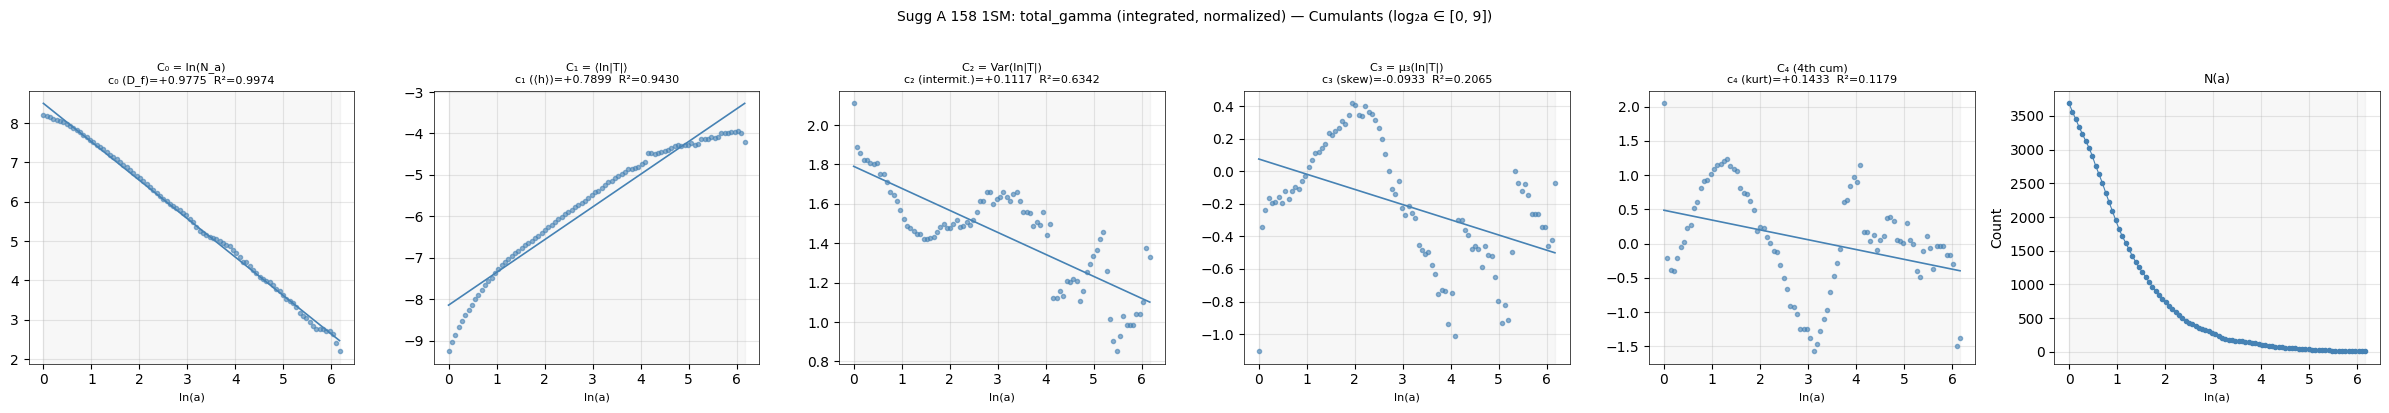

=== Cumulant coefficients ===
                c₀ (D_f) = +0.9775 ± 0.0054   R² = 0.997366
                c₁ (⟨h⟩) = +0.7899 ± 0.0207   R² = 0.942991
          c₂ (intermit.) = +0.1117 ± 0.0090   R² = 0.634247
               c₃ (skew) = -0.0933 ± 0.0195   R² = 0.206454
               c₄ (kurt) = +0.1433 ± 0.0418   R² = 0.117879


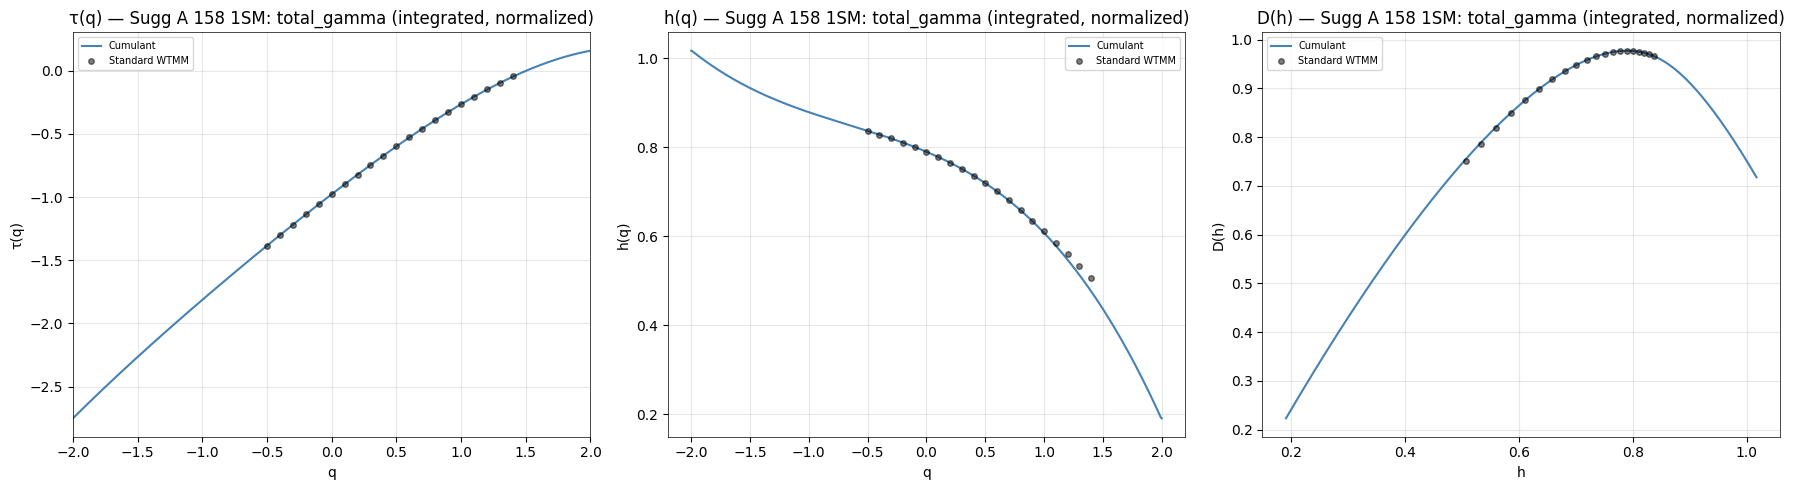


c₃ = -0.0933 → departure from log-normality


In [160]:
# Cumulant analysis — non-truncated only
# τ(q) = -c₀ + c₁q - c₂q²/2! + c₃q³/3! + ...
# cₙ = slope of Cₙ(a) vs ln(a)

Q_RANGE_CUMULANT = (-2, 2)  # valid q range for reconstruction

n_scales = len(extrep_ord)
n_voice_cum = pf['n_voice']
ln_a = np.log(scales[:n_scales])

# --- Compute cumulants C_n(a) at each scale ---
cumulant_names = ['C₀ = ln(N_a)', 'C₁ = ⟨ln|T|⟩', 'C₂ = Var(ln|T|)',
                  'C₃ = μ₃(ln|T|)', 'C₄ (4th cum)']
names_short = ['c₀ (D_f)', 'c₁ (⟨h⟩)', 'c₂ (intermit.)', 'c₃ (skew)', 'c₄ (kurt)']
n_cumulants = len(cumulant_names)
sign_conv = [-1, 1, -1, 1, -1]

C = np.full((n_cumulants, n_scales), np.nan)
N_a = np.zeros(n_scales)

for s in range(n_scales):
    ords = extrep_ord[s]
    N_a[s] = len(ords)
    if len(ords) < 3:
        continue
    ln_T = np.log(np.abs(ords) + 1e-300)
    m1 = np.mean(ln_T)
    d = ln_T - m1
    C[0, s] = np.log(len(ords))
    C[1, s] = m1
    C[2, s] = np.mean(d**2)
    C[3, s] = np.mean(d**3)
    C[4, s] = np.mean(d**4) - 3 * np.mean(d**2)**2

# --- Fit slopes over regression range ---
log2_a0 = np.log2(scales[0])
dx_scale = 1.0 / n_voice_cum
idx_lo = max(int(round((LOG2_A_MIN - log2_a0) / dx_scale)), 0)
idx_hi = min(int(round((LOG2_A_MAX - log2_a0) / dx_scale)), n_scales - 1)
fit_idx = np.arange(idx_lo, idx_hi + 1)
x_fit = ln_a[fit_idx]

c_coeffs = np.zeros(n_cumulants)
c_err = np.zeros(n_cumulants)
c_r2 = np.zeros(n_cumulants)

fig, axes = plt.subplots(1, n_cumulants + 1, figsize=(4 * (n_cumulants + 1), 4))
for ax_ in axes:
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

for n in range(n_cumulants):
    ax = axes[n]
    valid = np.isfinite(C[n])
    ax.plot(ln_a[valid], C[n, valid], 'o', color='steelblue', markersize=3, alpha=0.6)
    ax.axvspan(ln_a[idx_lo], ln_a[idx_hi], color='gray', alpha=0.06)

    y_fit = C[n, fit_idx]
    fmask = np.isfinite(y_fit)
    if fmask.sum() >= 3:
        slope, intercept = np.polyfit(x_fit[fmask], y_fit[fmask], 1)
        c_coeffs[n] = sign_conv[n] * slope
        y_pred = slope * x_fit[fmask] + intercept
        ss_res = np.sum((y_fit[fmask] - y_pred)**2)
        ss_tot = np.sum((y_fit[fmask] - y_fit[fmask].mean())**2)
        c_r2[n] = 1.0 - ss_res / ss_tot if ss_tot > 1e-30 else 1.0
        n_pts = fmask.sum()
        c_err[n] = np.sqrt(ss_res / max(n_pts - 2, 1) /
                           np.sum((x_fit[fmask] - x_fit[fmask].mean())**2)) if n_pts > 2 else 0
        x_line = np.array([ln_a[valid].min(), ln_a[valid].max()])
        ax.plot(x_line, slope * x_line + intercept, '-', color='steelblue', lw=1.2)

    ax.set_title(f'{cumulant_names[n]}\n{names_short[n]}={c_coeffs[n]:+.4f}  R²={c_r2[n]:.4f}', fontsize=8)
    ax.set_xlabel('ln(a)', fontsize=8)
    ax.grid(True, alpha=0.3)

# N(a) panel
ax = axes[n_cumulants]
ax.plot(ln_a, N_a, 'o-', color='steelblue', markersize=3, lw=0.8)
ax.axvspan(ln_a[idx_lo], ln_a[idx_hi], color='gray', alpha=0.06)
ax.set_title('N(a)', fontsize=9)
ax.set_xlabel('ln(a)', fontsize=8)
ax.set_ylabel('Count')
ax.grid(True, alpha=0.3)

plt.suptitle(f'{analysis_label} — Cumulants (log₂a ∈ [{LOG2_A_MIN}, {LOG2_A_MAX}])', fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

# --- Print coefficients ---
print(f'=== Cumulant coefficients ===')
for n in range(n_cumulants):
    print(f'  {names_short[n]:>22s} = {c_coeffs[n]:+.4f} ± {c_err[n]:.4f}   R² = {c_r2[n]:.6f}')

# --- Reconstruct τ(q), h(q), D(h) ---
q_recon = np.linspace(Q_RANGE_CUMULANT[0], Q_RANGE_CUMULANT[1], 500)

tau_cum = -c_coeffs[0] + c_coeffs[1]*q_recon - c_coeffs[2]*q_recon**2/2 + c_coeffs[3]*q_recon**3/6 - c_coeffs[4]*q_recon**4/24
h_cum = np.gradient(tau_cum, q_recon)
D_cum = q_recon * h_cum - tau_cum

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax_ in axes:
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

# τ(q)
ax = axes[0]
ax.plot(q_recon, tau_cum, '-', color='steelblue', lw=1.5, label='Cumulant')
if has_theory:
    ax.plot(theory_q, theory_tau, 'k-', lw=1, label='Theory')
ax.plot(spectra['q_list'], spectra['tau_q'], 'ko', markersize=4, alpha=0.5, label='Standard WTMM')
ax.set_xlabel('q'); ax.set_ylabel('τ(q)')
ax.set_title(f'τ(q) — {analysis_label}')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
ax.set_xlim(Q_RANGE_CUMULANT[0], Q_RANGE_CUMULANT[1])

# h(q)
ax = axes[1]
ax.plot(q_recon, h_cum, '-', color='steelblue', lw=1.5, label='Cumulant')
if has_theory and theory_h is not None and len(theory_h) > 1:
    ax.plot(theory_q, theory_h, 'k-', lw=1, label='Theory')
elif has_theory and theory_h is not None and len(theory_h) == 1:
    ax.axhline(theory_h[0], color='k', ls='--', lw=1, label=f'Theory h*={theory_h[0]:.3f}')
ax.plot(spectra['q_list'], spectra['h_q'], 'ko', markersize=4, alpha=0.5, label='Standard WTMM')
ax.set_xlabel('q'); ax.set_ylabel('h(q)')
ax.set_title(f'h(q) — {analysis_label}')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# D(h)
ax = axes[2]
m = D_cum > -0.5
ax.plot(h_cum[m], D_cum[m], '-', color='steelblue', lw=1.5, label='Cumulant')
if has_theory and theory_h is not None and len(theory_h) > 1:
    tm = theory_D > -0.5
    ax.plot(theory_h[tm], theory_D[tm], 'k-', lw=1, label='Theory')
elif has_theory and theory_h is not None and len(theory_h) == 1:
    ax.plot(theory_h[0], theory_D[0], 'k*', markersize=15, label=f'Theory (h*={theory_h[0]:.3f})')
ax.plot(spectra['h_q'], spectra['D_q'], 'ko', markersize=4, alpha=0.5, linestyle='none', label='Standard WTMM')
ax.set_xlabel('h'); ax.set_ylabel('D(h)')
ax.set_title(f'D(h) — {analysis_label}')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Log-normality check: if c₃ ≈ 0, the cascade is approximately log-normal
if abs(c_coeffs[3]) < 0.01:
    print(f'\nc₃ = {c_coeffs[3]:+.4f} ≈ 0 → approximately log-normal cascade')
else:
    print(f'\nc₃ = {c_coeffs[3]:+.4f} → departure from log-normality')


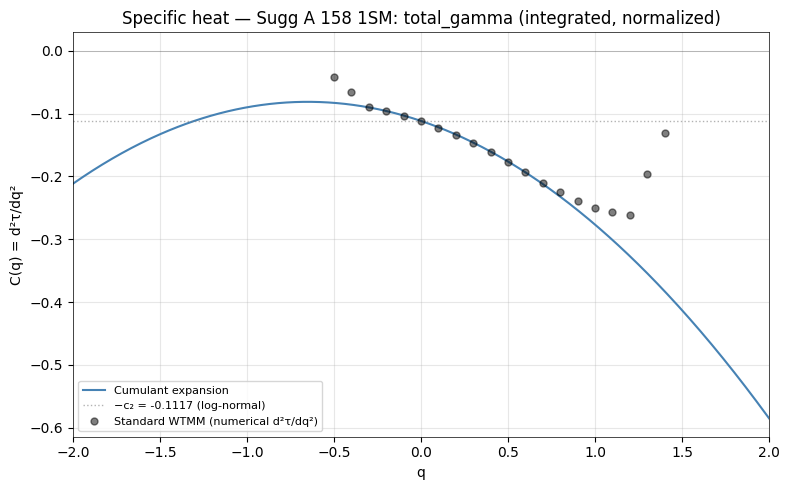

c₂ = 0.1117  →  −c₂ = -0.1117
c₃ = -0.0933  (slope of C(q) at q=0; =0 for log-normal)


In [161]:
# Specific heat C(q) = d²τ/dq²
# From cumulant expansion: C(q) = -c₂ + c₃q - c₄q²/2 + ...
# Monofractal: C(q) = 0 | Log-normal: C(q) = -c₂ (constant) | Phase transition: discontinuity

q_recon_ch = np.linspace(Q_RANGE_CUMULANT[0], Q_RANGE_CUMULANT[1], 500)

# Analytical from cumulant coefficients
C_heat_cum = -c_coeffs[2] + c_coeffs[3] * q_recon_ch - c_coeffs[4] * q_recon_ch**2 / 2

# Numerical from standard WTMM τ(q)
q_wtmm = spectra['q_list']
tau_wtmm = spectra['tau_q']
finite = np.isfinite(tau_wtmm)
if finite.sum() >= 3:
    C_heat_wtmm = np.gradient(np.gradient(tau_wtmm[finite], q_wtmm[finite]), q_wtmm[finite])
else:
    C_heat_wtmm = None

fig, ax = plt.subplots(figsize=(8, 5))
for spine in ax.spines.values(): spine.set_linewidth(0.5)

ax.plot(q_recon_ch, C_heat_cum, '-', color='steelblue', lw=1.5, label='Cumulant expansion')
ax.axhline(-c_coeffs[2], color='gray', ls=':', lw=1, alpha=0.6, label=f'−c₂ = {-c_coeffs[2]:.4f} (log-normal)')
ax.axhline(0, color='k', ls='-', lw=0.5, alpha=0.3)

if C_heat_wtmm is not None:
    ax.plot(q_wtmm[finite], C_heat_wtmm, 'ko', markersize=5, alpha=0.5, label='Standard WTMM (numerical d²τ/dq²)')

if has_theory:
    tau_th_fine = np.interp(q_recon_ch, theory_q, theory_tau)
    C_heat_theory = np.gradient(np.gradient(tau_th_fine, q_recon_ch), q_recon_ch)
    ax.plot(q_recon_ch, C_heat_theory, 'k-', lw=1, label='Theory')

ax.set_xlabel('q')
ax.set_ylabel('C(q) = d²τ/dq²')
ax.set_title(f'Specific heat — {analysis_label}')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xlim(Q_RANGE_CUMULANT[0], Q_RANGE_CUMULANT[1])
plt.tight_layout()
plt.show()

print(f'c₂ = {c_coeffs[2]:.4f}  →  −c₂ = {-c_coeffs[2]:.4f}')
print(f'c₃ = {c_coeffs[3]:.4f}  (slope of C(q) at q=0; =0 for log-normal)')


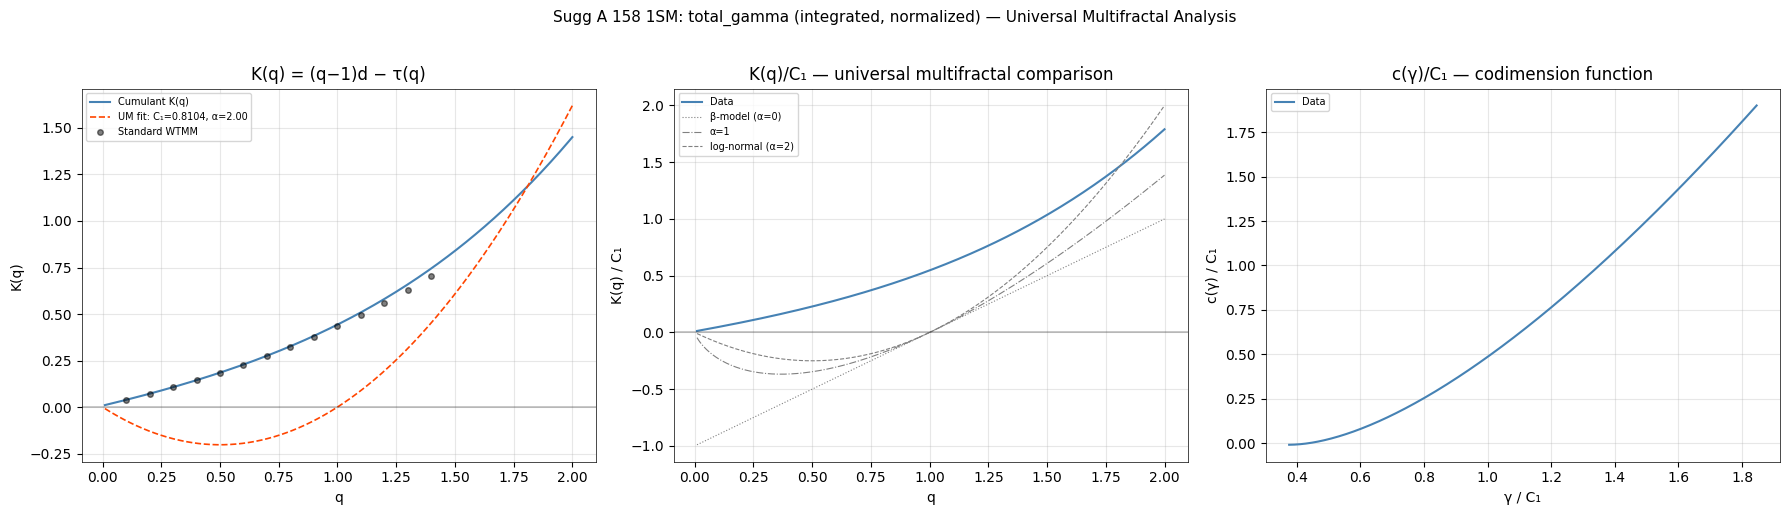

=== Universal Multifractal Parameters ===
  C₁ = 0.8104 ± 0.0631  (intermittency, cf. c₂ = 0.1666)
  α  = 2.000 ± 0.240  (Lévy index, 0=β-model, 2=log-normal)
  → Near log-normal (α ≈ 2)


In [135]:
# Universal Multifractal parameters (C₁, α) from WTMM
# K(q) = (q-1)·d - τ(q),  fit K(q) = C₁/(α-1)·(q^α - q) for α∈(0,2]
# c(γ) = Legendre transform of K(q) = codimension function = d - D(h)

from scipy.optimize import curve_fit

d = 1  # embedding dimension

# --- Compute K(q) from cumulant τ(q) ---
q_K = np.linspace(0.01, Q_RANGE_CUMULANT[1], 300)  # q > 0 for K(q)
tau_cum_K = -c_coeffs[0] + c_coeffs[1]*q_K - c_coeffs[2]*q_K**2/2 + c_coeffs[3]*q_K**3/6 - c_coeffs[4]*q_K**4/24
K_q = (q_K - 1) * d - tau_cum_K

# Also from standard WTMM
q_wtmm = np.array(spectra['q_list'], dtype=float)
tau_wtmm = np.array(spectra['tau_q'], dtype=float)
fmask = np.isfinite(tau_wtmm) & (q_wtmm > 0)
K_wtmm = (q_wtmm[fmask] - 1) * d - tau_wtmm[fmask]

# Theory K(q)
if has_theory:
    q_th_pos = theory_q[theory_q > 0]
    tau_th_pos = np.interp(q_th_pos, theory_q, theory_tau)
    K_theory = (q_th_pos - 1) * d - tau_th_pos

# --- Fit universal multifractal model ---
def K_universal(q, C1, alpha):
    """K(q) = C1/(alpha-1) * (q^alpha - q) for alpha != 1"""
    if abs(alpha - 1.0) < 1e-6:
        return C1 * q * np.log(q)
    return C1 / (alpha - 1) * (q**alpha - q)

# Fit on cumulant K(q) for q > 0.1
fit_mask = q_K > -1.1
try:
    popt, pcov = curve_fit(K_universal, q_K[fit_mask], K_q[fit_mask],
                           p0=[0.1, 1.5], bounds=([1e-6, 0.01], [5.0, 2.0]))
    C1_fit, alpha_fit = popt
    C1_err, alpha_err = np.sqrt(np.diag(pcov))
    K_fit = K_universal(q_K, C1_fit, alpha_fit)
    fit_ok = True
except Exception as e:
    print(f'Fit failed: {e}')
    fit_ok = False

# --- Legendre transform of K(q) → c(γ) ---
# γ = dK/dq,  c(γ) = q·γ - K(q)
dKdq = np.gradient(K_q, q_K)
gamma = dKdq
c_gamma = q_K * gamma - K_q

# Theory c(γ)
if has_theory:
    dK_th = np.gradient(K_theory, q_th_pos)
    gamma_th = dK_th
    c_gamma_th = q_th_pos * gamma_th - K_theory

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax_ in axes:
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

# Panel 1: K(q) vs q
ax = axes[0]
ax.plot(q_K, K_q, '-', color='steelblue', lw=1.5, label='Cumulant K(q)')
if fit_ok:
    ax.plot(q_K, K_fit, '--', color='orangered', lw=1.2,
            label=f'UM fit: C₁={C1_fit:.4f}, α={alpha_fit:.2f}')
ax.plot(q_wtmm[fmask], K_wtmm, 'ko', markersize=4, alpha=0.5, label='Standard WTMM')
if has_theory:
    ax.plot(q_th_pos, K_theory, 'k-', lw=1, label='Theory')
ax.axhline(0, color='k', lw=0.3)
ax.set_xlabel('q'); ax.set_ylabel('K(q)')
ax.set_title('K(q) = (q−1)d − τ(q)')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# Panel 2: K(q)/C₁ vs q (normalized, like Lovejoy Fig 13)
ax = axes[1]
if fit_ok and C1_fit > 1e-8:
    ax.plot(q_K, K_q / C1_fit, '-', color='steelblue', lw=1.5, label='Data')
    # Reference curves for α = 0, 1, 2
    for a_ref, ls, lbl in [(0.0, ':', 'β-model (α=0)'),
                            (1.0, '-.', 'α=1'),
                            (2.0, '--', 'log-normal (α=2)')]:
        K_ref = K_universal(q_K, C1_fit, a_ref) / C1_fit
        ax.plot(q_K, K_ref, ls, color='gray', lw=0.8, label=lbl)
    ax.set_ylabel('K(q) / C₁')
else:
    ax.plot(q_K, K_q, '-', color='steelblue', lw=1.5)
    ax.set_ylabel('K(q)')
ax.axhline(0, color='k', lw=0.3)
ax.set_xlabel('q')
ax.set_title('K(q)/C₁ — universal multifractal comparison')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# Panel 3: c(γ)/C₁ vs γ/C₁ (codimension, like Lovejoy Fig 14)
ax = axes[2]
if fit_ok and C1_fit > 1e-8:
    ax.plot(gamma / C1_fit, c_gamma / C1_fit, '-', color='steelblue', lw=1.5, label='Data')
    if has_theory:
        ax.plot(gamma_th / C1_fit, c_gamma_th / C1_fit, 'k-', lw=1, label='Theory')
    ax.set_xlabel('γ / C₁'); ax.set_ylabel('c(γ) / C₁')
else:
    ax.plot(gamma, c_gamma, '-', color='steelblue', lw=1.5, label='Data')
    if has_theory:
        ax.plot(gamma_th, c_gamma_th, 'k-', lw=1, label='Theory')
    ax.set_xlabel('γ'); ax.set_ylabel('c(γ)')
ax.set_title('c(γ)/C₁ — codimension function')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.suptitle(f'{analysis_label} — Universal Multifractal Analysis', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

# --- Summary ---
if fit_ok:
    print(f'=== Universal Multifractal Parameters ===')
    print(f'  C₁ = {C1_fit:.4f} ± {C1_err:.4f}  (intermittency, cf. c₂ = {c_coeffs[2]:.4f})')
    print(f'  α  = {alpha_fit:.3f} ± {alpha_err:.3f}  (Lévy index, 0=β-model, 2=log-normal)')
    if alpha_fit > 1.8:
        print(f'  → Near log-normal (α ≈ 2)')
    elif alpha_fit < 0.2:
        print(f'  → Near β-model (α ≈ 0)')
    else:
        print(f'  → Lévy multifractal with α = {alpha_fit:.2f}')
